In [97]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings

In [98]:
# file:///D:/Python_Code/Project_DS108/Paper/1-s2.0-S2772415825000100-main.pdf

In [99]:
warnings.filterwarnings ('ignore')
pd.set_option ('display.width', None)
pd.set_option ('display.max_rows', 100)
pd.set_option ('display.max_columns', 50)

# Description
- Market_Value (target): Giá trị cầu thủ chuyển nhượng 
- Player : Tên cầu thủ
- CLB : Câu lạc bộ đang thi đấu
- League : Giải đấu đang thi đấu
- Age : Độ tuổi 
- National : Quốc tịch
- Height : Chiều cao 
- Main_position : Vị trí thi đấu chính trên sân 
- Foot : Chân thuận 
- Months_left : Số tháng còn lại trong hợp đồng
- Start_app : Số lần đá chính
- Sub_app : Số lần vào sân từ băng ghế dự bị 
- Mins : Tổng số phút thi đấu 
- Goals : Số lượng bàn thắng 
- Assists : Tổng số đường kiến tạo
- Yel : Tổng số thẻ vàng nhận
- Red : Tổng số thẻ đỏ nhận 
- SpG : Tổng số cú sút trung bình 
- PS% : Tỉ lệ thành công của các đường truyền 
- AerialsWon : 
- MotM : Số lần được chọn là cầu thủ xuất sắc nhất trận đấu 
- Rating : Điểm trung bình được các nhà báo thể thao đánh giá sau trận

 

In [100]:
data = pd.read_csv('D:\Python_Code\Project_DS108\ds108\Data_clean\Final_Data_ver2.csv')
#data = pd.read_csv('/mnt/0498342198341420/Python_Code/Project_DS108/ds108/Data_clean/Final_Data_ver2.csv')
data = data.drop(columns = 'Unnamed: 0')
data = data.reindex (columns = [
    'Player', 'CLB', 'League', 'Age', 'National', 'Height',
    'Main_position', 'Foot', 'Market_Value', 'Months_left', 
    'Start_app', 'Sub_app', 'Mins', 'Goals', 'Assists', 'Yel',
    'Red', 'SpG', 'PS%', 'AerialsWon', 'MotM','Rating', 'TotAD',
    'WonAD', 'LostAD', 'CrAss', 'CorAss', 'ThrbAss', 'FreAss', 
    'ThrInAss', 'OthAss', 'TotAss', 'BlkSh', 'BlkCr', 'BlkPs',
    'YelC',	'RedC',	'TotClr', 'UnDrib', 'SucDrib', 'TotDrib', 
    'Fouled', 'Fouls', 'TotGs', 'SYBGs', 'PAGs', 'OOBGs', 'TotInt',
    'TotKPs', 'LKPs', 'SKPs', 'COF', 'TotPs', 'AccLB', 'InAccLB',
    'AccSP', 'InAccSP', 'UnTch', 'Dispo', 'TotSav', 'SYBSav', 'PASav',
    'OOBSav', 'TotSh', 'OOBSh',	'SYBSh', 'PASh', 'TotTkl', 'DribPast', 'TotAttTkl'
])
data

,Player,CLB,League,Age,National,Height,Main_position,Foot,Market_Value,Months_left,Start_app,Sub_app,Mins,Goals,Assists,Yel,Red,SpG,PS%,AerialsWon,MotM,Rating,TotAD,WonAD,LostAD,...,PAGs,OOBGs,TotInt,TotKPs,LKPs,SKPs,COF,TotPs,AccLB,InAccLB,AccSP,InAccSP,UnTch,Dispo,TotSav,SYBSav,PASav,OOBSav,TotSh,OOBSh,SYBSh,PASh,TotTkl,DribPast,TotAttTkl
0,Adam Hlozek,TSG 1899 Hoffenheim,Bundesliga,22.0,Czech Republic,188.0,Second Striker,right,18000000.0,49.0,19.0,5.0,1619.0,7.0,2.0,2.0,0.0,2.2,70.4,1.5,3.0,6.84,3.0,1.5,1.5,...,0.2,0.0,0.2,0.8,0.1,0.7,0.2,17.5,0.5,0.6,11.8,4.6,1.7,1.4,0.0,0.0,0.0,0.0,2.2,0.8,0.1,1.3,0.8,0.4,1.2
1,Adrian Beck,1.FC Heidenheim 1846,Bundesliga,27.0,Germany,186.0,Attacking Midfield,right,2000000.0,37.0,15.0,14.0,1383.0,2.0,1.0,1.0,0.0,1.1,81.9,0.9,0.0,6.55,1.4,0.9,0.6,...,0.1,0.0,0.2,0.6,0.1,0.5,0.1,20.4,1.0,0.5,15.7,3.2,1.2,0.7,0.0,0.0,0.0,0.0,1.1,0.4,0.1,0.5,1.2,0.8,1.9
2,Alassane Plea,Borussia Mönchengladbach,Bundesliga,32.0,France,181.0,Centre-Forward,right,6000000.0,13.0,23.0,5.0,1812.0,11.0,4.0,3.0,0.0,1.4,75.6,0.5,2.0,6.76,1.7,0.5,1.1,...,0.3,0.0,0.1,0.9,0.1,0.7,0.3,24.7,1.1,0.5,17.5,5.5,1.4,0.8,0.0,0.0,0.0,0.0,1.4,0.3,0.2,1.0,0.3,0.3,0.5
3,Aleix Garcia,Bayer 04 Leverkusen,Bundesliga,27.0,Spain,173.0,Central Midfield,right,20000000.0,49.0,15.0,10.0,1295.0,3.0,3.0,2.0,0.0,0.6,91.0,0.1,1.0,6.68,0.4,0.1,0.3,...,0.0,0.1,0.3,1.2,0.5,0.7,0.0,47.5,2.8,1.0,40.4,3.2,0.4,0.1,0.0,0.0,0.0,0.0,0.6,0.4,0.0,0.2,0.4,0.3,0.7
4,Aleksandar Pavlovic,Bayern Munich,Bundesliga,20.0,Germany,188.0,Defensive Midfield,both,50000000.0,49.0,16.0,2.0,1250.0,1.0,0.0,2.0,0.0,0.4,94.1,0.5,0.0,6.85,0.9,0.5,0.4,...,0.0,0.1,0.2,0.3,0.0,0.3,0.0,74.9,2.3,1.3,68.2,3.2,0.7,0.1,0.0,0.0,0.0,0.0,0.4,0.3,0.0,0.1,1.8,0.5,2.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2244,Nicolas Gonzalez,Juventus FC,SerieA,27.0,Argentina,180.0,Right Winger,left,28000000.0,1.0,19.0,3.0,1471.0,2.0,2.0,1.0,0.0,1.7,76.6,2.4,0.0,6.81,4.3,2.4,1.9,...,0.0,0.0,0.3,0.8,0.1,0.7,0.2,22.5,0.6,0.5,16.7,4.8,1.5,0.6,0.0,0.0,0.0,0.0,1.7,0.5,0.2,1.0,1.0,0.6,1.6
2245,Tasos Douvikas,Como 1907,SerieA,25.0,Greece,186.0,Centre-Forward,right,8000000.0,49.0,3.0,6.0,369.0,2.0,0.0,1.0,0.0,1.0,77.3,0.7,0.0,6.39,2.2,0.7,1.6,...,0.0,0.0,0.1,0.3,0.0,0.3,0.1,8.3,0.1,0.2,6.3,1.7,1.6,0.7,0.0,0.0,0.0,0.0,1.0,0.1,0.2,0.7,0.3,0.2,0.6
2246,Thorir Helgason,US Lecce,SerieA,24.0,Iceland,187.0,Central Midfield,right,2500000.0,13.0,11.0,6.0,946.0,0.0,4.0,0.0,0.0,0.8,71.8,0.9,0.0,6.49,1.8,0.9,0.9,...,0.0,0.0,0.3,1.2,0.6,0.6,0.1,15.2,1.0,0.5,9.9,3.8,1.4,0.5,0.0,0.0,0.0,0.0,0.8,0.4,0.1,0.4,0.6,0.2,0.8
2247,Valentin Castellanos,SS Lazio,SerieA,26.0,Argentina,178.0,Centre-Forward,right,25000000.0,37.0,24.0,1.0,2036.0,10.0,3.0,7.0,1.0,3.7,69.9,2.4,4.0,7.08,4.6,2.4,2.3,...,0.0,0.0,0.2,0.9,0.0,0.9,0.6,17.2,0.2,0.3,11.8,4.9,1.8,1.0,0.0,0.0,0.0,0.0,3.7,1.1,0.3,2.3,0.4,0.3,0.8


In [101]:
for col in data.columns:
    print(col)
    print(data[col].unique())

Player
['Adam Hlozek' 'Adrian Beck' 'Alassane Plea' ... 'Thorir Helgason'
 'Valentin Castellanos' 'Vanja Vlahovic']
CLB
['TSG 1899 Hoffenheim' '1.FC Heidenheim 1846' 'Borussia Mönchengladbach'
 'Bayer 04 Leverkusen' 'Bayern Munich' 'Holstein Kiel' 'Borussia Dortmund'
 'VfB Stuttgart' 'FC Augsburg' 'RB Leipzig' 'SV Werder Bremen'
 '1.FSV Mainz 05' 'VfL Wolfsburg' '1.FC Union Berlin'
 'Eintracht Frankfurt' 'VfL Bochum' 'FC St. Pauli' 'SC Freiburg'
 'West Ham United' 'Southampton FC' 'Everton FC' 'Manchester City'
 'AFC Bournemouth' 'Brighton & Hove Albion' 'Crystal Palace' 'Fulham FC'
 'Manchester United' 'Ipswich Town' 'Newcastle United' 'Liverpool FC'
 'Aston Villa' 'Wolverhampton Wanderers' 'Nottingham Forest'
 'Tottenham Hotspur' 'Brentford FC' 'Arsenal FC' 'Chelsea FC'
 'Leicester City' 'Real Betis Balompié' 'Deportivo Alavés'
 'Rayo Vallecano' 'RCD Mallorca' 'CA Osasuna' 'Girona FC'
 'Real Valladolid CF' 'Athletic Bilbao' 'UD Las Palmas' 'Sevilla FC'
 'Real Sociedad' 'Getafe CF' 'F

In [102]:
for col in data.columns:
    print(col, data[col].isna().sum())

Player 0
CLB 0
League 0
Age 0
National 0
Height 0
Main_position 0
Foot 0
Market_Value 0
Months_left 0
Start_app 0
Sub_app 0
Mins 0
Goals 0
Assists 0
Yel 0
Red 0
SpG 0
PS% 0
AerialsWon 0
MotM 0
Rating 0
TotAD 0
WonAD 0
LostAD 0
CrAss 0
CorAss 0
ThrbAss 0
FreAss 0
ThrInAss 0
OthAss 0
TotAss 0
BlkSh 0
BlkCr 0
BlkPs 0
YelC 0
RedC 0
TotClr 0
UnDrib 0
SucDrib 0
TotDrib 0
Fouled 0
Fouls 0
TotGs 0
SYBGs 0
PAGs 0
OOBGs 0
TotInt 0
TotKPs 0
LKPs 0
SKPs 0
COF 0
TotPs 0
AccLB 0
InAccLB 0
AccSP 0
InAccSP 0
UnTch 0
Dispo 0
TotSav 0
SYBSav 0
PASav 0
OOBSav 0
TotSh 0
OOBSh 0
SYBSh 0
PASh 0
TotTkl 0
DribPast 0
TotAttTkl 0


- Dữ liệu không có Missing Value 

# EDA - Exploratory Data Analysis

## Categorical and Numerical Col

In [103]:
categorical_col = []
numerical_col = []
for col in data.columns:
    if data[col].dtype == 'object':
        categorical_col.append(col)
    else:
        numerical_col.append(col)



categorical_col
    


['Player', 'CLB', 'League', 'National', 'Main_position', 'Foot']

## Distribution of Market Value

Text(0.5, 1.0, 'Contribution of Market Value')

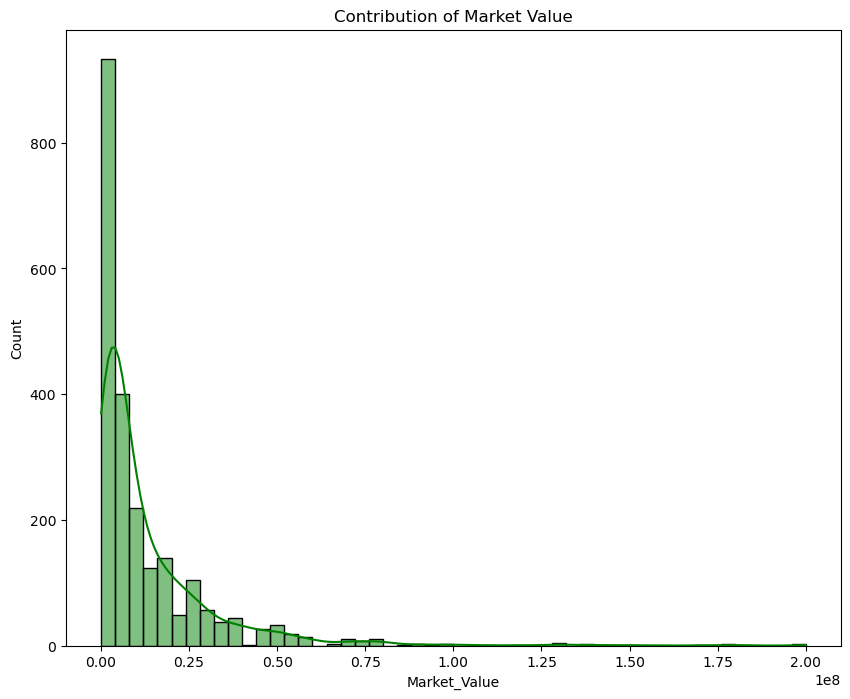

In [104]:
# Đối với 
plt.figure(figsize= (10, 8))
sns.histplot(data = data, x = 'Market_Value',  bins = 50, kde = True, color = 'green')
plt.title("Contribution of Market Value")


** Phân phối của Market Value bị skewness 
=> Đưa về phân phối chuẩn bằng Log()

In [105]:
data['Market_Value'] = data['Market_Value'] / 1000000

In [106]:
data['Market_Value_log'] = np.log1p(data['Market_Value'])

Text(0.5, 1.0, 'Contribution of Market Value')

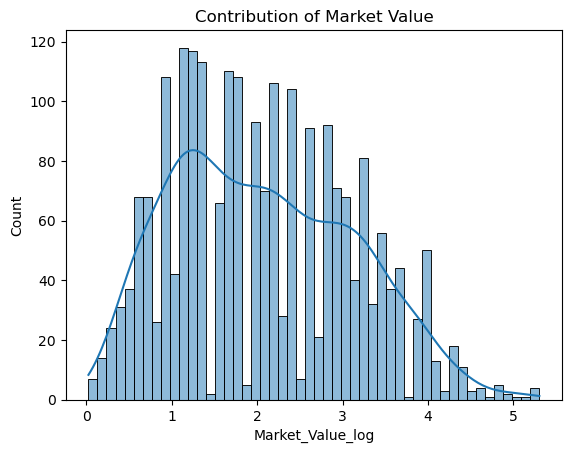

In [107]:
# Phân phối của Market Value sau khi chuẩn hóa 
sns.histplot(data = data, x = 'Market_Value_log',  bins = 50, kde = True, palette= 'green')
plt.title("Contribution of Market Value")

- So sánh giá trị trung bình của cầu thủ dựa trên Quốc Tịch và Châu Lục
- So sánh giá trị cầu thủ dựa trên tuổi 
- So sánh giá trị cầu thủ dựa trên bàn thắng, kiến tạo 

- Phân phố đều tập trung quanh trong khoảng 23-26 tuổi 

## League and Market Value

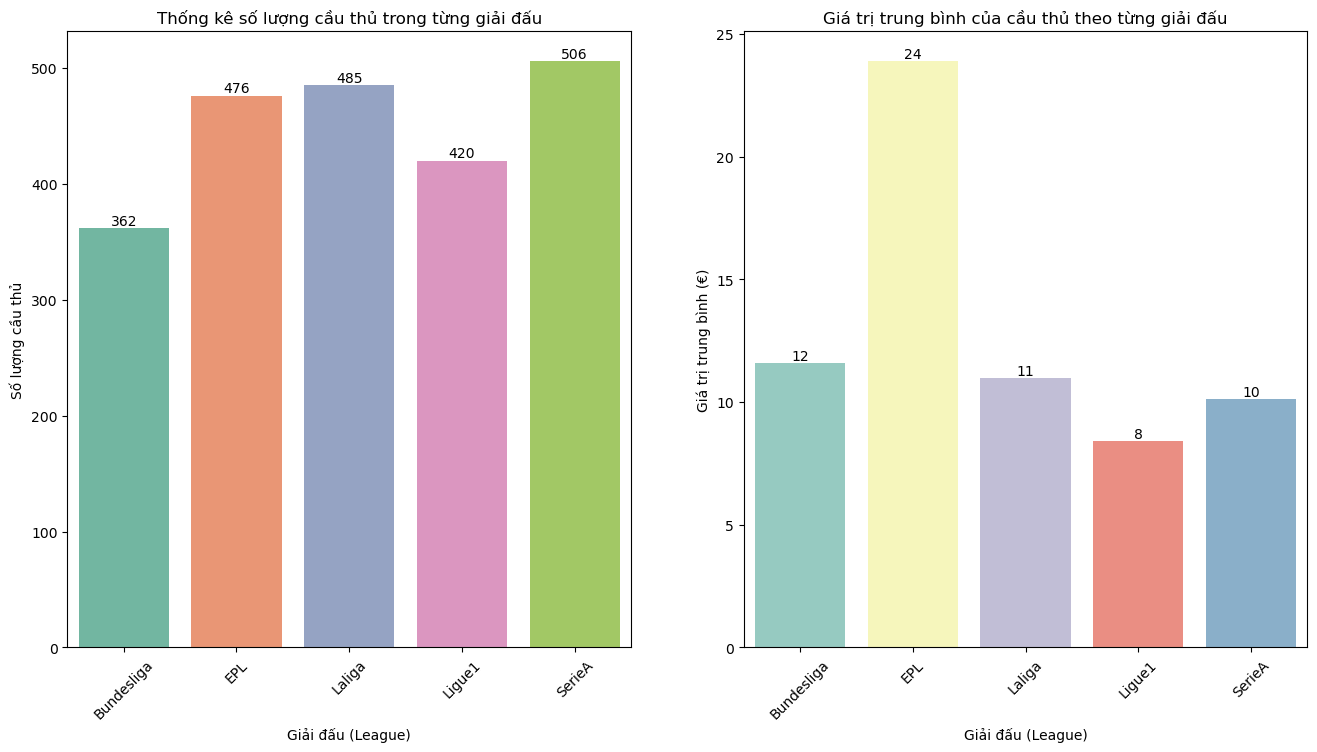

<Figure size 1000x600 with 0 Axes>

In [108]:
fig, ax = plt.subplots(1,2, figsize = (16, 8))
player_count = data.groupby('League')['Player'].count().reset_index()

player_count.columns = ['League', 'Player_Count']

plt.figure(figsize= (10, 6))
sns.barplot(ax = ax[0], data = player_count, x = 'League', y = 'Player_Count', palette = 'Set2')
for p in ax[0].patches:
    height = p.get_height()
    ax[0].annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black')


ax[0].set_title("Thống kê số lượng cầu thủ trong từng giải đấu")
ax[0].set_xlabel('Giải đấu (League)')
ax[0].set_ylabel('Số lượng cầu thủ')
ax[0].tick_params(axis='x', rotation=45)

plt.tight_layout()


avg_value = data.groupby('League')['Market_Value'].mean().reset_index()
sns.barplot(ax=ax[1], data=avg_value, x='League', y='Market_Value', palette='Set3')
for p in ax[1].patches:
    height = p.get_height()
    ax[1].annotate(f'{height:,.0f}',  # có dấu phẩy phân cách hàng nghìn
                   (p.get_x() + p.get_width() / 2., height),
                   ha='center', va='bottom', fontsize=10, color='black')

ax[1].set_title("Giá trị trung bình của cầu thủ theo từng giải đấu")
ax[1].set_xlabel('Giải đấu (League)')
ax[1].set_ylabel('Giá trị trung bình (€)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- Mặc dù số lượng các cầu thủ tại mỗi giải đấu là khá đồng đều
- Tuy nhiên EPL là giải đấu có giá trị cầu thủ chuyển nhượng cao vượt trội


## Foot and Market Value 

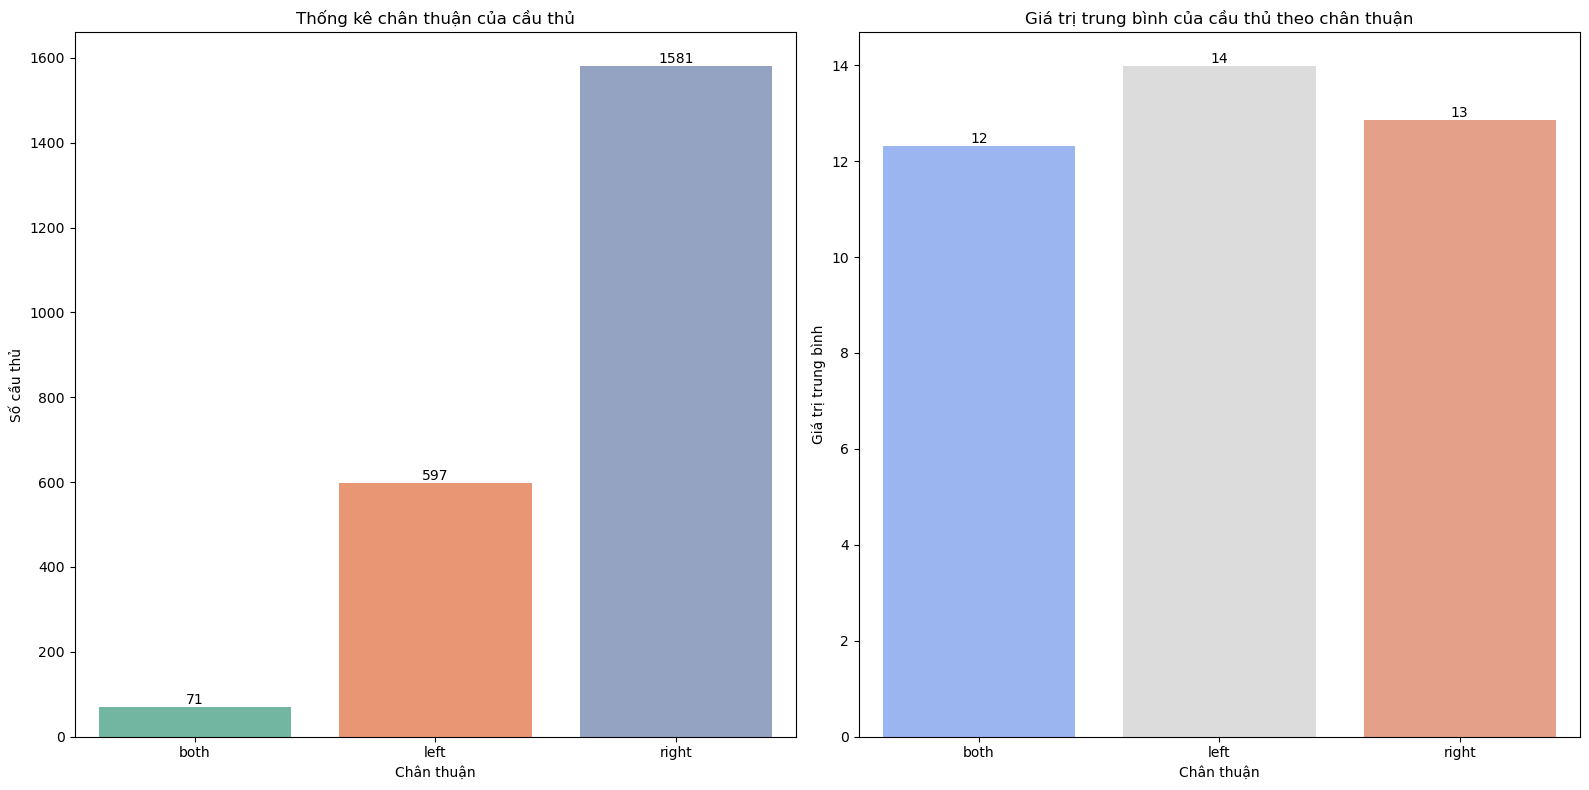

In [109]:
fig, ax = plt.subplots(1, 2, figsize = (16, 8))

# Thống kê chân thuận của cầu thủ 
foot_count = data.groupby('Foot')['Player'].count().reset_index()
sns.barplot(data = foot_count, x = 'Foot', y = 'Player', palette= 'Set2', ax = ax[0])
ax[0].set_title('Thống kê chân thuận của cầu thủ')
ax[0].set_title('Thống kê chân thuận của cầu thủ')
ax[0].set_xlabel('Chân thuận')
ax[0].set_ylabel('Số cầu thủ')

# Ghi giá trị lên cột
for p in ax[0].patches:
    height = p.get_height()
    ax[0].annotate(f'{int(height)}', 
                   (p.get_x() + p.get_width() / 2., height), 
                   ha='center', va='bottom', fontsize=10)
    

avg_value = data.groupby('Foot')['Market_Value'].mean().reset_index()
sns.barplot(data = avg_value, x = 'Foot', y = 'Market_Value', ax = ax[1], palette= 'coolwarm')
ax[1].set_title('Giá trị trung bình của cầu thủ theo chân thuận')
ax[1].set_xlabel('Chân thuận')
ax[1].set_ylabel('Giá trị trung bình')

# Ghi giá trị lên từng cột
for p in ax[1].patches:
    height = p.get_height()
    ax[1].annotate(f'{height:,.0f}',  # format với dấu phẩy
                   (p.get_x() + p.get_width() / 2., height), 
                   ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()





- Số lượng cầu thủ thuận cả 2 chân có rất ít, đa phân cầu thủ đều thuận chân phải 
- Giá trị của cầu thủ không ảnh hưởng quá nhiều đến chân thuận 

## Age and Market Value 

<Axes: xlabel='Age', ylabel='Count'>

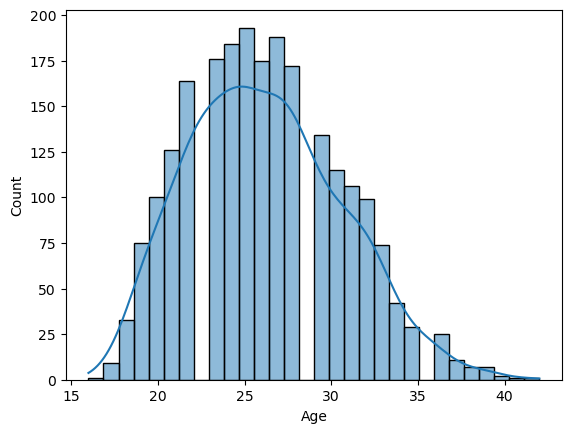

In [110]:
sns.histplot(data = data, x = 'Age', kde = True, bins = 30)

<Axes: xlabel='Age', ylabel='Market_Value_log'>

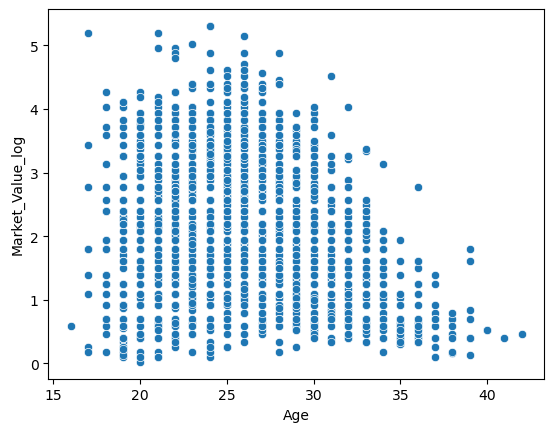

In [111]:
sns.scatterplot(data = data, x = 'Age', y = 'Market_Value_log')

Text(0.5, 1.0, 'Giá trị của cầu thủ dựa vào tuổi và giải đấu')

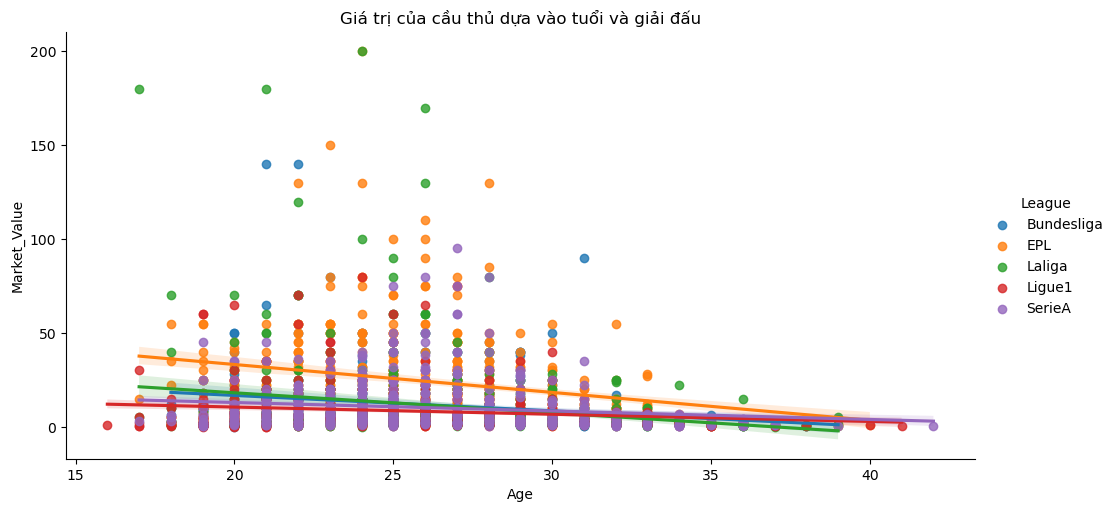

In [112]:
sns.lmplot (data=data, x='Age', y='Market_Value', hue='League',aspect=2)
plt.title('Giá trị của cầu thủ dựa vào tuổi và giải đấu')

Text(0.5, 1.0, 'Phân phối tuổi của các cầu thủ')

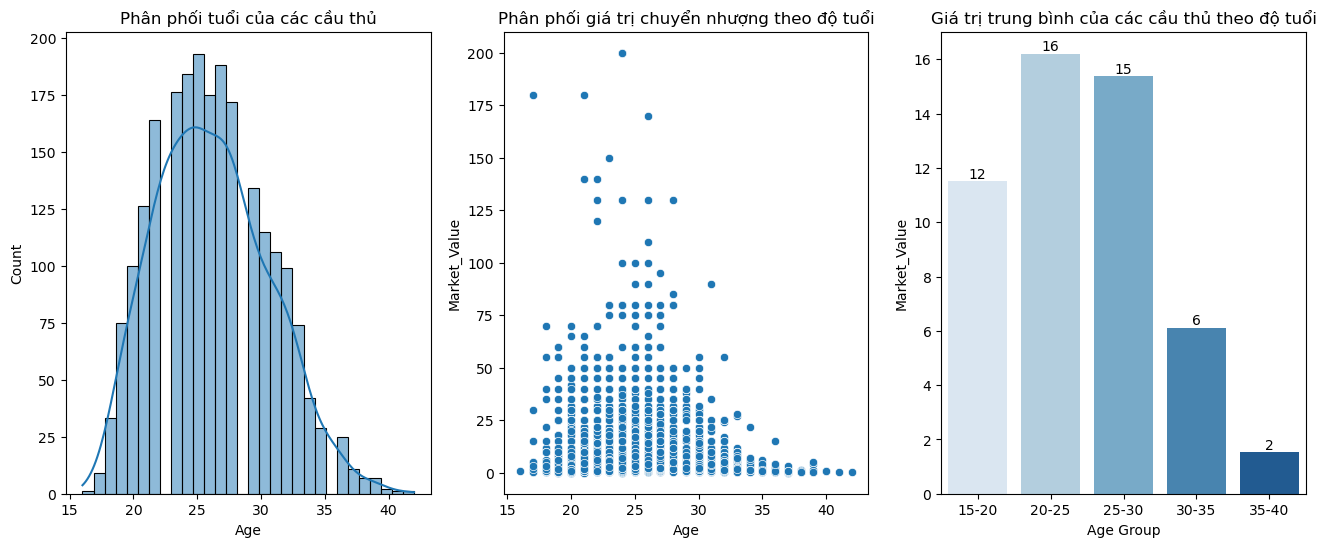

In [113]:
fig, ax = plt.subplots(1, 3, figsize = (16, 6))

bins = [15, 20, 25, 30, 35, 40]
labels = ['15-20', '20-25', '25-30', '30-35', '35-40']
df = data.copy()
df['Age_Group'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)

avg_value_by_age_group = df.groupby('Age_Group')['Market_Value'].mean().reset_index()
avg_value_by_age_group.columns = ['Age_Group', 'Avg_Market_Value']


sns.barplot(data=avg_value_by_age_group, x='Age_Group', y='Avg_Market_Value', palette='Blues', ax = ax[2])
for p in ax[2].patches:
    height = p.get_height()
    ax[2].annotate(f'{height:,.0f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)
ax[2].set_title('Giá trị trung bình của các cầu thủ theo độ tuổi')
ax[2].set_xlabel('Age Group')
ax[2].set_ylabel('Market_Value')


sns.scatterplot(data = data, x = 'Age', y = 'Market_Value', ax = ax[1])
ax[1].set_title('Phân phối giá trị chuyển nhượng theo độ tuổi')

sns.histplot(data = data, x = 'Age', kde = True, bins = 30, ax = ax[0])
ax[0].set_title("Phân phối tuổi của các cầu thủ")



- Phân phối tuổi gần chuẩn và tập trung xoanh quanh điểm trung bình 25
- Nhóm cầu thủ có giá trị cao nhất là từ 20-25 và 25 - 30
- Nhóm 30-35 và 35-40 có giá trị thấp 
- Có một số cầu thủ từ khoảng 20-30 có giá trị rất cao > 100 million Euro 

## Red and Yellow card

In [114]:
data['Card'] = data['Yel'] + data['Red'] * 2
# Một thẻ đỏ bằng 2 thẻ vàng 
data['Card'] = data['Card'].astype(int)

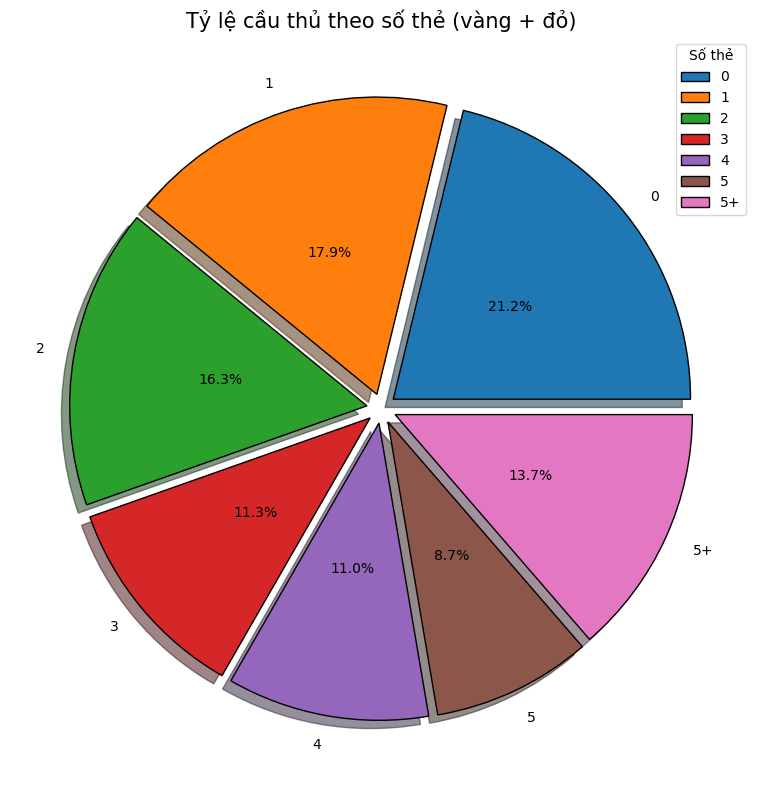

In [115]:

# Đếm số thẻ
card_counts_full = data['Card'].value_counts().sort_index()

# Lấy thẻ <= 5
card_counts = card_counts_full[card_counts_full.index <= 5].copy()

# Gộp nhóm thẻ > 5
card_counts['5+'] = card_counts_full[card_counts_full.index > 5].sum()

# Labels tương ứng với card_counts mới
labels = card_counts.index.astype(str)

explode = [0.05] * len(labels)
wp = {'linewidth': 1, 'edgecolor': 'black'}

plt.figure(figsize=(8, 8))
plt.pie(x=card_counts.values,
        labels=labels,
        autopct="%.1f%%",
        pctdistance=0.5,
        explode=explode,
        shadow=True,
        wedgeprops=wp)

plt.title("Tỷ lệ cầu thủ theo số thẻ (vàng + đỏ)", fontsize=15)
plt.legend(title="Số thẻ")
plt.tight_layout()
plt.show()


- Nhóm những cầu thủ có > 5+ thẻ (2 * đỏ + vàng) vào một nhóm

## Main position and League and Market Value

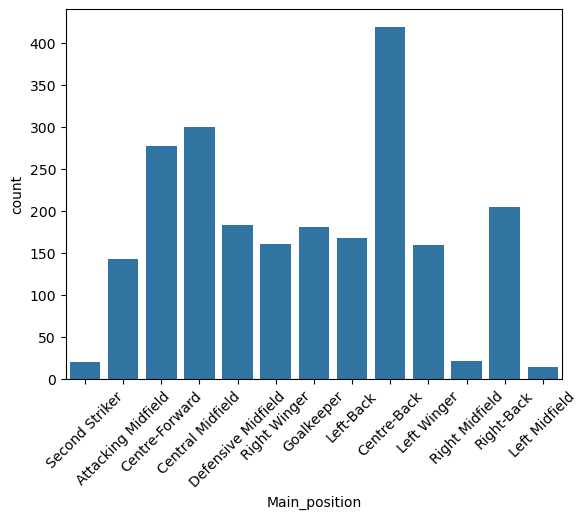

In [116]:
sns.countplot(data = data, x = 'Main_position')
plt.tick_params(axis='x', rotation=45)


In [117]:
# Nhóm thủ môn + hậu vệ (phòng ngự)
group_defense = ['Goalkeeper', 'Centre-Back', 'Left-Back', 'Right-Back']

# Nhóm tiền vệ 
group_midfield = ['Defensive Midfield', 'Central Midfield', 'Left Midfield', 'Right Midfield']

# Nhóm tiền đạo 
group_attack = ['Centre-Forward', 'Second Striker', 'Attacking Midfield', 'Left Winger', 'Right Winger']

def map_position(pos):
    if pos in group_defense:
        return 'Phòng ngự'
    elif pos in group_midfield:
        return 'Tiền vệ'
    elif pos in group_attack:
        return 'Tiền đạo'
    else:
        return 'Khác'
data['Position_Group'] = data['Main_position'].apply(map_position)

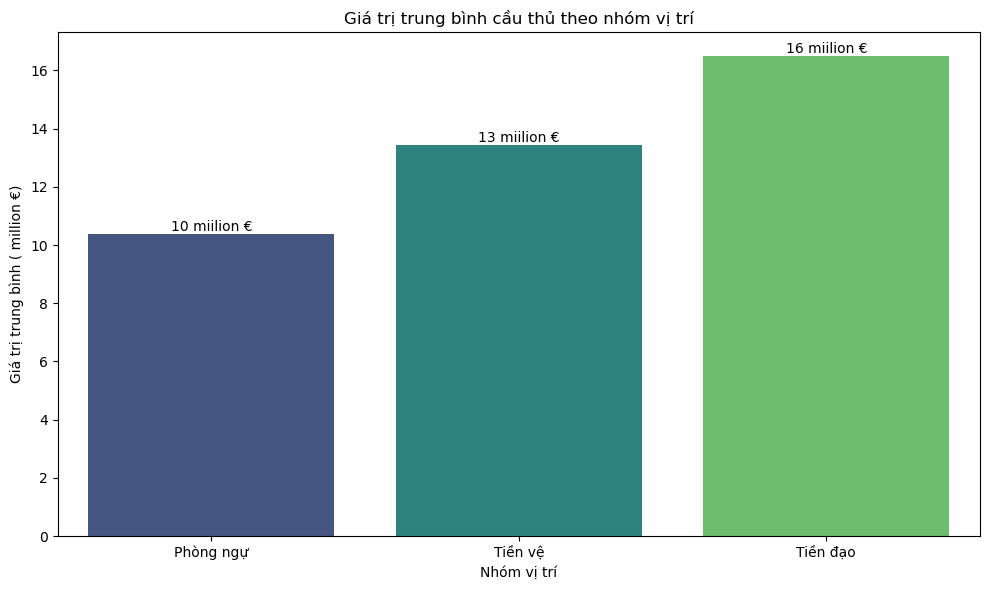

In [118]:
avg_value_by_group = data.groupby('Position_Group')['Market_Value'].mean().reset_index()
avg_value_by_group.columns = ['Position_Group', 'Avg_Market_Value']
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
ax = sns.barplot(data=avg_value_by_group, x='Position_Group', y='Avg_Market_Value', palette='viridis')

# Ghi giá trị lên cột
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,.0f} miilion €', (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', fontsize=10)

plt.title("Giá trị trung bình cầu thủ theo nhóm vị trí")
plt.xlabel("Nhóm vị trí")
plt.ylabel("Giá trị trung bình ( million €)")
plt.tight_layout()
plt.show()


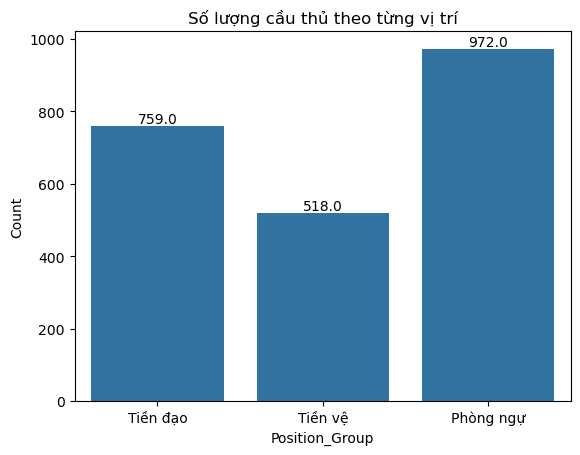

In [119]:
data['Position_Group'].value_counts()
ax = sns.countplot(data = data, x= 'Position_Group')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}',  # giá trị đếm
                xy=(p.get_x() + p.get_width() / 2, height),  # vị trí ghi
                ha='center', va='bottom', fontsize=10)
plt.title('Số lượng cầu thủ theo từng vị trí')
plt.ylabel('Count')
plt.show()

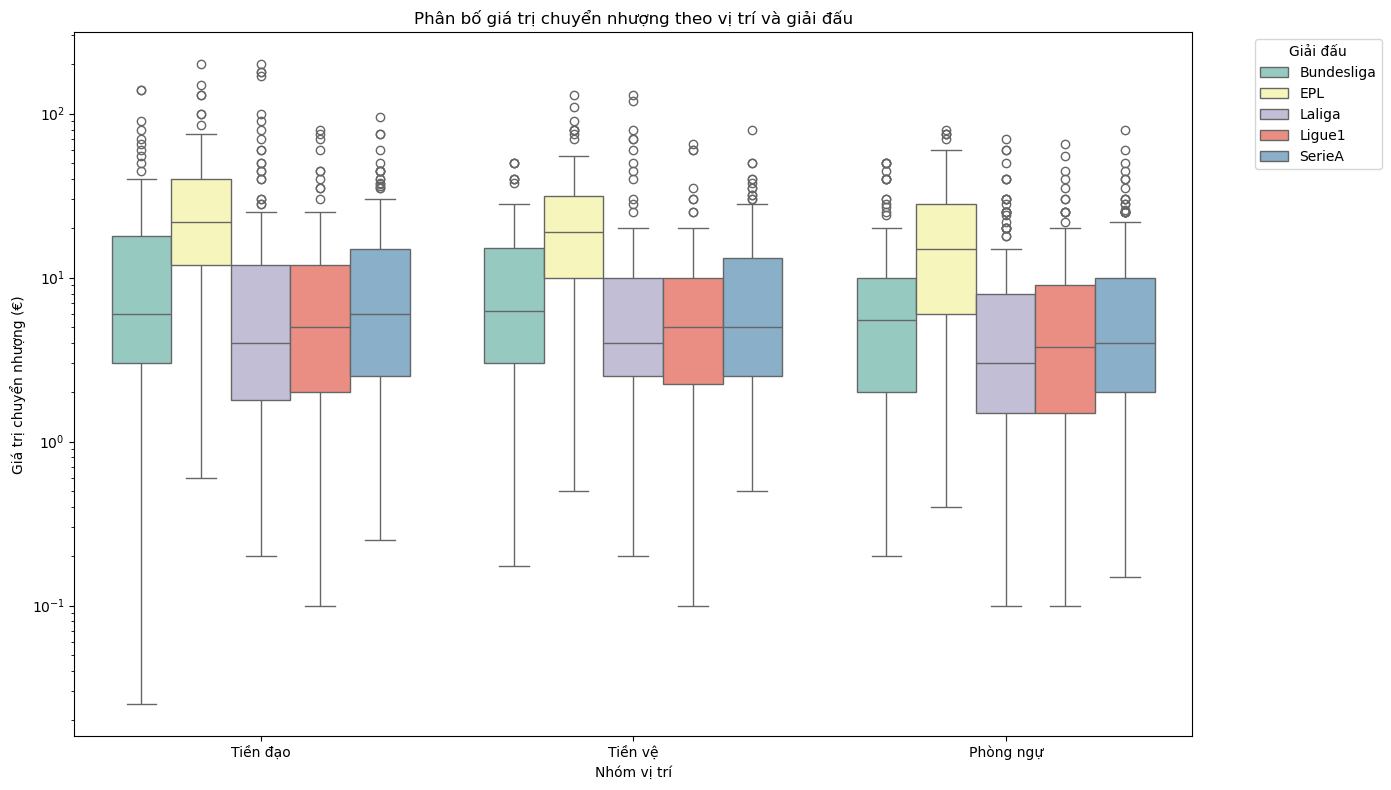

In [120]:
plt.figure(figsize=(14,8))
sns.boxplot(data=data, x='Position_Group', y='Market_Value', hue='League', palette='Set3')
plt.title('Phân bố giá trị chuyển nhượng theo vị trí và giải đấu')
plt.ylabel('Giá trị chuyển nhượng (€)')
plt.xlabel('Nhóm vị trí')
plt.yscale('log')  # Nếu giá trị phân bố rất rộng, dùng log scale giúp dễ nhìn
plt.legend(title='Giải đấu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


<Axes: xlabel='Position_Group', ylabel='Market_Value'>

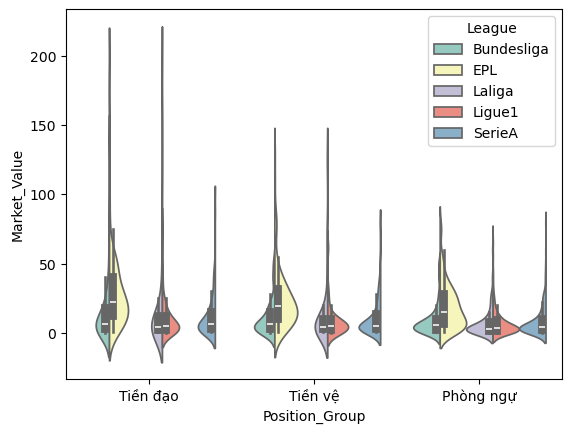

In [121]:
sns.violinplot(data=data, x='Position_Group', y='Market_Value', hue='League', palette='Set3', split=True)


- EPL vẫn là giải đấu có giá trị cầu thủ cao nhất tại mọi vị trí trên sân


## National and Market Value 

In [122]:
data['National'].unique()

array(['Czech Republic', 'Germany', 'France', 'Spain', 'Sweden',
       'Austria', 'Canada', 'Mali', 'Belgium', 'Morocco', 'Norway',
       'Denmark', 'Serbia', 'Croatia', 'Portugal', 'Eritrea',
       'Burkina Faso', 'Switzerland', 'Slovenia', 'Brazil', 'Georgia',
       'Turkey', 'England', 'Costa Rica', 'Netherlands', 'Israel',
       'Slovakia', 'Tunisia', 'Argentina', 'Bosnia-Herzegovina', 'Italy',
       'Algeria', 'Kosovo', 'Nigeria', 'Finland', 'USA', 'Japan',
       'South Korea', 'Ukraine', 'Poland', 'Estonia', 'Greece', 'Guinea',
       'Scotland', 'Ecuador', 'Hungary', 'Sierra Leone', 'Benin',
       'Uzbekistan', 'Ivory Coast', 'Cameroon', 'Ghana', 'Albania',
       'Wales', 'Jamaica', 'Australia', 'Ireland', 'New Zealand',
       'N. Ireland', 'Colombia', 'Uruguay', 'Mexico', 'Senegal',
       'Paraguay', 'Zimbabwe', 'Egypt', 'Zambia', 'Romania', 'Gambia',
       'DR Congo', 'Iceland', 'Russia', 'Macedonia', 'Venezuela',
       'Equatorial Guinea', 'Dominican Rep.', 'Peru

In [123]:
# Map quốc gia -> châu lục
country_to_continent = {
    "Europe": ["Albania", "Armenia", "Austria", "Belgium", "Bosnia-Herzegovina", "Croatia", "Cyprus", "Czech Republic", "Denmark", "England", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary", "Iceland", "Ireland", "Italy", "Kosovo", "Lithuania", "Macedonia", "Malta", "Montenegro", "Netherlands", "N. Ireland", "Norway", "Poland", "Portugal", "Romania", "Russia", "Scotland", "Serbia", "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine", "Wales"],
    "Africa": ["Algeria", "Angola", "Benin", "Burkina Faso", "Burundi", "Cameroon", "Central African Rep.", "Congo", "DR Congo", "Egypt", "Equatorial Guinea", "Eritrea", "Gabon", "Gambia", "Ghana", "Guinea", "Guinea-Bissau", "Ivory Coast", "Kenya", "Libya", "Mali", "Morocco", "Nigeria", "Senegal", "Sierra Leone", "Tunisia", "Zambia", "Zimbabwe"],
    "Asia": ["Georgia", "Iran", "Israel", "Japan", "Saudi Arabia", "South Korea", "Turkey", "U.A.E.", "Uzbekistan"],
    "Americas": ["Argentina", "Brazil", "Canada", "Chile", "Colombia", "Costa Rica", "Dominican Rep.", "Ecuador", "Haiti", "Jamaica", "Mexico", "Panama", "Paraguay", "Peru", "USA", "Uruguay", "Venezuela", "Guadeloupe"],
    "Oceania": ["Australia", "New Zealand"]

}
# Đảo ngược dictionary: từ quốc gia → châu lục
flat_country_to_continent = {
    country: continent 
    for continent, countries in country_to_continent.items() 
    for country in countries
}


In [124]:
data['Continent'] = data['National'].map(flat_country_to_continent)

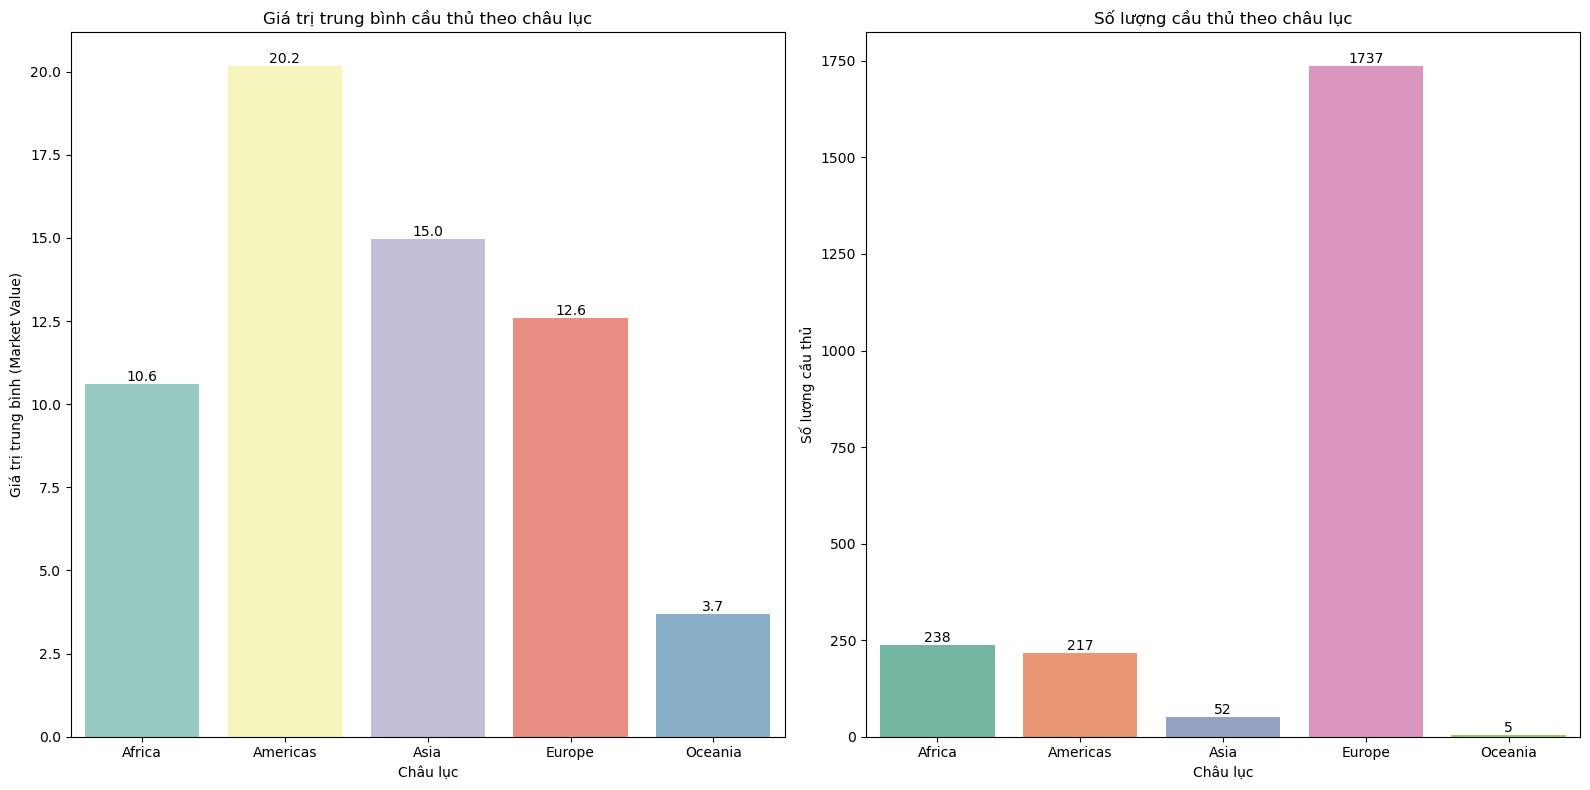

In [125]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Biểu đồ 1: Giá trị trung bình cầu thủ theo châu lục
avg_value_by_continent = data.groupby('Continent')['Market_Value'].mean().reset_index()
sns.barplot(ax=ax[0], data=avg_value_by_continent, x='Continent', y='Market_Value', palette='Set3')
for p in ax[0].patches:
    height = p.get_height()
    ax[0].annotate(f'{height:.1f}', 
                   (p.get_x() + p.get_width() / 2, height),
                   ha='center', va='bottom',
                   fontsize=10, color='black')
ax[0].set_title("Giá trị trung bình cầu thủ theo châu lục")
ax[0].set_xlabel("Châu lục")
ax[0].set_ylabel("Giá trị trung bình (Market Value)")

# Biểu đồ 2: Số lượng cầu thủ theo châu lục
player_count_by_continent = data.groupby('Continent')['Player'].count().reset_index()
player_count_by_continent.columns = ['Continent', 'Player_Count']
sns.barplot(ax=ax[1], data=player_count_by_continent, x='Continent', y='Player_Count', palette='Set2')
for p in ax[1].patches:
    height = p.get_height()
    ax[1].annotate(f'{int(height)}', 
                   (p.get_x() + p.get_width() / 2, height),
                   ha='center', va='bottom',
                   fontsize=10, color='black')
ax[1].set_title("Số lượng cầu thủ theo châu lục")
ax[1].set_xlabel("Châu lục")
ax[1].set_ylabel("Số lượng cầu thủ")

plt.tight_layout()
plt.show()


- Số lượng cầu thủ Châu Âu cao nhất -> Đơn giản vì dữ liệu lấy từ 5 giải VĐQG Châu Âu
- Châu Mỹ mới là châu lục có giá trị cầu thủ cao nhất, thấp nhất là châu ÚC
- Châu Phi, Á, Âu có giá trị cầu thủ trung bình gần ngang nhau (chênh lệch không đáng kể)
=> Có thể xem xét việc gộp Châu Úc, Châu Á và Châu Mỹ lại 1 thành Châu Úc Mỹ Á :v 


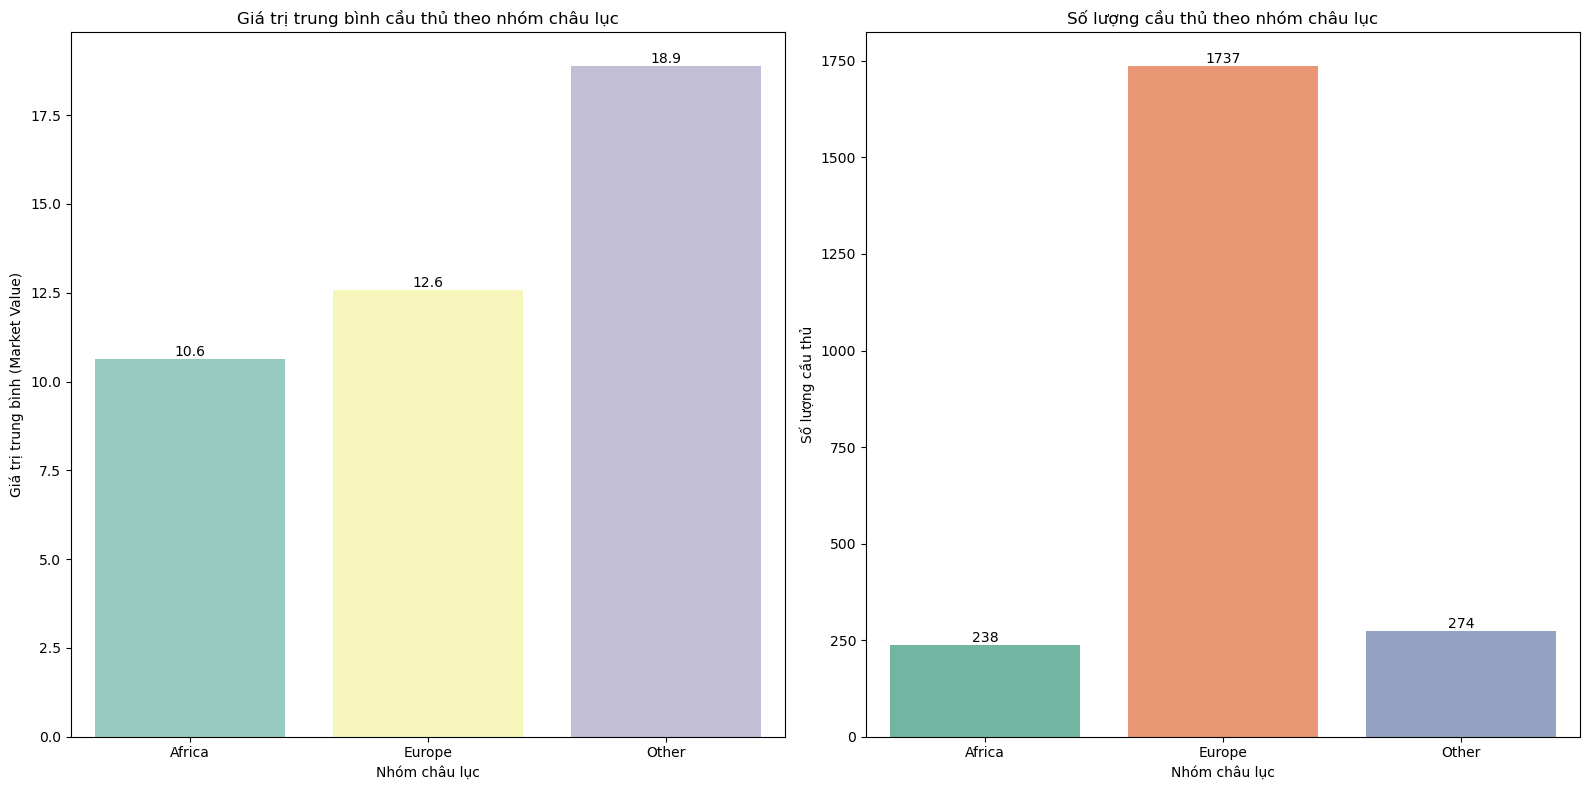

In [126]:
def merge_continents(continent):
    if continent in ['Oceania', 'Asia', 'Americas']:
        return 'Other'
    else:
        return continent

data['Continent_Grouped'] = data['Continent'].apply(merge_continents)

# Tính trung bình giá trị theo nhóm mới
avg_value_by_continent_grouped = data.groupby('Continent_Grouped')['Market_Value'].mean().reset_index()

# Tính số lượng cầu thủ theo nhóm mới
player_count_by_continent_grouped = data.groupby('Continent_Grouped')['Player'].count().reset_index()
player_count_by_continent_grouped.columns = ['Continent_Grouped', 'Player_Count']

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(ax=ax[0], data=avg_value_by_continent_grouped, x='Continent_Grouped', y='Market_Value', palette='Set3')
for p in ax[0].patches:
    height = p.get_height()
    ax[0].annotate(f'{height:.1f}', 
                   (p.get_x() + p.get_width() / 2, height),
                   ha='center', va='bottom',
                   fontsize=10, color='black')
ax[0].set_title("Giá trị trung bình cầu thủ theo nhóm châu lục")
ax[0].set_xlabel("Nhóm châu lục")
ax[0].set_ylabel("Giá trị trung bình (Market Value)")

sns.barplot(ax=ax[1], data=player_count_by_continent_grouped, x='Continent_Grouped', y='Player_Count', palette='Set2')
for p in ax[1].patches:
    height = p.get_height()
    ax[1].annotate(f'{int(height)}', 
                   (p.get_x() + p.get_width() / 2, height),
                   ha='center', va='bottom',
                   fontsize=10, color='black')
ax[1].set_title("Số lượng cầu thủ theo nhóm châu lục")
ax[1].set_xlabel("Nhóm châu lục")
ax[1].set_ylabel("Số lượng cầu thủ")

plt.tight_layout()
plt.show()


Gộp Úc, Mỹ, Á Thành một gọi là Other 

In [127]:
categorical_col

['Player', 'CLB', 'League', 'National', 'Main_position', 'Foot']

## CLB and Market Value

In [128]:
avg_value_by_club = data.groupby('CLB')['Market_Value'].mean().reset_index()
avg_value_by_club = avg_value_by_club.sort_values('Market_Value', ascending=False)


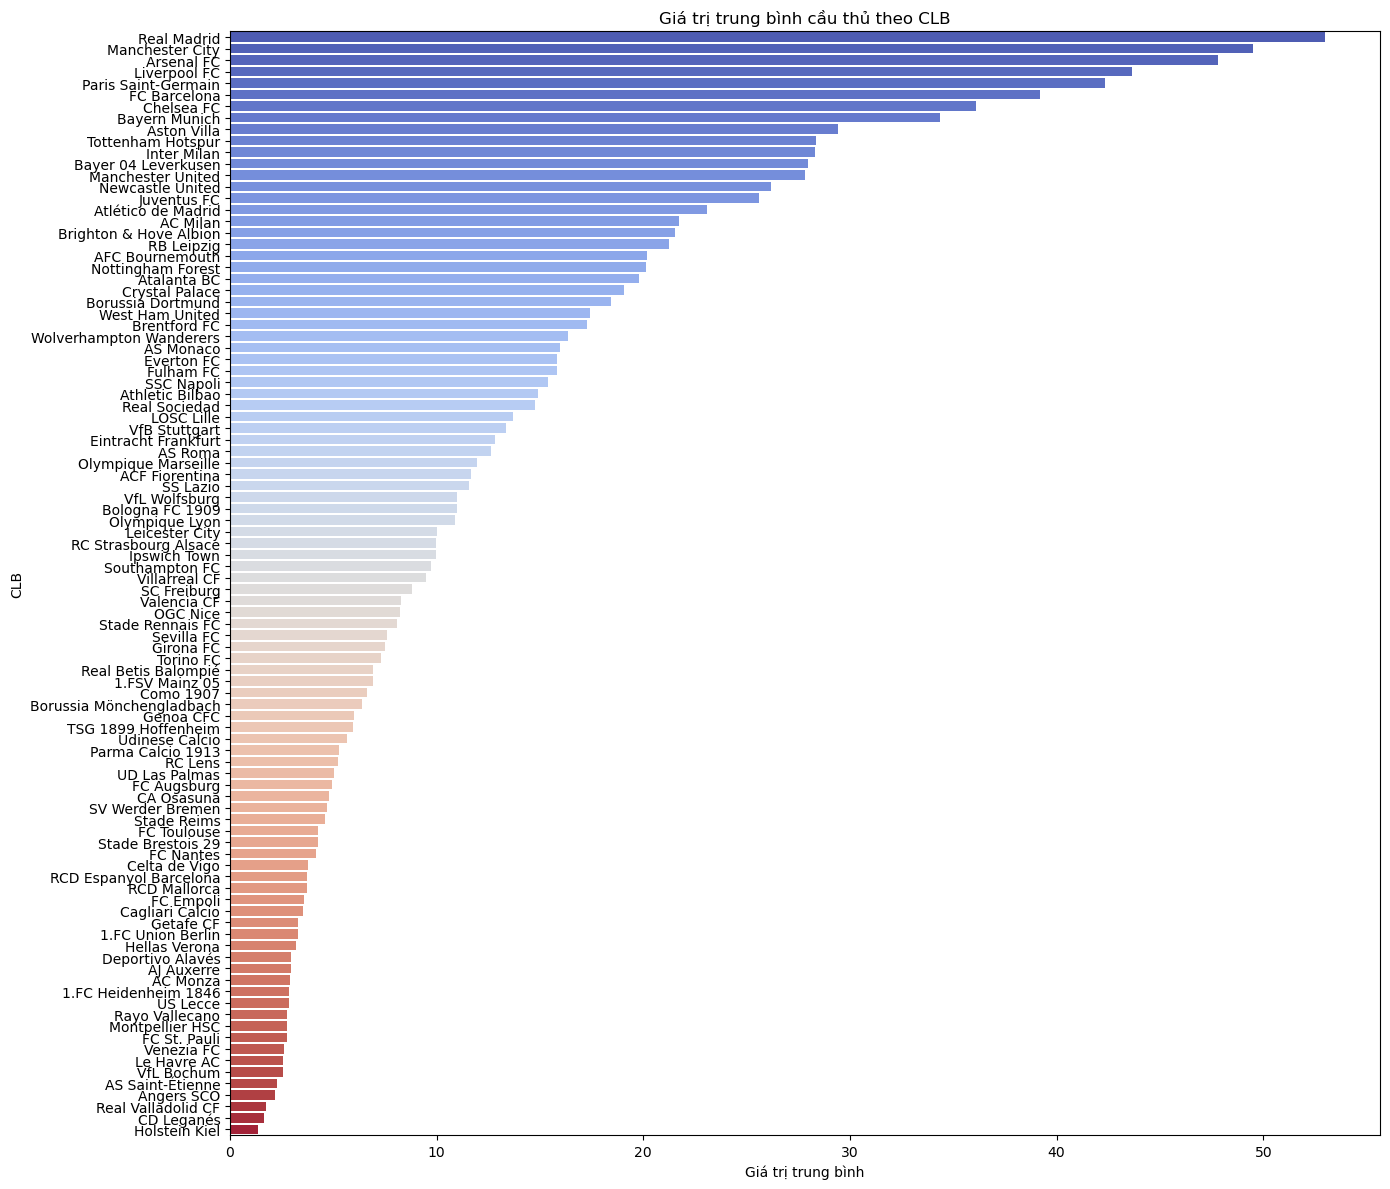

In [129]:
plt.figure(figsize=(14, 12))
sns.barplot(data=avg_value_by_club, x='Market_Value', y='CLB', palette='coolwarm')
plt.title('Giá trị trung bình cầu thủ theo CLB')
plt.xlabel('Giá trị trung bình')
plt.ylabel('CLB')
plt.tight_layout()
plt.show()


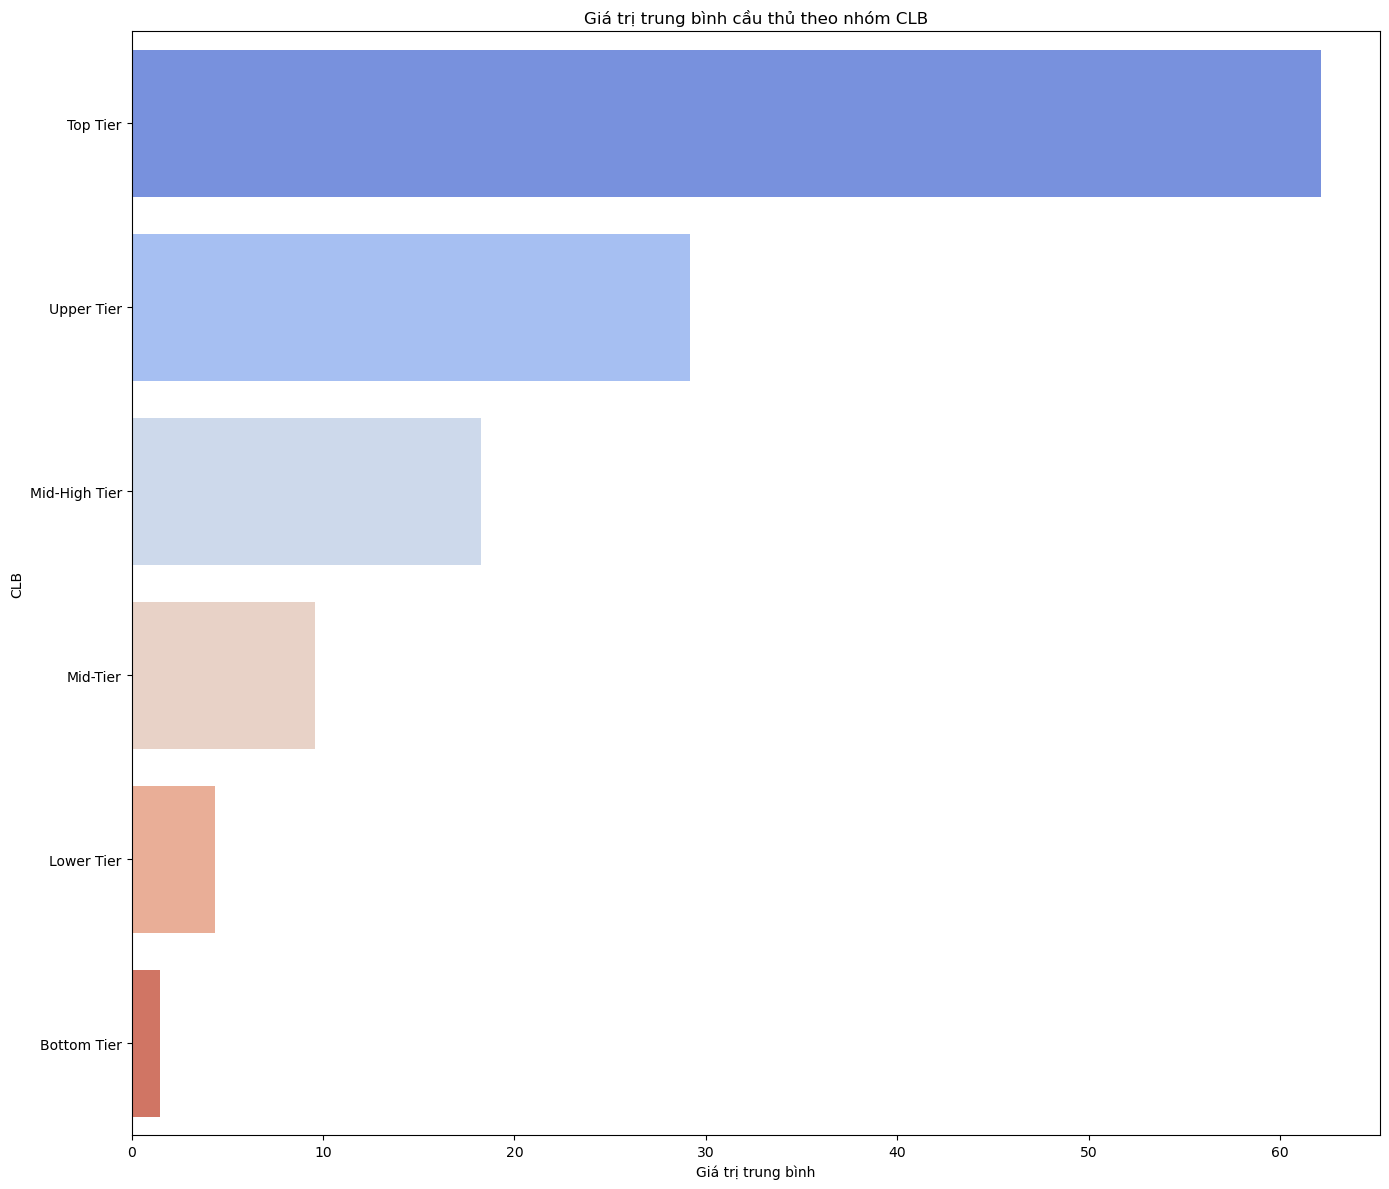

In [130]:
# Nhóm CLB thành các group như sau : 
def classify_market_value(value):
    if value >= 40:
        return 'Top Tier' # Tầm cao nhất
    elif value >= 25:
        return 'Upper Tier' # Tầm cao
    elif value >= 15:
        return 'Mid-High Tier' # Trung bình khá
    elif value >= 7:
        return 'Mid-Tier' # Trung bình
    elif value >= 3:
        return 'Lower Tier' # Thấp
    else:
        return 'Bottom Tier' # Rất thấp
    
data['Club_Group'] = data['Market_Value'].apply(classify_market_value)


avg_value_by_club = data.groupby('Club_Group')['Market_Value'].mean().reset_index()
avg_value_by_club = avg_value_by_club.sort_values('Market_Value', ascending=False)
plt.figure(figsize=(14, 12))

sns.barplot(data=avg_value_by_club, x='Market_Value', y='Club_Group', palette='coolwarm')
plt.title('Giá trị trung bình cầu thủ theo nhóm CLB')
plt.xlabel('Giá trị trung bình')
plt.ylabel('CLB')
plt.tight_layout()
plt.show()

## Goals and MotM and Rating 

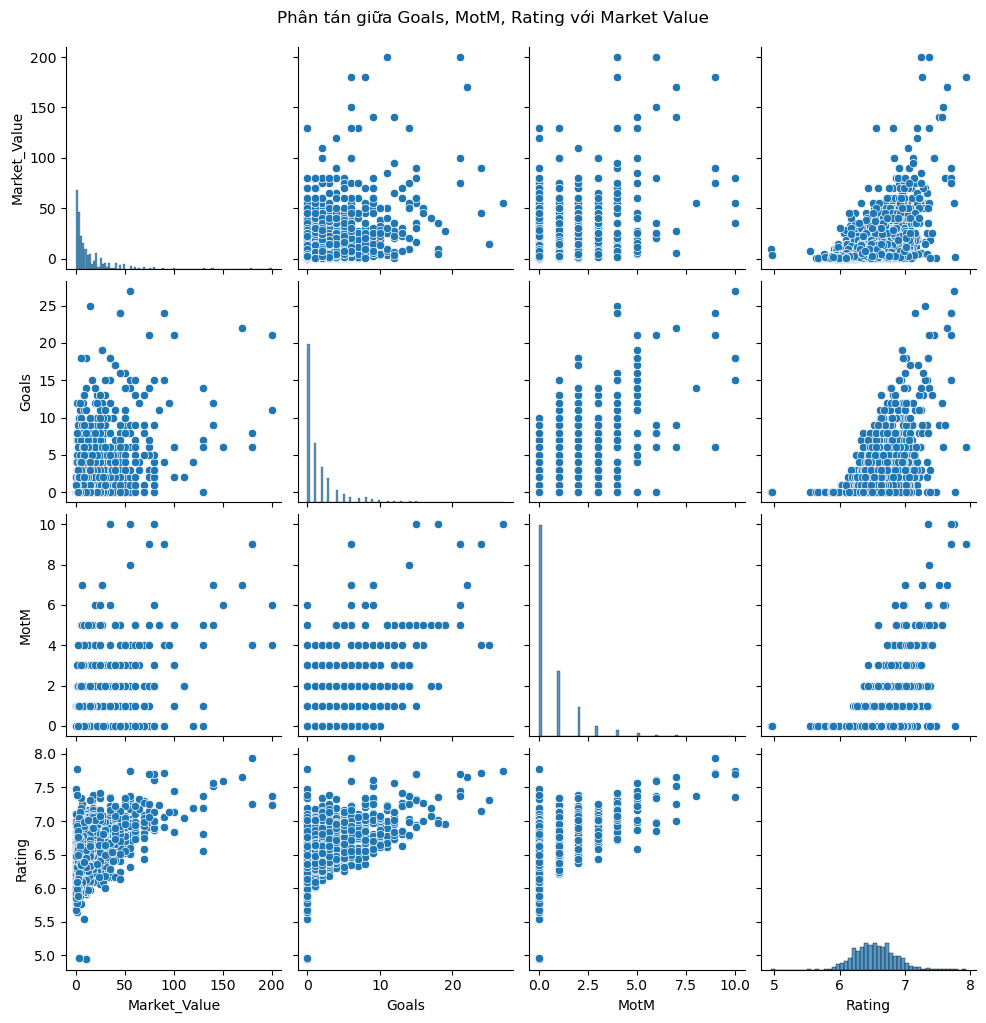

In [131]:
sns.pairplot(data[['Market_Value', 'Goals', 'MotM', 'Rating']])
plt.suptitle("Phân tán giữa Goals, MotM, Rating với Market Value", y=1.02)
plt.show()


In [132]:
# Sắp xếp giảm dần theo số lần được MotM
top_20_motm = data.sort_values(by='MotM', ascending=False).head(20)

# Lấy ra các cột cần thiết
top_20_motm_info = top_20_motm[['Player', 'MotM', 'Market_Value', 'Age']]


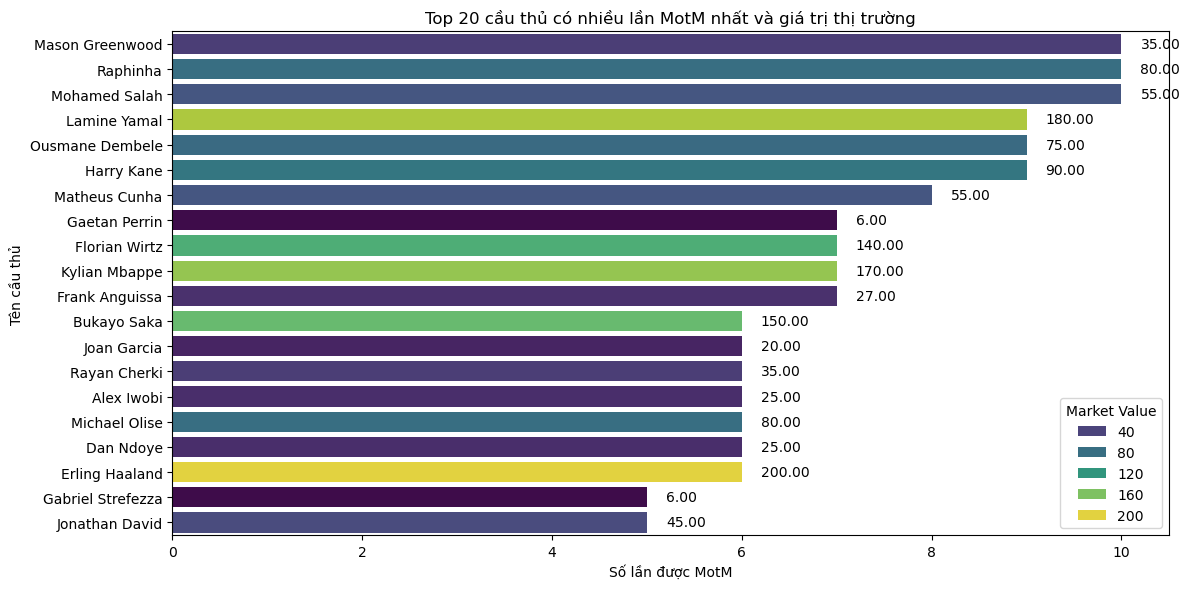

In [133]:
plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=top_20_motm_info, x='MotM', y='Player', hue='Market_Value', dodge=False, palette='viridis')
plt.title('Top 20 cầu thủ có nhiều lần MotM nhất và giá trị thị trường')
plt.xlabel('Số lần được MotM')
plt.ylabel('Tên cầu thủ')
plt.legend(title='Market Value')
plt.tight_layout()
for i, (motm, player, mv) in enumerate(zip(top_20_motm_info['MotM'], top_20_motm_info['Player'], top_20_motm_info['Market_Value'])):
    barplot.text(
        motm + 0.2,   # đặt vị trí text hơi lệch phải so với thanh
        i,            # đúng thứ tự y
        f'{mv:.2f}',  # format giá trị market value
        color='black',
        va='center'
    )

plt.tight_layout()
plt.show()
plt.show()


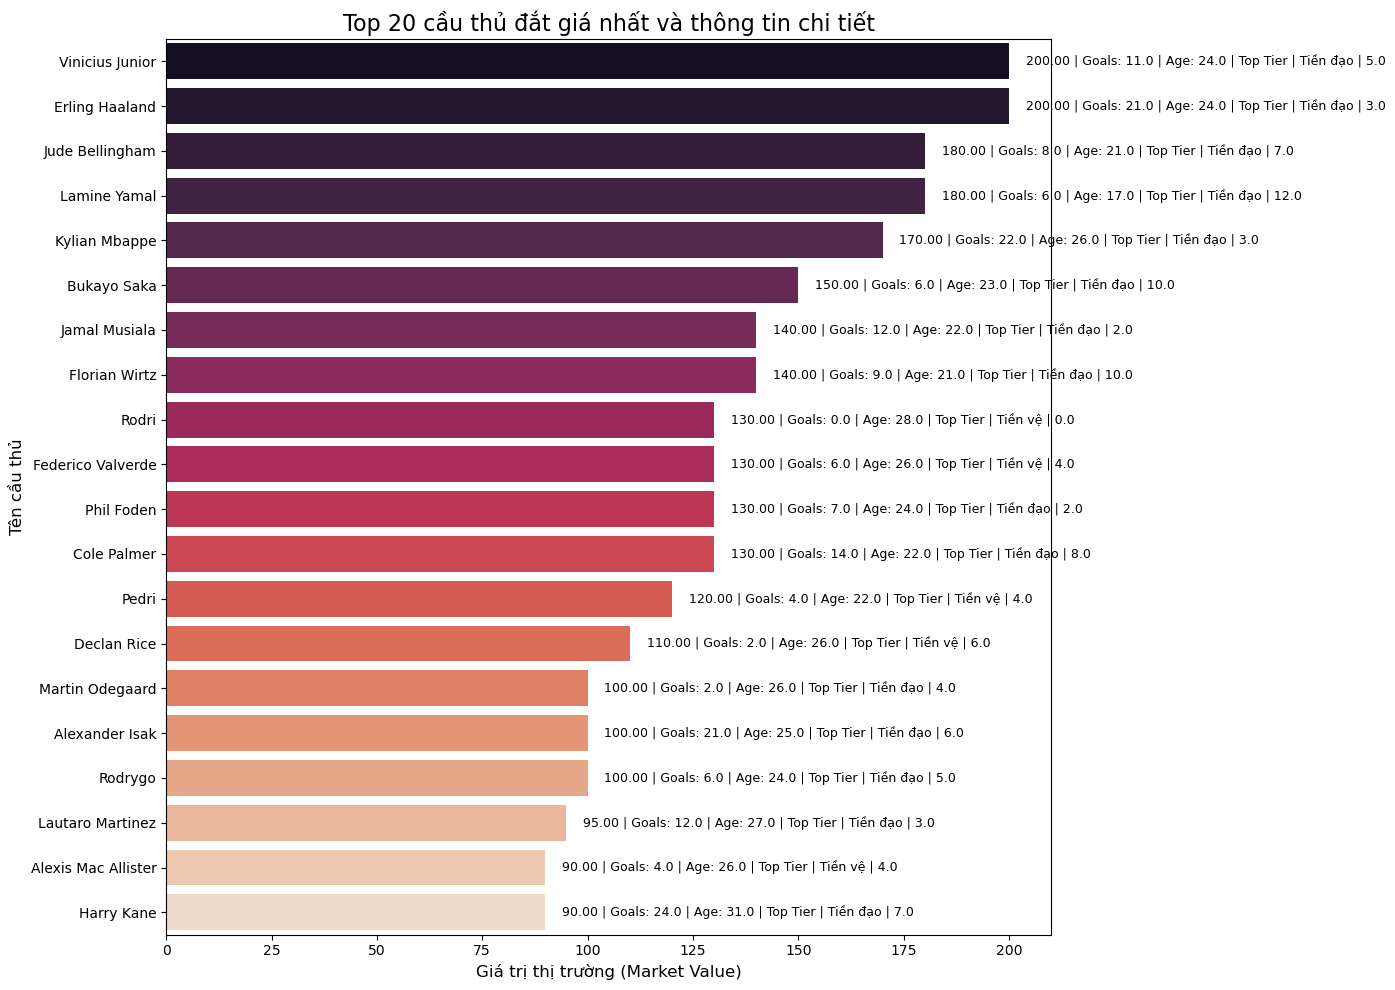

In [134]:
top_player = data[['Player', 'Market_Value', 'Goals', 'Age', 'League', 'CLB', 'Club_Group', 'Position_Group', 'Assists']].sort_values(
    by='Market_Value', ascending=False).head(20)

plt.figure(figsize=(14, 10))
sns.barplot(
    data=top_player,
    x='Market_Value',
    y='Player',
    palette='rocket'
)

plt.title('Top 20 cầu thủ đắt giá nhất và thông tin chi tiết', fontsize=16)
plt.xlabel('Giá trị thị trường (Market Value)', fontsize=12)
plt.ylabel('Tên cầu thủ', fontsize=12)

# Hiển thị nhãn gồm Market Value, Goals, Age, League, Club
for i, (value, goals, age, league, group_club, position, club, assist) in enumerate(zip(
        top_player['Market_Value'],
        top_player['Goals'],
        top_player['Age'],
        top_player['League'],
        top_player['Club_Group'],
        top_player['Position_Group'],
        top_player['CLB'],
        top_player['Assists'])):

    label = f'{value:.2f} | Goals: {goals} | Age: {age} | {group_club} | {position} | {assist}'
    plt.text(value + 0.02 * top_player['Market_Value'].max(), i, label,
             va='center', fontsize=9)

plt.tight_layout()
plt.show()


- Các vị trí Tiện Đạo và Tiền Vệ là những vị trí có giá trị cao 
- Nếu Tiền Đaọ có giá trị cao thì số bàn thắng phải nhiều
- Nếu Tiền Vệ có giá trị cao thì số kiến tạo phải nhiều
- 20 người có giá trị cao nhất đều nằm trong nhóm các CLB (Top Tier)

In [135]:
data.columns

Index(['Player', 'CLB', 'League', 'Age', 'National', 'Height', 'Main_position',
       'Foot', 'Market_Value', 'Months_left', 'Start_app', 'Sub_app', 'Mins',
       'Goals', 'Assists', 'Yel', 'Red', 'SpG', 'PS%', 'AerialsWon', 'MotM',
       'Rating', 'TotAD', 'WonAD', 'LostAD', 'CrAss', 'CorAss', 'ThrbAss',
       'FreAss', 'ThrInAss', 'OthAss', 'TotAss', 'BlkSh', 'BlkCr', 'BlkPs',
       'YelC', 'RedC', 'TotClr', 'UnDrib', 'SucDrib', 'TotDrib', 'Fouled',
       'Fouls', 'TotGs', 'SYBGs', 'PAGs', 'OOBGs', 'TotInt', 'TotKPs', 'LKPs',
       'SKPs', 'COF', 'TotPs', 'AccLB', 'InAccLB', 'AccSP', 'InAccSP', 'UnTch',
       'Dispo', 'TotSav', 'SYBSav', 'PASav', 'OOBSav', 'TotSh', 'OOBSh',
       'SYBSh', 'PASh', 'TotTkl', 'DribPast', 'TotAttTkl', 'Market_Value_log',
       'Card', 'Position_Group', 'Continent', 'Continent_Grouped',
       'Club_Group'],
      dtype='object')

In [136]:
# Thuộc tính ThInAss chỉ có 1 giá trị => Không mang lại lợi ích cho mô hình 
data['ThrInAss'].unique()

array([0.])

In [137]:
data = data.drop(columns= ['Player', 'ThrInAss'])
data_encoded = data.copy()
drop_col = ['CLB', 'National', 'Main_position', 'Yel', 'Red', 'Continent', 'Market_Value_log']
data_encoded = data_encoded.drop(columns= drop_col)

In [138]:
one_hot_encoded_col = ['League', 'Foot', 'Position_Group', 'Continent_Grouped', 'Club_Group']

data_encoded = pd.get_dummies(data_encoded, columns=one_hot_encoded_col, prefix=one_hot_encoded_col, drop_first= True)


In [139]:
data_encoded.columns

Index(['Age', 'Height', 'Market_Value', 'Months_left', 'Start_app', 'Sub_app',
       'Mins', 'Goals', 'Assists', 'SpG', 'PS%', 'AerialsWon', 'MotM',
       'Rating', 'TotAD', 'WonAD', 'LostAD', 'CrAss', 'CorAss', 'ThrbAss',
       'FreAss', 'OthAss', 'TotAss', 'BlkSh', 'BlkCr', 'BlkPs', 'YelC', 'RedC',
       'TotClr', 'UnDrib', 'SucDrib', 'TotDrib', 'Fouled', 'Fouls', 'TotGs',
       'SYBGs', 'PAGs', 'OOBGs', 'TotInt', 'TotKPs', 'LKPs', 'SKPs', 'COF',
       'TotPs', 'AccLB', 'InAccLB', 'AccSP', 'InAccSP', 'UnTch', 'Dispo',
       'TotSav', 'SYBSav', 'PASav', 'OOBSav', 'TotSh', 'OOBSh', 'SYBSh',
       'PASh', 'TotTkl', 'DribPast', 'TotAttTkl', 'Card', 'League_EPL',
       'League_Laliga', 'League_Ligue1', 'League_SerieA', 'Foot_left',
       'Foot_right', 'Position_Group_Tiền vệ', 'Position_Group_Tiền đạo',
       'Continent_Grouped_Europe', 'Continent_Grouped_Other',
       'Club_Group_Lower Tier', 'Club_Group_Mid-High Tier',
       'Club_Group_Mid-Tier', 'Club_Group_Top Tier', 'Cl

# Correlation Matrix

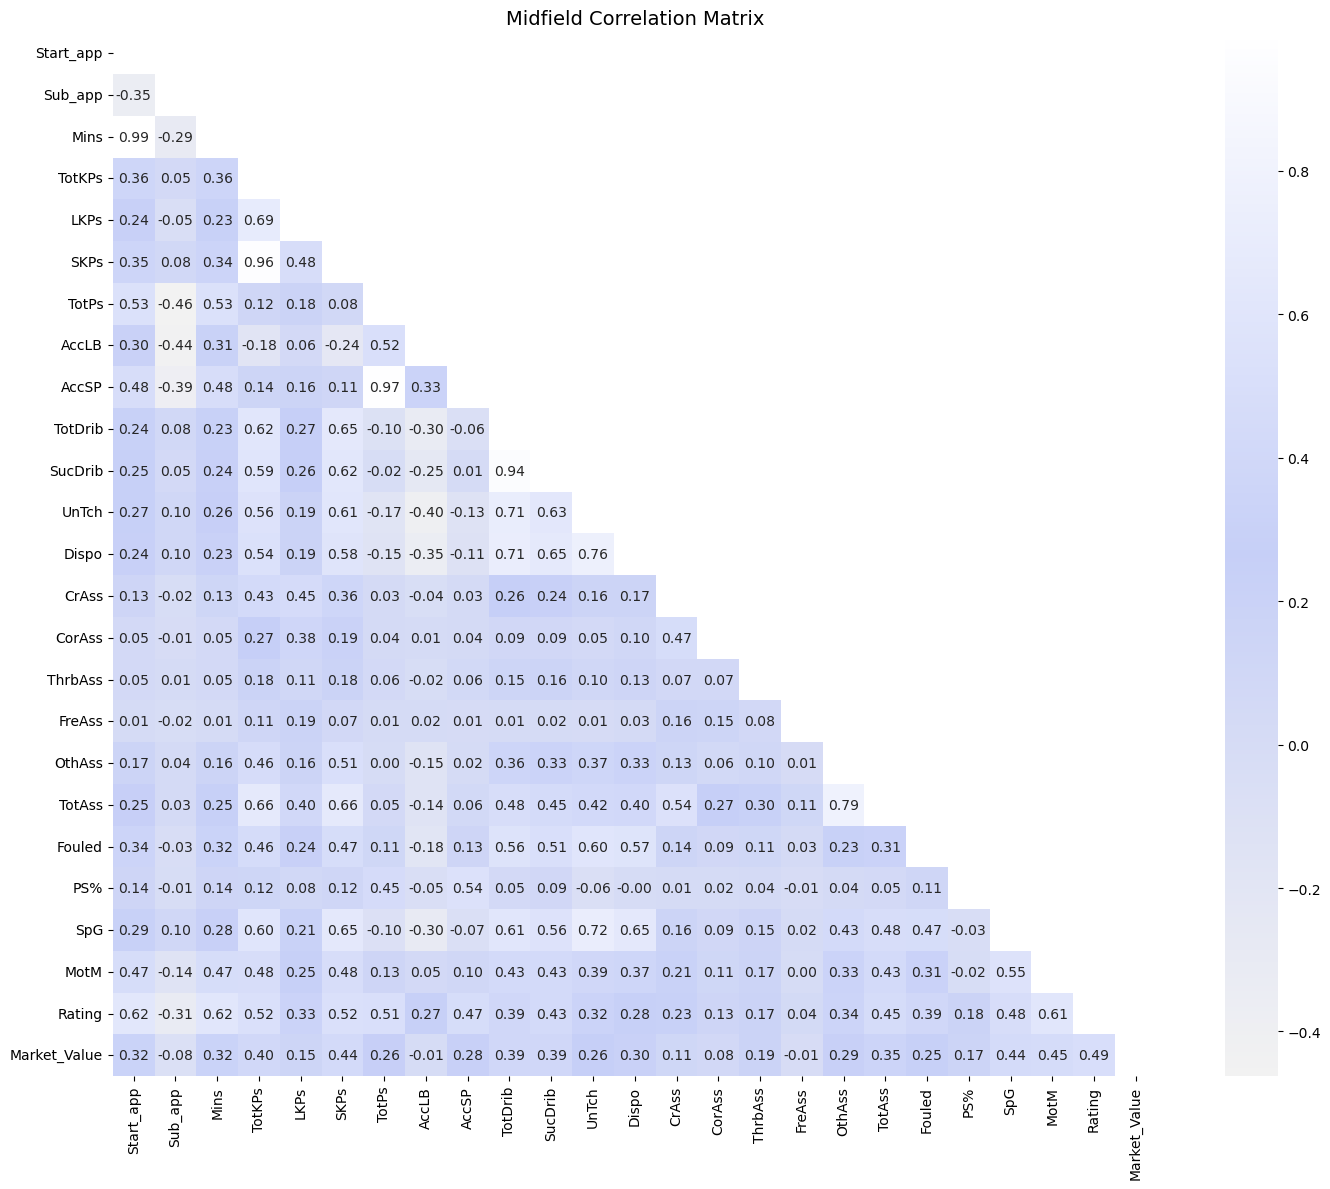

In [140]:
from matplotlib.colors import LinearSegmentedColormap

midfield_cols = [
    "Start_app",  # Số trận đá chính
    "Sub_app",    # Số trận vào sân thay người
    "Mins",       # Số phút thi đấu (mọi vị trí)
    
    "TotKPs",     # Key Pass (đường chuyền tạo cơ hội)
    "LKPs",       # Key Pass từ xa
    "SKPs",       # Key Pass từ gần
    
    "TotPs",      # Tổng số đường chuyền
    "AccLB",      # Đường chuyền dài chính xác
    "AccSP",      # Đường chuyền ngắn chính xác
    
    "TotDrib",    # Tổng số pha rê bóng
    "SucDrib",    # Số pha rê bóng thành công
    "UnTch",      # Số lần chạm bóng lỗi
    "Dispo",      # Mất bóng
    
    "CrAss",      # Kiến tạo từ phạt góc
    "CorAss",     # Kiến tạo từ chọc khe
    "ThrbAss",    # Kiến tạo từ phạt trực tiếp
    "FreAss",     # Kiến tạo từ đá phạt (?)
    "OthAss",     # Các loại kiến tạo khác
    "TotAss",     # Tổng số kiến tạo
    
    "Fouled",     # Bị phạm lỗi (tiền vệ công thường bị)
    
    "PS%",        # Tỷ lệ chuyền chính xác (%)
    "SpG",        # Sút mỗi trận (tiền vệ hoặc tiền đạo)
    
    "MotM",       # Man of the Match (cầu thủ xuất sắc nhất trận)
    "Rating",     # Đánh giá chung hiệu suất cầu thủ
    "Market_Value"
]

Offensive_df = data_encoded[midfield_cols]
corr = Offensive_df.corr ()

plt.figure (figsize=(15,12))
mask = np.triu(np.ones_like(corr, dtype=bool))

# Tạo một cmap pastel nhẹ nhàng: Xám nhạt → hồng nhạt → trắng
pastel = LinearSegmentedColormap.from_list("pastel_sang", ["#f2f2f2", "#c6cff7", "#ffffff"])

sns.heatmap (corr, annot=True, fmt='.2f', cmap=pastel, square=True, mask=mask)
plt.title ("Midfield Correlation Matrix", fontsize=14)
plt.tight_layout ()
plt.show ()

- Đối với một cầu thủ ở vị trí Tiền Vệ .Giá trị thị trường của các tiền vệ có tương quan mạnh với : 
    + Điểm trung bình được các nhà báo thể thao đánh giá sau mỗi trận : Rating (0.49)
    + Số lần được bầu là cầu thủ xuất săc nhất trận : MotM (0.45)
    + Số cú sút trung bình mỗi trận : SpG(0.44)
    + Số đường truyền ngắn : SKPs(0.44)
    + Tổng số đường truyền quyết đinh : TotKPs (0.40)


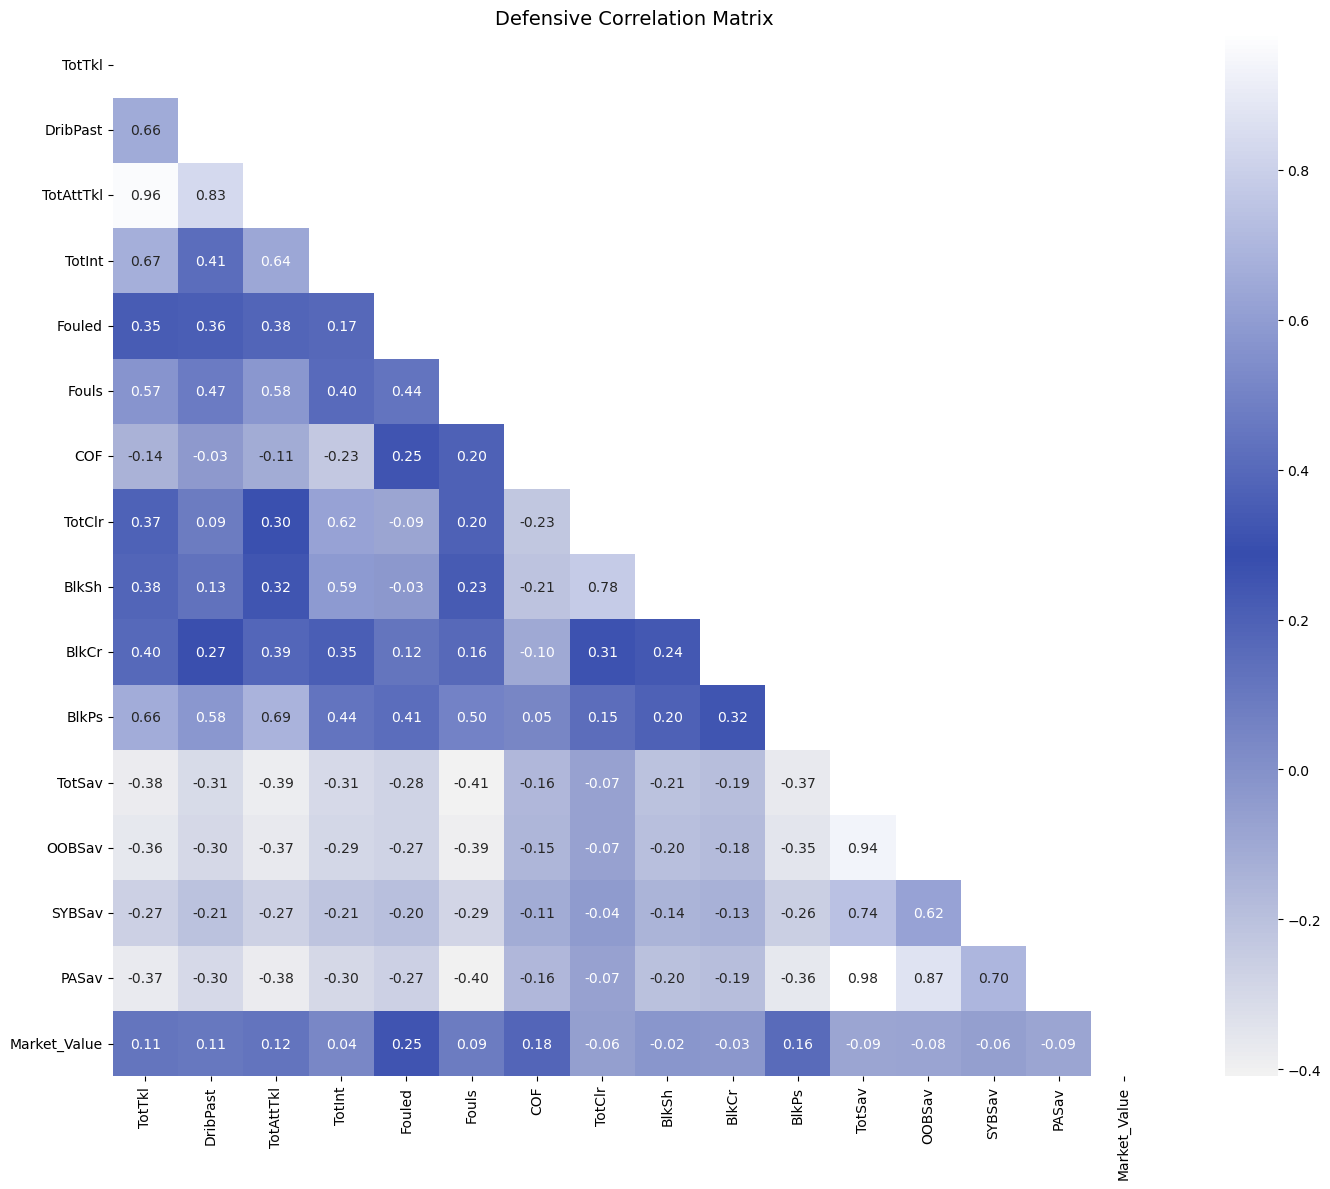

In [141]:
from matplotlib.colors import LinearSegmentedColormap

defensive_cols = [
    'TotTkl', 'DribPast', 'TotAttTkl', 'TotInt',  
    'Fouled', 'Fouls', 'COF', 'TotClr',  
    'BlkSh', 'BlkCr', 'BlkPs',    
    'TotSav', 'OOBSav',                   
    'SYBSav', 'PASav',         
    'Market_Value'
]

Defensive_df = data_encoded[defensive_cols]
corr = Defensive_df.corr ()

plt.figure (figsize=(15,12))
mask = np.triu(np.ones_like(corr, dtype=bool))

# Tạo một cmap pastel nhẹ nhàng: Xám nhạt → hồng nhạt → trắng
pastel = LinearSegmentedColormap.from_list("pastel_sang", ["#f2f2f2", "#364cad", "#ffffff"])

sns.heatmap (corr, annot=True, fmt='.2f', cmap=pastel, square=True, mask=mask)
plt.title ("Defensive Correlation Matrix", fontsize=14)
plt.tight_layout ()
plt.show ()

- Giá trị các cầu thủ Phòng ngự có tương quan mạnh đến Fouled (0.25)

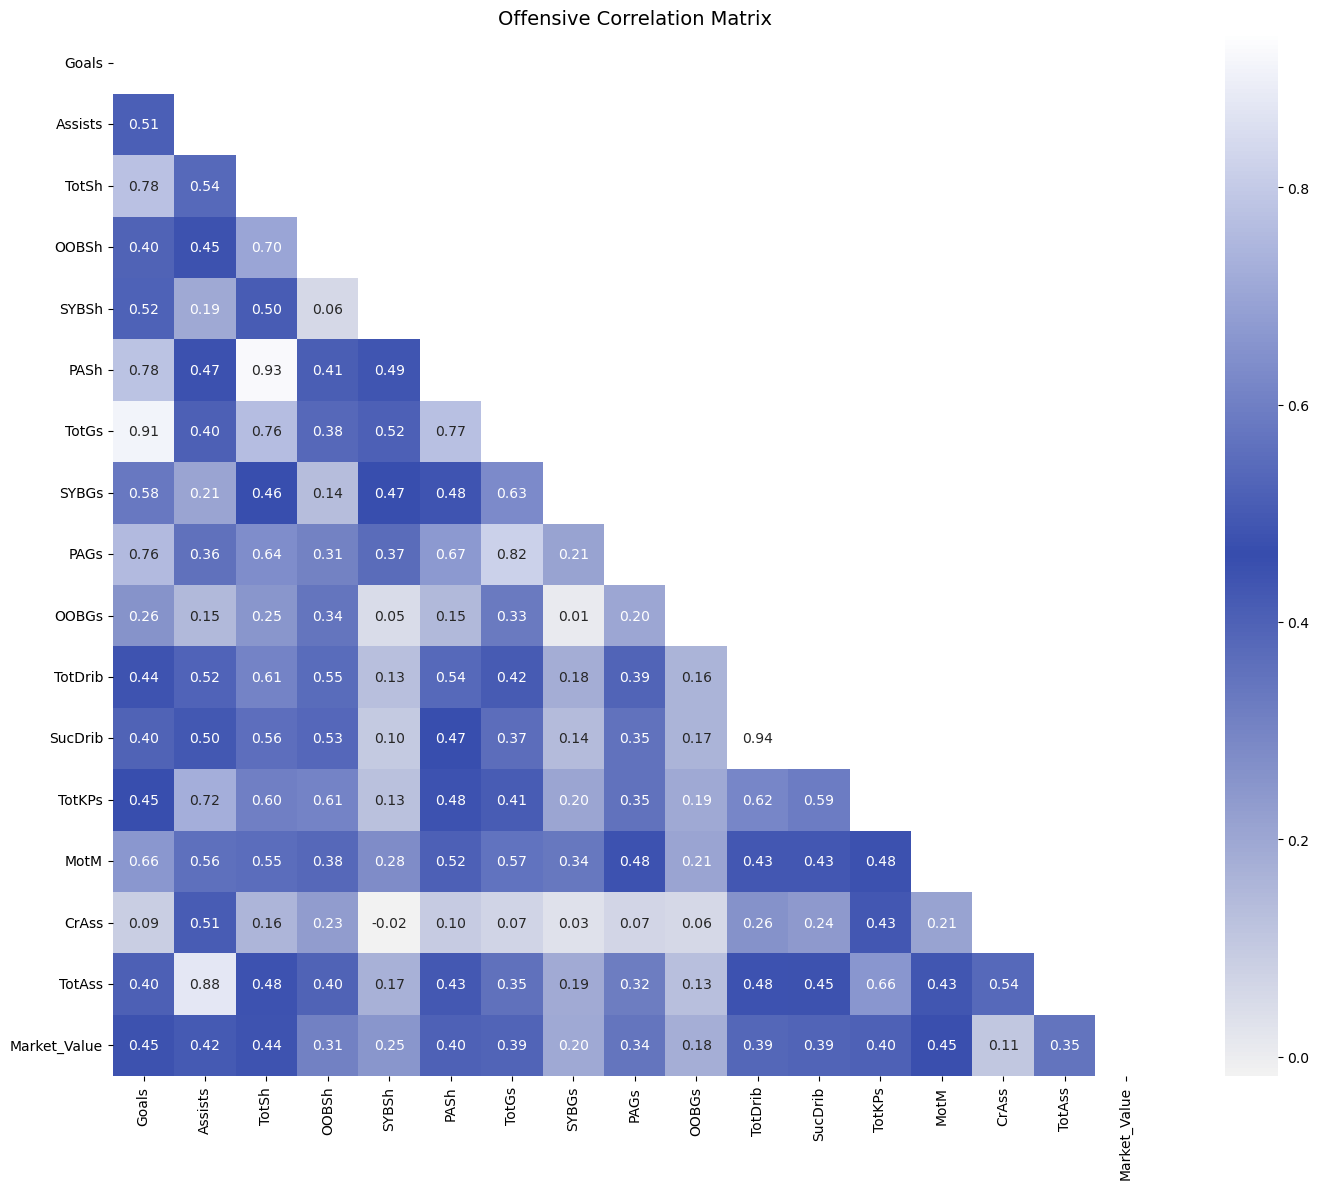

In [142]:
Offensive_cols = [
    "Goals",       # Ghi bàn
    "Assists",     # Kiến tạo
    
    "TotSh",       # Tổng số cú sút
    "OOBSh",       # Cú sút ngoài vòng cấm
    "SYBSh",       # Cú sút trong khu vực penalty
    "PASh",        # Cú sút từ tình huống phạt (phạt đền/phạt trực tiếp?)
    
    "TotGs",       # Tổng số bàn thắng
    "SYBGs",       # Bàn thắng trong khu vực penalty
    "PAGs",        # Bàn thắng trong khu vực phạt đền (?)
    "OOBGs",       # Bàn thắng ngoài vòng cấm
    
    "TotDrib",     # Tổng số pha rê bóng (tấn công)
    "SucDrib",     # Số pha rê bóng thành công
    
    "TotKPs",      # Key pass (đường chuyền tạo cơ hội) - quan trọng với tiền đạo lùi
    
    "MotM",        # Man of the Match (tiền đạo thường nhận nhất)
    
    "CrAss",       # Kiến tạo từ phạt góc (hoặc kiểu kiến tạo cụ thể)
    "TotAss",      # Tổng số kiến tạo
    "Market_Value"
]


Offensive_df = data_encoded[Offensive_cols]
corr = Offensive_df.corr ()

plt.figure (figsize=(15,12))
mask = np.triu(np.ones_like(corr, dtype=bool))

# Tạo một cmap pastel nhẹ nhàng: Xám nhạt → hồng nhạt → trắng
pastel = LinearSegmentedColormap.from_list("pastel_sang", ["#f2f2f2", "#364cad", "#ffffff"])

sns.heatmap (corr, annot=True, fmt='.2f', cmap=pastel, square=True, mask=mask)
plt.title ("Offensive Correlation Matrix", fontsize=14)
plt.tight_layout ()
plt.show ()

- Đối với những cầu thủ trên mặt trận tấn công. Giá trị cầu thủ có tương quan mạnh với: 
    + Goal (0.45)
    + Assists (0.42)
    + TotSh (0.44)
    + MotM (0.45)

# Descriptive statistics and statistical tests

- Giá trị trung bình (Mean) : là một chỉ số thống kê xác định giá trị trung bình của từng thuộc tính 
- Độ lệch chuẩn (standard deviation) : đo lường mức độ biến thiên hay phân tán so với giá trị trung bình  
    + Phản ánh mức độ nhất quán hoặc giao động trong các chỉ số về chất lượng cầu thủ 
- Kiểm định Jarque-Bera (JB) : được sử đụng để đánh giá tính phân phối của dữ liệu 
- Kiểm định Durbin-Watson (DW) : dùng để phát hiện tự tương quan (autocorrelation)
- Kiểm định t-test : được sử dụng để so sánh giá trị trung bình giữa các nhóm khác nhau

In [143]:
from scipy.stats import jarque_bera, ttest_1samp
from statsmodels.stats.stattools import durbin_watson



# Tạo danh sách lưu kết quả
results = []

# Giả định giá trị trung bình cần so sánh trong t-test là 0
# (tuỳ bài toán, có thể đổi hoặc loại bỏ nếu không cần)
for col in data_encoded.columns:
    series = data_encoded[col]

    # JB Test
    jb_stat, jb_p = jarque_bera(series)
    
    # DW Test (áp dụng lên phần dư nếu có mô hình hồi quy – ở đây chỉ làm mẫu)
    # Nếu không có residuals, ta dùng giả định đơn giản:
    dw_stat = durbin_watson(series)  # KHÔNG hoàn toàn chính xác nếu không phải là residuals
    
    # t-Test so với giả định mean=0 (tuỳ bài toán)
    t_stat, t_p = ttest_1samp(series, popmean=0)
    
    # Mean và Std
    mean_val = series.mean()
    std_val = series.std()

    # Format kết quả
    results.append({
        'Feature': col,
        'JB Test (p-value)': f"{jb_stat:.3f} ({'<0.01' if jb_p < 0.01 else ('<0.05' if jb_p < 0.05 else f'{jb_p:.2f}')} )",
        'DW test': f"{dw_stat:.3f}",
        't-Test (p-value)': f"{t_stat:.3f} ({'<0.01' if t_p < 0.01 else ('<0.05' if t_p < 0.05 else f'{t_p:.2f}')} )",
        'Mean': f"{mean_val:.2f}",
        'Standard Dev': f"{std_val:.2f}"
    })

# Chuyển sang DataFrame
results_df = pd.DataFrame(results)

# Hiển thị bảng
print(results_df.to_string(index=False))


                 Feature     JB Test (p-value) DW test  t-Test (p-value)    Mean Standard Dev
                     Age       55.050 (<0.01 )   0.052  280.108 (<0.01 )   26.17         4.43
                  Height       17.369 (<0.01 )   0.003 1292.945 (<0.01 )  183.22         6.72
            Market_Value    54917.640 (<0.01 )   1.199   32.933 (<0.01 )   13.14        18.92
             Months_left       83.942 (<0.01 )   0.706   61.450 (<0.01 )   23.44        18.09
               Start_app      158.856 (<0.01 )   0.654   67.054 (<0.01 )   13.99         9.90
                 Sub_app      537.518 (<0.01 )   0.962   50.979 (<0.01 )    5.30         4.93
                    Mins      141.842 (<0.01 )   0.607   70.738 (<0.01 ) 1251.81       839.23
                   Goals    20886.229 (<0.01 )   1.482   27.381 (<0.01 )    1.76         3.04
                 Assists     7367.789 (<0.01 )   1.326   32.039 (<0.01 )    1.24         1.83
                     SpG     1721.290 (<0.01 )   0.890   51.

In [144]:
for col in data_encoded.columns:
    if data_encoded[col].dtype == 'bool':
        data_encoded[col] = data_encoded[col].astype(int)

### VIF - Feature reduction 

In [145]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant



def calculate_vif(X):
    X = add_constant(X)
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                       for i in range(X.shape[1])]
    vif_data["VIF"] = vif_data["VIF"].round(2)
    return vif_data.drop(index=0)  # Bỏ intercept ra cho dễ nhìn (nếu cần)

# Ví dụ dùng:
# X là DataFrame chứa các biến độc lập
# X = df[["age", "income", "education", "experience"]]

vif_result = calculate_vif(data_encoded)
print(vif_result.sort_values(by="VIF", ascending=False))


                     feature       VIF
55                     TotSh       inf
16                     WonAD       inf
10                       SpG       inf
12                AerialsWon       inf
44                     TotPs  72469.64
47                     AccSP  55637.38
51                    TotSav   3040.12
46                   InAccLB   1741.64
53                     PASav   1213.47
15                     TotAD    964.37
45                     AccLB    761.79
48                   InAccSP    653.93
32                   TotDrib    487.90
61                 TotAttTkl    456.29
54                    OOBSav    340.36
59                    TotTkl    246.17
17                    LostAD    235.08
30                    UnDrib    176.73
40                    TotKPs    165.18
5                  Start_app    128.61
7                       Mins    122.72
42                      SKPs    114.24
31                   SucDrib    100.98
58                      PASh     87.40
60                  DribP

In [146]:
vif_col_inf = []
for i in range(1, len(vif_result)):
    if (vif_result['VIF'][i]) == np.inf or (vif_result['VIF'][i]) >= 10:
        #print(vif_result['feature'][i])
        vif_col_inf.append(vif_result['feature'][i])

vif_col_inf.remove('Goals')
vif_col_inf.remove('Mins')

In [147]:
data_encoded = data_encoded.drop(columns= vif_col_inf)

- VIF = 1 : Không có đa cộng tuyến, biến độc lập không tương quan với các biens khác
- 5 <= VIF <= 10 : Mực đa cộng tuyến cao, cần xem xét lại hoặc kết hợp biến để cải thiện mô hình
- VIF > 10 : Biến có khả năng gây ra những vấn đề nghiêm trọng cho mô hình.

In [148]:
data_encoded

,Age,Height,Market_Value,Months_left,Sub_app,Mins,Goals,Assists,PS%,MotM,Rating,CrAss,CorAss,ThrbAss,FreAss,OthAss,BlkSh,BlkCr,BlkPs,YelC,RedC,TotClr,Fouled,Fouls,SYBGs,PAGs,OOBGs,TotInt,COF,UnTch,Dispo,SYBSh,Card,League_EPL,League_Laliga,League_Ligue1,League_SerieA,Foot_left,Foot_right,Position_Group_Tiền vệ,Position_Group_Tiền đạo,Continent_Grouped_Europe,Continent_Grouped_Other,Club_Group_Lower Tier,Club_Group_Mid-High Tier,Club_Group_Mid-Tier,Club_Group_Top Tier,Club_Group_Upper Tier
0,22.0,188.0,18.0,49.0,5.0,1619.0,7.0,2.0,70.4,3.0,6.84,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.5,0.1,0.0,0.8,1.2,0.6,0.0,0.2,0.0,0.2,0.2,1.7,1.4,0.1,2,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0
1,27.0,186.0,2.0,37.0,14.0,1383.0,2.0,1.0,81.9,0.0,6.55,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.9,0.0,0.0,0.6,0.3,0.6,0.0,0.1,0.0,0.2,0.1,1.2,0.7,0.1,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0
2,32.0,181.0,6.0,13.0,5.0,1812.0,11.0,4.0,75.6,2.0,6.76,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.4,0.1,0.0,0.3,1.2,0.6,0.1,0.3,0.0,0.1,0.3,1.4,0.8,0.2,3,0,0,0,0,0,1,0,1,1,0,1,0,0,0,0
3,27.0,173.0,20.0,49.0,10.0,1295.0,3.0,3.0,91.0,1.0,6.68,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.4,0.1,0.0,0.9,0.3,0.2,0.0,0.0,0.1,0.3,0.0,0.4,0.1,0.0,2,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0
4,20.0,188.0,50.0,49.0,2.0,1250.0,1.0,0.0,94.1,0.0,6.85,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.8,0.1,0.0,0.6,0.5,0.9,0.0,0.0,0.1,0.2,0.0,0.7,0.1,0.0,2,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2244,27.0,180.0,28.0,1.0,3.0,1471.0,2.0,2.0,76.6,0.0,6.81,0.0,0.0,0.0,0.0,0.1,0.2,0.0,0.5,0.0,0.0,1.1,1.5,1.1,0.0,0.0,0.0,0.3,0.2,1.5,0.6,0.2,1,0,0,0,1,1,0,0,1,0,1,0,0,0,0,1
2245,25.0,186.0,8.0,49.0,6.0,369.0,2.0,0.0,77.3,0.0,6.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.1,0.0,0.2,1.3,1.1,0.0,0.0,0.0,0.1,0.1,1.6,0.7,0.2,1,0,0,0,1,0,1,0,1,1,0,0,0,1,0,0
2246,24.0,187.0,2.5,13.0,6.0,946.0,0.0,4.0,71.8,0.0,6.49,0.2,0.1,0.0,0.1,0.1,0.1,0.3,0.2,0.0,0.0,0.3,0.6,0.5,0.0,0.0,0.0,0.3,0.1,1.4,0.5,0.1,0,0,0,0,1,0,1,1,0,1,0,0,0,0,0,0
2247,26.0,178.0,25.0,37.0,1.0,2036.0,10.0,3.0,69.9,4.0,7.08,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.6,0.3,0.0,0.8,1.5,1.3,0.3,0.0,0.0,0.2,0.6,1.8,1.0,0.3,9,0,0,0,1,0,1,0,1,0,1,0,0,0,0,1


## => Bronze data 
- Gold data là data của best model 

In [149]:
data_encoded.to_csv('Silver_data.csv')

# Model 


## Model accuracy metrics
- Các thang đo được sử dụng : 
    + MSE : MSE đo độ lệch trung bình bình phương giữa giá trị dự đoán và thực tế.
    + R square : R² đo lường mức độ mà mô hình hồi quy giải thích được phương sai của dữ liệu thực tế.

### IQR - Loại bỏ Outlier của Market_Value bằng IQR

In [150]:
# Hàm phát hiện và loại bỏ ngoại lai bằng IQR
def remove_outliers_iqr(X, y):
    Q1 = np.percentile(y, 25)
    Q3 = np.percentile(y, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (y >= lower_bound) & (y <= upper_bound)
    return X[mask], y[mask]


### Winsorize - Loại bỏ Outlier của Market_Value bằng Winsorize 

In [151]:
def winsorize_data(y, lower_percentile=5, upper_percentile=95):
    lower_bound = np.percentile(y, lower_percentile)
    upper_bound = np.percentile(y, upper_percentile)
    y_winsorized = np.clip(y, lower_bound, upper_bound)
    return y_winsorized

## Linear Regression 

In [152]:
data_lr = data_encoded.copy()

In [153]:
data_lr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2249 entries, 0 to 2248
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       2249 non-null   float64
 1   Height                    2249 non-null   float64
 2   Market_Value              2249 non-null   float64
 3   Months_left               2249 non-null   float64
 4   Sub_app                   2249 non-null   float64
 5   Mins                      2249 non-null   float64
 6   Goals                     2249 non-null   float64
 7   Assists                   2249 non-null   float64
 8   PS%                       2249 non-null   float64
 9   MotM                      2249 non-null   float64
 10  Rating                    2249 non-null   float64
 11  CrAss                     2249 non-null   float64
 12  CorAss                    2249 non-null   float64
 13  ThrbAss                   2249 non-null   float64
 14  FreAss  

In [154]:
correlation_matrix = data_lr.corr()

print('Các biến có tương quan cao với Foot_right (> 0.8):')
for feature, corr_value in correlation_matrix['Foot_right'].items():
    if feature != 'Foot_right' and abs(corr_value) > 0.8:
        print(f'{feature}: {corr_value:.2f}')

print('Các biến có tương quan cao so với Foot_left (> 0.8) : ')
for f, v in correlation_matrix['Foot_left'].items():
    if f != 'Foot_left' and abs(v) > 0.8:
        print(f'{f}: {v:.2f}')




Các biến có tương quan cao với Foot_right (> 0.8):
Foot_left: -0.92
Các biến có tương quan cao so với Foot_left (> 0.8) : 
Foot_right: -0.92


In [155]:
# Loại bỏ Foot_left và tính lại VIF
#data_lr = data_lr.drop(columns= 'Foot_left')
vif_result = calculate_vif(data_lr)
print(vif_result.sort_values(by="VIF", ascending=False))

                     feature   VIF
7                      Goals  7.61
38                 Foot_left  7.14
39                Foot_right  7.11
47       Club_Group_Top Tier  5.38
8                    Assists  5.32
3               Market_Value  5.24
22                    TotClr  4.48
30                     UnTch  4.14
33                      Card  3.77
41   Position_Group_Tiền đạo  3.70
26                      PAGs  3.62
6                       Mins  3.58
11                    Rating  3.57
31                     Dispo  3.09
17                     BlkSh  2.84
28                    TotInt  2.66
10                      MotM  2.56
48     Club_Group_Upper Tier  2.54
16                    OthAss  2.45
25                     SYBGs  2.37
24                     Fouls  2.36
20                      YelC  2.32
37             League_SerieA  2.20
34                League_EPL  2.16
40    Position_Group_Tiền vệ  2.15
45  Club_Group_Mid-High Tier  2.10
12                     CrAss  2.10
42  Continent_Groupe

In [156]:
# Loại bỏ Foot_left và tính lại VIF
data_lr_temp = data_lr.drop(columns= 'Foot_right')
vif_result = calculate_vif(data_lr_temp)
print(vif_result.sort_values(by="VIF", ascending=False))

                     feature   VIF
7                      Goals  7.61
46       Club_Group_Top Tier  5.38
8                    Assists  5.32
3               Market_Value  5.23
22                    TotClr  4.48
30                     UnTch  4.14
33                      Card  3.77
40   Position_Group_Tiền đạo  3.70
26                      PAGs  3.62
6                       Mins  3.58
11                    Rating  3.57
31                     Dispo  3.09
17                     BlkSh  2.84
28                    TotInt  2.66
47     Club_Group_Upper Tier  2.54
10                      MotM  2.54
16                    OthAss  2.45
25                     SYBGs  2.37
24                     Fouls  2.36
20                      YelC  2.32
37             League_SerieA  2.20
34                League_EPL  2.15
39    Position_Group_Tiền vệ  2.14
12                     CrAss  2.10
44  Club_Group_Mid-High Tier  2.10
41  Continent_Grouped_Europe  2.07
23                    Fouled  2.06
19                  

- Việc loại bỏ Foot_left hoặc Foot_right làm cho mô hình thiếu ổn định => giữ lại Foot_left và Foot_right

In [157]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [158]:
X = data_lr.drop(columns= 'Market_Value')
y = data_lr['Market_Value']

### Function

In [159]:
def Standard_X(X_scaler, X_train, X_dev, X_test):
    # Chuẩn hóa dữ liệu 

    # Chuẩn hóa X
    X_train_scaled = X_scaler.fit_transform(X_train)
    X_dev_scaled = X_scaler.transform(X_dev)
    X_test_scaled = X_scaler.transform(X_test)

    return X_train_scaled, X_dev_scaled, X_test_scaled

In [160]:
def Standard_y(y_scaler, y_train, y_dev, y_test):
    y_train_scaled = y_scaler.fit_transform(np.array(y_train).reshape(-1, 1)).ravel()
    y_dev_scaled = y_scaler.transform(np.array(y_dev).reshape(-1, 1)).ravel()
    y_test_scaled = y_scaler.transform(np.array(y_test).reshape(-1, 1)).ravel()

    return y_train_scaled, y_dev_scaled, y_test_scaled

In [161]:
def evaluate(y_train_pred, y_train, y_dev_pred, y_dev, y_test_pred, y_test):
    train_mse = mean_squared_error(y_train, y_train_pred)
    dev_mse = mean_squared_error(y_dev, y_dev_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    dev_r2 = r2_score(y_dev, y_dev_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    dev_mae = mean_absolute_error(y_dev, y_dev_pred)

    return  train_mse, dev_mse, test_mse, train_r2, dev_r2, test_r2, train_mae, dev_mae, test_mae

In [162]:
def predict_func(model, X_train, X_dev, X_test):
    y_train_pred = model.predict(X_train)
    y_dev_pred = model.predict(X_dev)
    y_test_pred = model.predict(X_test)

    return y_train_pred, y_dev_pred, y_test_pred

### Ridge original and not Outlier 

In [163]:
# Chia lại tập dữ liệu 
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size= 0.4, random_state= 32)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size= 0.5, random_state= 32)

# Chuẩn hóa dữ liệu 
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled, X_dev_scaled, X_test_scaled = Standard_X(X_scaler, X_train, X_dev, X_test)
y_train_scaled, y_dev_scaled, y_test_scaled = Standard_y(y_scaler, y_train, y_dev, y_test)


# 3. Tìm tham số tối ưu bằng GridSearchCV
ridge = Ridge()

# Train
model = ridge.fit(X_train_scaled, y_train_scaled)

# Dự đoán 
y_train_pred_scaled, y_dev_pred_scaled, y_test_pred_scaled = predict_func(model, X_train_scaled, X_dev_scaled, X_test_scaled)

# Chuyển dự đoán và giá trị thực về đơn vị gốc
y_train_pred = (y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel())
y_dev_pred   = (y_scaler.inverse_transform(y_dev_pred_scaled.reshape(-1, 1)).ravel())
y_test_pred  = (y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel())

y_train_orig = (y_train.values)
y_dev_orig   = (y_dev.values)
y_test_orig  = (y_test.values)

# 5. Đánh giá mô hình
'''
train_mse_lr_orig = mean_squared_error(y_train_orig, y_train_pred)
dev_mse_lr_orig = mean_squared_error(y_dev_orig, y_dev_pred)
test_mse_lr_orig = mean_squared_error(y_test_orig, y_test_pred)
train_r2_lr_orig = r2_score(y_train_orig, y_train_pred)
dev_r2_lr_orig = r2_score(y_dev_orig, y_dev_pred)
test_r2_lr_orig = r2_score(y_test_orig, y_test_pred)
'''

train_mse_lr_orig, dev_mse_lr_orig, test_mse_lr_orig, train_r2_lr_orig, dev_r2_lr_orig, test_r2_lr_orig, train_mae_lr_orig, dev_mae_lr_orig, test_mae_lr_orig = evaluate(y_train_pred, y_train_orig, y_dev_pred, y_dev_orig, y_test_pred, y_test_orig)


# In kết quả
print("\nKết quả đánh giá mô hình Ridge Original:")
print(f"Train MSE: {train_mse_lr_orig:.4f}, Train R2: {train_r2_lr_orig:.4f}, Train MAE : {train_mae_lr_orig:.4f}")
print(f"Dev MSE: {dev_mse_lr_orig:.4f}, Dev R2: {dev_r2_lr_orig:.4f}, Dev MAE : {dev_mae_lr_orig:.4f}")
print(f"Test MSE: {test_mse_lr_orig:.4f}, Test R2: {test_r2_lr_orig:.4f}, Dev MAE : {test_mae_lr_orig:.4f}")


Kết quả đánh giá mô hình Ridge Original:
Train MSE: 71.8658, Train R2: 0.8151, Train MAE : 4.0296
Dev MSE: 33.3394, Dev R2: 0.8420, Dev MAE : 3.1791
Test MSE: 100.3276, Test R2: 0.7515, Dev MAE : 4.0969


### Ridge with IQR 

Tham số tối ưu: alpha = 1.0
Best CV MSE (scaled): 0.0482

Kết quả đánh giá mô hình Ridge với alpha tối ưu (IQR):
Train MSE: 3.6571, Train R2: 0.9565, Train MAE : 1.3772
Dev MSE: 3.4754, Dev R2: 0.9514, Dev MAE : 1.4051
Test MSE: 3.6184, Test R2: 0.9472, Test MAE : 1.4179


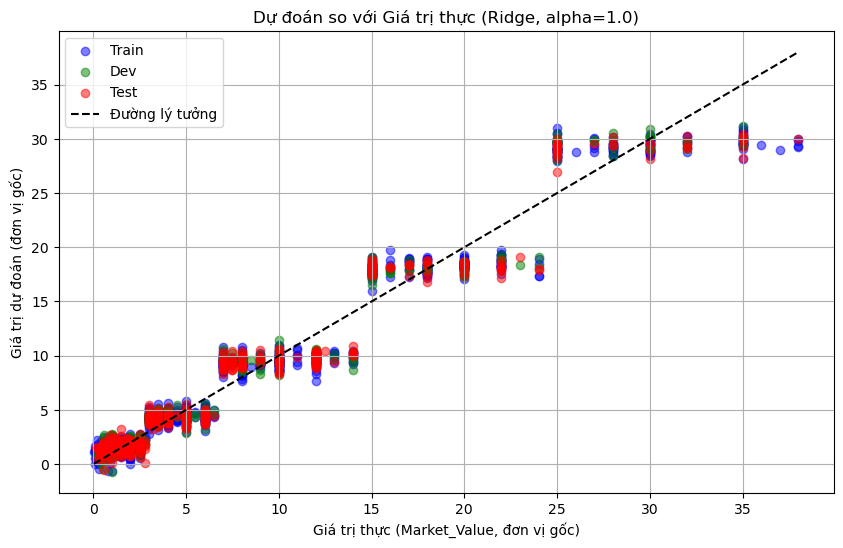

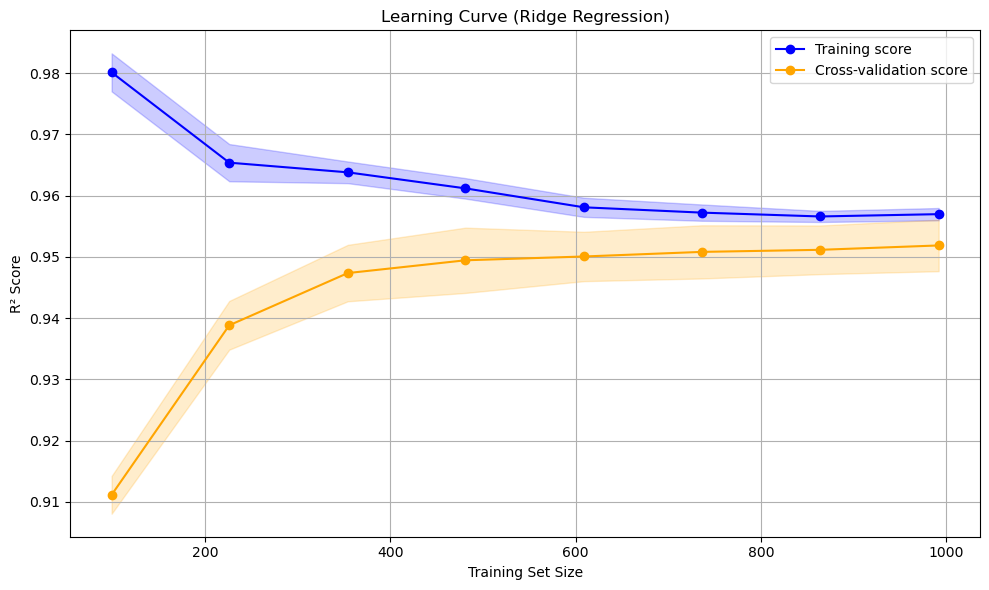

In [164]:
# IQR
X_clean_iqr, y_clean_iqr = remove_outliers_iqr(X, y)

# Chia lại tập dữ liệu 
X_train, X_temp, y_train, y_temp = train_test_split(X_clean_iqr, y_clean_iqr, test_size= 0.4, random_state= 32)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size= 0.5, random_state= 32)

# Chuẩn hóa dữ liệu 
X_scaler = StandardScaler()
y_scaler = StandardScaler()

# Chuẩn hóa X
X_train_scaled, X_dev_scaled, X_test_scaled = Standard_X(X_scaler, X_train, X_dev, X_test)
y_train_scaled, y_dev_scaled, y_test_scaled = Standard_y(y_scaler, y_train, y_dev, y_test)

# 3. Tìm tham số tối ưu bằng GridSearchCV
ridge = Ridge()

param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_scaled, y_train_scaled)

# Lấy mô hình tốt nhất
best_model_Ridge_IQR = grid_search.best_estimator_
print(f"Tham số tối ưu: alpha = {grid_search.best_params_['alpha']}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")

# 4. Dự đoán
y_train_pred_scaled, y_dev_pred_scaled, y_test_pred_scaled = predict_func(best_model_Ridge_IQR, X_train_scaled, X_dev_scaled, X_test_scaled)


# Chuyển dự đoán và giá trị thực về đơn vị gốc
y_train_pred = (y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel())
y_dev_pred   = (y_scaler.inverse_transform(y_dev_pred_scaled.reshape(-1, 1)).ravel())
y_test_pred  = (y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel())

y_train_orig = (y_train.values)
y_dev_orig   = (y_dev.values)
y_test_orig  = (y_test.values)


# 5. Đánh giá mô hình

train_mse_lr_iqr, dev_mse_lr_iqr, test_mse_lr_iqr, train_r2_lr_iqr, dev_r2_lr_iqr, test_r2_lr_iqr, train_mae_lr_iqr, dev_mae_lr_iqr, test_mae_lr_iqr = evaluate(y_train_pred, y_train_orig, y_dev_pred, y_dev_orig, y_test_pred, y_test_orig)


# In kết quả
print("\nKết quả đánh giá mô hình Ridge với alpha tối ưu (IQR):")
print(f"Train MSE: {train_mse_lr_iqr:.4f}, Train R2: {train_r2_lr_iqr:.4f}, Train MAE : {train_mae_lr_iqr:.4f}")
print(f"Dev MSE: {dev_mse_lr_iqr:.4f}, Dev R2: {dev_r2_lr_iqr:.4f}, Dev MAE : {dev_mae_lr_iqr:.4f}")
print(f"Test MSE: {test_mse_lr_iqr:.4f}, Test R2: {test_r2_lr_iqr:.4f}, Test MAE : {test_mae_lr_iqr:.4f}")
'''
# In hệ số đặc trưng
print("\nHệ số đặc trưng (Feature Coefficients):")
for feature, coef in zip(X.columns, best_model.coef_):
    print(f"{feature}: {coef:.4f}")
'''
# 6. Vẽ biểu đồ dự đoán so với giá trị thực
plt.figure(figsize=(10, 6))
plt.scatter(y_train_orig, y_train_pred, color='blue', label='Train', alpha=0.5)
plt.scatter(y_dev_orig, y_dev_pred, color='green', label='Dev', alpha=0.5)
plt.scatter(y_test_orig, y_test_pred, color='red', label='Test', alpha=0.5)
plt.plot([y_train_orig.min(), y_train_orig.max()], [y_train_orig.min(), y_train_orig.max()], color='black', linestyle='--', label='Đường lý tưởng')
plt.xlabel('Giá trị thực (Market_Value, đơn vị gốc)')
plt.ylabel('Giá trị dự đoán (đơn vị gốc)')
plt.title(f'Dự đoán so với Giá trị thực (Ridge, alpha={grid_search.best_params_["alpha"]})')
plt.legend()
plt.grid(True)
#plt.savefig('ridge_prediction_vs_actual_corrected_811.png')
plt.show()

from sklearn.model_selection import learning_curve

# Vẽ Learning Curve
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=best_model_Ridge_IQR,
    X=X_train_scaled,
    y=y_train_scaled,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

# Tính trung bình và độ lệch chuẩn
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std  = np.std(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)
valid_scores_std  = np.std(valid_scores, axis=1)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')

plt.plot(train_sizes, valid_scores_mean, 'o-', color='orange', label='Cross-validation score')
plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std,
                 valid_scores_mean + valid_scores_std, alpha=0.2, color='orange')

plt.title('Learning Curve (Ridge Regression)')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


- Training score (đường màu xanh): rất cao, dao động từ khoảng 0.97 → 0.955.

- Cross-validation score (đường màu cam): bắt đầu từ 0.91, tăng dần và tiệm cận 0.949.
=>  Khoảng cách giữa hai đường thu hẹp dần khi tăng số lượng dữ liệu huấn luyện, là tín hiệu tốt.

- Validation score tiếp tục tăng khi dữ liệu train tăng → mô hình còn có thể cải thiện nếu được huấn luyện với nhiều dữ liệu hơn.

- Training score giảm nhẹ → phản ánh rằng mô hình tổng quát hóa tốt hơn, không "học vẹt".

### Ridge with Wimsorize 

Tham số tối ưu: alpha = 0.1
Best CV MSE (scaled): 0.0285

Kết quả đánh giá mô hình Ridge với alpha tối ưu (Winsorize):
Train MSE: 3.9805, Train R2: 0.9778, Train MAE : 1.4630
Dev MSE: 5.9516, Dev R2: 0.9700, Dev MAE : 1.7608
Test MSE: 4.7791, Test R2: 0.9722, Test MAE : 1.6144


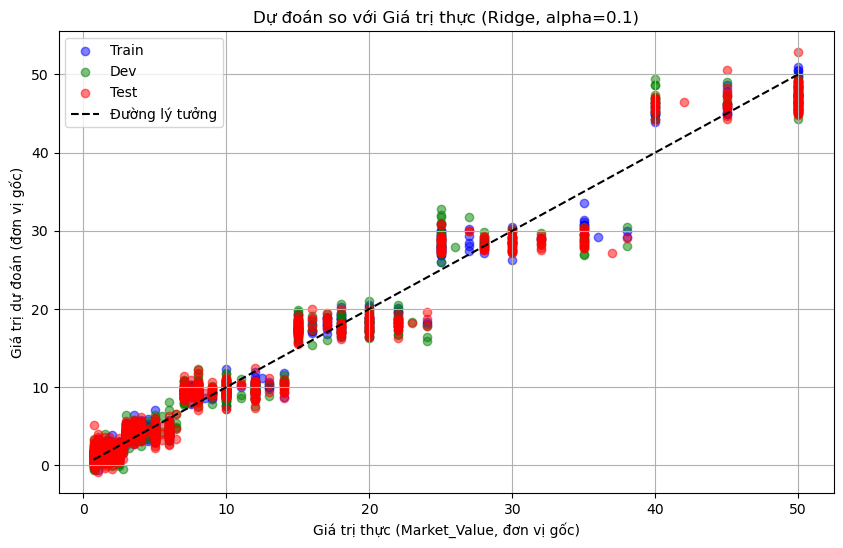

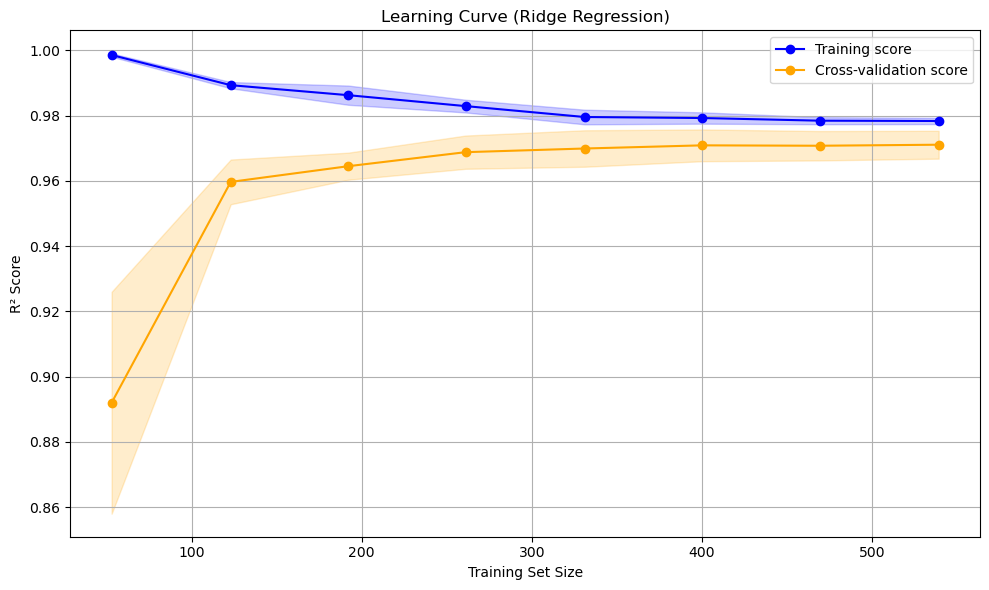

In [165]:
# Winsorize 
X_clean_win = X
y_clean_win = winsorize_data(y)

# 1. Chia dữ liệu: 80% train, 10% dev, 10% test
X_temp, X_test, y_temp, y_test = train_test_split(X_clean_win, y_clean_win, test_size=0.4, random_state=32)
X_train, X_dev, y_train, y_dev = train_test_split(X_temp, y_temp, test_size=0.5, random_state=32)

# 2. Chuẩn hóa dữ liệu
X_scaler = StandardScaler()
y_scaler = StandardScaler()

# Chuẩn hóa X
X_train_scaled, X_dev_scaled, X_test_scaled = Standard_X(X_scaler, X_train, X_dev, X_test)
y_train_scaled, y_dev_scaled, y_test_scaled = Standard_y(y_scaler, y_train, y_dev, y_test)

# 3. Tìm tham số tối ưu bằng GridSearchCV
ridge = Ridge()
param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_scaled, y_train_scaled)

# Lấy mô hình tốt nhất
best_model_Ridge_WIN = grid_search.best_estimator_
print(f"Tham số tối ưu: alpha = {grid_search.best_params_['alpha']}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")

# 4. Dự đoán
y_train_pred_scaled, y_dev_pred_scaled, y_test_pred_scaled = predict_func(best_model_Ridge_WIN, X_train_scaled, X_dev_scaled, X_test_scaled)


# Chuyển dự đoán và giá trị thực về đơn vị gốc
y_train_pred = (y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel())
y_dev_pred   = (y_scaler.inverse_transform(y_dev_pred_scaled.reshape(-1, 1)).ravel())
y_test_pred  = (y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel())

y_train_orig = (y_train.values)
y_dev_orig   = (y_dev.values)
y_test_orig  = (y_test.values)

# 5. Đánh giá mô hình
train_mse_lr_win, dev_mse_lr_win, test_mse_lr_win, train_r2_lr_win, dev_r2_lr_win, test_r2_lr_win, train_mae_lr_win, dev_mae_lr_win, test_mae_lr_win = evaluate(y_train_pred, y_train_orig, y_dev_pred, y_dev_orig, y_test_pred, y_test_orig)


# In kết quả
print("\nKết quả đánh giá mô hình Ridge với alpha tối ưu (Winsorize):")
print(f"Train MSE: {train_mse_lr_win:.4f}, Train R2: {train_r2_lr_win:.4f}, Train MAE : {train_mae_lr_win:.4f}")
print(f"Dev MSE: {dev_mse_lr_win:.4f}, Dev R2: {dev_r2_lr_win:.4f}, Dev MAE : {dev_mae_lr_win:.4f}")
print(f"Test MSE: {test_mse_lr_win:.4f}, Test R2: {test_r2_lr_win:.4f}, Test MAE : {test_mae_lr_win:.4f}")

# 6. Vẽ biểu đồ dự đoán so với giá trị thực
plt.figure(figsize=(10, 6))
plt.scatter(y_train_orig, y_train_pred, color='blue', label='Train', alpha=0.5)
plt.scatter(y_dev_orig, y_dev_pred, color='green', label='Dev', alpha=0.5)
plt.scatter(y_test_orig, y_test_pred, color='red', label='Test', alpha=0.5)
plt.plot([y_train_orig.min(), y_train_orig.max()], [y_train_orig.min(), y_train_orig.max()], color='black', linestyle='--', label='Đường lý tưởng')
plt.xlabel('Giá trị thực (Market_Value, đơn vị gốc)')
plt.ylabel('Giá trị dự đoán (đơn vị gốc)')
plt.title(f'Dự đoán so với Giá trị thực (Ridge, alpha={grid_search.best_params_["alpha"]})')
plt.legend()
plt.grid(True)
plt.show()

from sklearn.model_selection import learning_curve

# Vẽ Learning Curve
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=best_model_Ridge_WIN,
    X=X_train_scaled,
    y=y_train_scaled,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

# Tính trung bình và độ lệch chuẩn
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std  = np.std(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)
valid_scores_std  = np.std(valid_scores, axis=1)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')

plt.plot(train_sizes, valid_scores_mean, 'o-', color='orange', label='Cross-validation score')
plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std,
                 valid_scores_mean + valid_scores_std, alpha=0.2, color='orange')

plt.title('Learning Curve (Ridge Regression)')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()



## SVM
- Dữ liệu cần chuẩn hóa (Scaling)
- Không chứa Outlier mạnh 

In [188]:
data_svm = data_encoded.copy()

X = data_svm.drop(columns= ['Market_Value'])
y = data_svm['Market_Value']

### SVM Original 

In [189]:
from sklearn.svm import SVR

# Chia lại tập dữ liệu 
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size= 0.4, random_state= 32)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size= 0.5, random_state= 32)

# Chuẩn hóa dữ liệu 
X_scaler = StandardScaler()
y_scaler = StandardScaler()

# Chuẩn hóa X
X_train_scaled, X_dev_scaled, X_test_scaled = Standard_X(X_scaler, X_train, X_dev, X_test)
y_train_scaled, y_dev_scaled, y_test_scaled = Standard_y(y_scaler, y_train, y_dev, y_test)



# 3. Tìm tham số tối ưu bằng GridSearchCV
svr = SVR()

# Train
model = svr.fit(X_train_scaled, y_train_scaled)

# Dự đoán 
y_train_pred_scaled, y_dev_pred_scaled, y_test_pred_scaled = predict_func(model, X_train_scaled, X_dev_scaled, X_test_scaled)


# # Chuyển dự đoán và giá trị thực về đơn vị gốc
y_train_pred = (y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel())
y_dev_pred   = (y_scaler.inverse_transform(y_dev_pred_scaled.reshape(-1, 1)).ravel())
y_test_pred  = (y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel())

y_train_orig = (y_train.values)
y_dev_orig   = (y_dev.values)
y_test_orig  = (y_test.values)

# 5. Đánh giá mô hình
train_mse_svm_orig, dev_mse_svm_orig, test_mse_svm_orig, train_r2_svm_orig, dev_r2_svm_orig, test_r2_svm_orig, train_mae_svm_orig, dev_mae_svm_orig, test_mae_svm_orig = evaluate(y_train_pred, y_train_orig, y_dev_pred, y_dev_orig, y_test_pred, y_test_orig)


# In kết quả
print("\nKết quả đánh giá mô hình SVR Original:")
print(f"Train MSE: {train_mse_svm_orig:.4f}, Train R2: {train_r2_svm_orig:.4f}, Train MAE : {train_mae_svm_orig:.4f}")
print(f"Dev MSE: {dev_mse_svm_orig:.4f}, Dev R2: {dev_r2_svm_orig:.4f}, Dev MAE : {dev_mae_svm_orig:.4f}")
print(f"Test MSE: {test_mse_svm_orig:.4f}, Test R2: {test_r2_svm_orig:.4f}, Test MAE : {dev_mae_svm_orig}")



Kết quả đánh giá mô hình SVR Original:
Train MSE: 81.0777, Train R2: 0.7914, Train MAE : 2.5869
Dev MSE: 43.7004, Dev R2: 0.7929, Dev MAE : 3.0223
Test MSE: 130.2386, Test R2: 0.6774, Test MAE : 3.0223266939278


### SVM with IQR 

Tham số tối ưu: {'C': 10, 'epsilon': 0.01, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV MSE (scaled): 0.1133

Kết quả đánh giá mô hình SVR với alpha tối ưu (IQR):
Train MSE: 0.0123, Train R2: 0.9999, Train MAE : 0.0925
Dev MSE: 8.0524, Dev R2: 0.8873, Dev MAE : 2.0550
Test MSE: 7.9211, Test R2: 0.8844, Test MAE : 1.9919


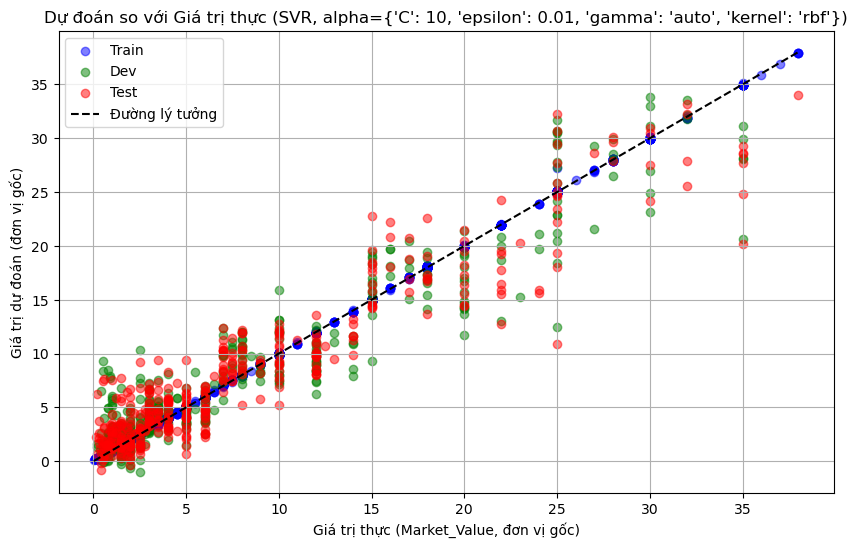

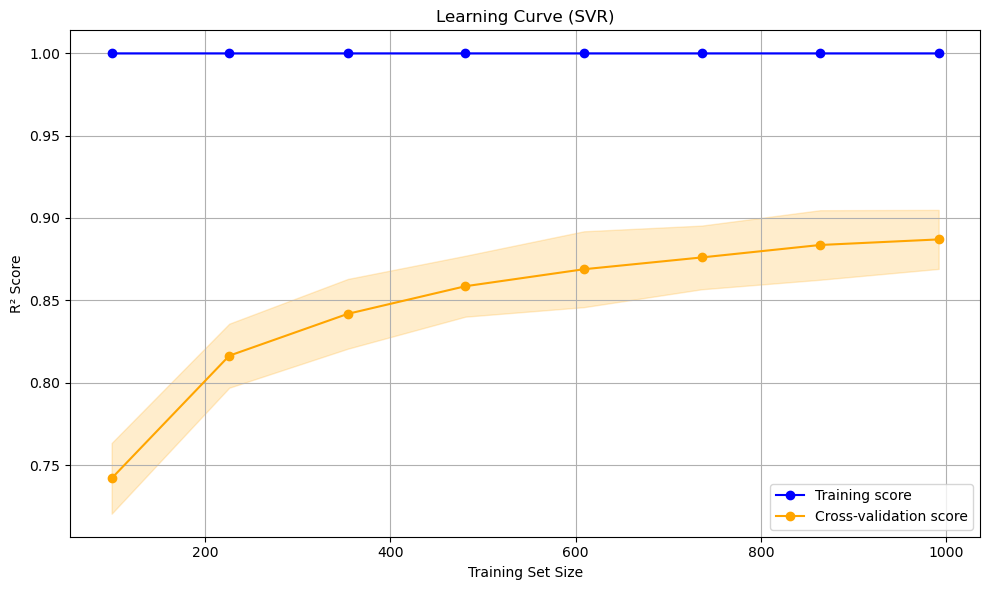

In [168]:

X_clean_iqr, y_clean_iqr = remove_outliers_iqr(X, y)

# Chia lại tập dữ liệu
X_train, X_temp, y_train, y_temp = train_test_split(X_clean_iqr, y_clean_iqr, test_size=0.4, random_state=32)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=32)

#. Chuẩn hóa dữ liệu
X_scaler = StandardScaler()
y_scaler = StandardScaler()

# Chuẩn hóa X
X_train_scaled, X_dev_scaled, X_test_scaled = Standard_X(X_scaler, X_train, X_dev, X_test)
y_train_scaled, y_dev_scaled, y_test_scaled = Standard_y(y_scaler, y_train, y_dev, y_test)


# Huấn luyện model ban đầu 
svr = SVR()
param_grid = {
    'C': [1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}


grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_scaled, y_train_scaled)

# Lấy mô hình tốt nhất
best_model_SVM_IQR = grid_search.best_estimator_
print(f"Tham số tối ưu: {grid_search.best_params_}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")

# 4. Dự đoán
y_train_pred_scaled, y_dev_pred_scaled, y_test_pred_scaled = predict_func(best_model_SVM_IQR, X_train_scaled, X_dev_scaled, X_test_scaled)


# Chuyển về đơn vị gốc
y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()
y_dev_pred = y_scaler.inverse_transform(y_dev_pred_scaled.reshape(-1, 1)).ravel()
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

y_train_orig = (y_train.values)
y_dev_orig   = (y_dev.values)
y_test_orig  = (y_test.values)


# 5. Đánh giá mô hình
train_mse_svm_iqr, dev_mse_svm_iqr, test_mse_svm_iqr, train_r2_svm_iqr, dev_r2_svm_iqr, test_r2_svm_iqr, train_mae_svm_iqr, dev_mae_svm_iqr, test_mae_svm_iqr = evaluate(y_train_pred, y_train_orig, y_dev_pred, y_dev_orig, y_test_pred, y_test_orig)


# In kết quả
print("\nKết quả đánh giá mô hình SVR với alpha tối ưu (IQR):")
print(f"Train MSE: {train_mse_svm_iqr:.4f}, Train R2: {train_r2_svm_iqr:.4f}, Train MAE : {train_mae_svm_iqr:.4f}")
print(f"Dev MSE: {dev_mse_svm_iqr:.4f}, Dev R2: {dev_r2_svm_iqr:.4f}, Dev MAE : {dev_mae_svm_iqr:.4f}")
print(f"Test MSE: {test_mse_svm_iqr:.4f}, Test R2: {test_r2_svm_iqr:.4f}, Test MAE : {test_mae_svm_iqr:.4f}")

# 6. Vẽ biểu đồ dự đoán so với giá trị thực
plt.figure(figsize=(10, 6))
plt.scatter(y_train_orig, y_train_pred, color='blue', label='Train', alpha=0.5)
plt.scatter(y_dev_orig, y_dev_pred, color='green', label='Dev', alpha=0.5)
plt.scatter(y_test_orig, y_test_pred, color='red', label='Test', alpha=0.5)
plt.plot([y_train_orig.min(), y_train_orig.max()], [y_train_orig.min(), y_train_orig.max()], color='black', linestyle='--', label='Đường lý tưởng')
plt.xlabel('Giá trị thực (Market_Value, đơn vị gốc)')
plt.ylabel('Giá trị dự đoán (đơn vị gốc)')
plt.title(f'Dự đoán so với Giá trị thực (SVR, alpha={grid_search.best_params_})')
plt.legend()
plt.grid(True)
plt.show()

# Vẽ Learning Curve
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=best_model_SVM_IQR,
    X=X_train_scaled,
    y=y_train_scaled,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

# Tính trung bình và độ lệch chuẩn
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std  = np.std(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)
valid_scores_std  = np.std(valid_scores, axis=1)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')

plt.plot(train_sizes, valid_scores_mean, 'o-', color='orange', label='Cross-validation score')
plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std,
                 valid_scores_mean + valid_scores_std, alpha=0.2, color='orange')

plt.title('Learning Curve (SVR)')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


### SVM with Winsorize 

Tham số tối ưu: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV MSE (scaled): 0.1139

Kết quả đánh giá mô hình SVR với alpha tối ưu (Winsorize):
Train MSE: 0.0176, Train R2: 0.9999, Train MAE : 0.1314
Dev MSE: 22.0747, Dev R2: 0.8886, Dev MAE : 3.0557
Test MSE: 18.3699, Test R2: 0.8933, Test MAE : 2.7932


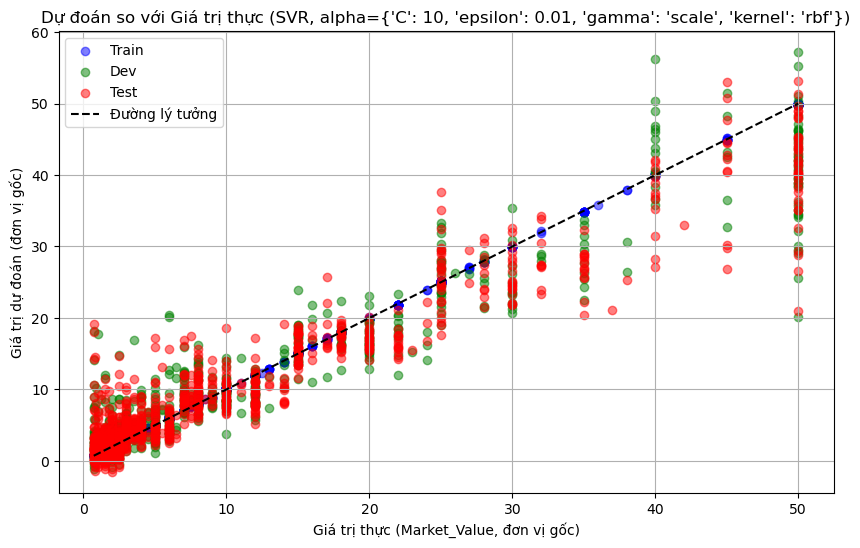

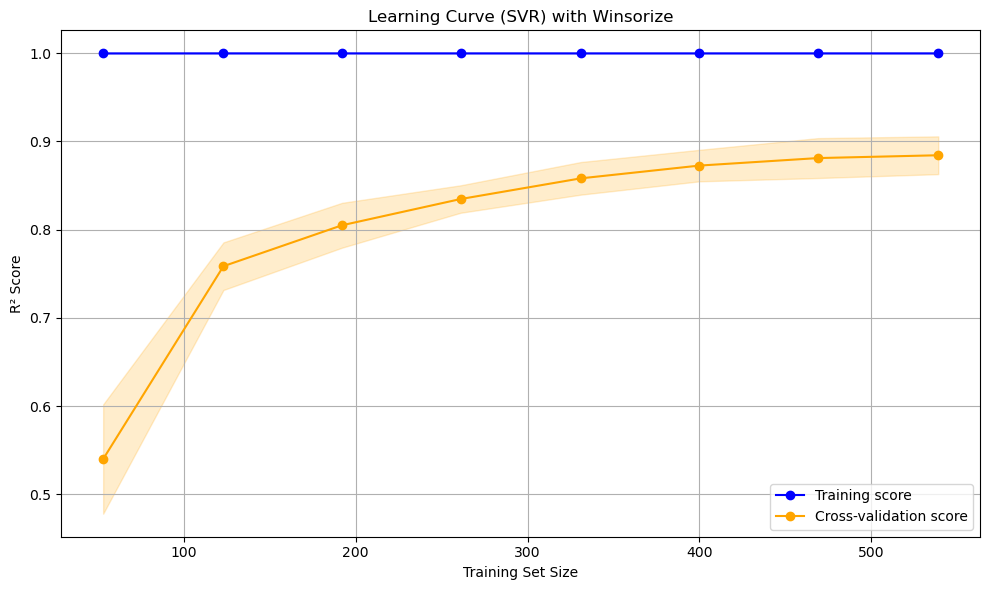

In [169]:
# Winsorize 
X_clean_win = X
y_clean_win = winsorize_data(y)

# 1. Chia dữ liệu
X_temp, X_test, y_temp, y_test = train_test_split(X_clean_win, y_clean_win, test_size=0.4, random_state=32)
X_train, X_dev, y_train, y_dev = train_test_split(X_temp, y_temp, test_size=0.5, random_state=32)

#. Chuẩn hóa dữ liệu
X_scaler = StandardScaler()
y_scaler = StandardScaler()

# Chuẩn hóa X, y
X_train_scaled, X_dev_scaled, X_test_scaled = Standard_X(X_scaler, X_train, X_dev, X_test)
y_train_scaled, y_dev_scaled, y_test_scaled = Standard_y(y_scaler, y_train, y_dev, y_test)


# Huấn luyện model ban đầu 
svr = SVR()
param_grid = {
    'C': [1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}


grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_scaled, y_train_scaled)

# Lấy mô hình tốt nhất
best_model_SVM_WIN = grid_search.best_estimator_
print(f"Tham số tối ưu: {grid_search.best_params_}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")

# Dự đoán
y_train_pred_scaled, y_dev_pred_scaled, y_test_pred_scaled = predict_func(best_model_SVM_WIN, X_train_scaled, X_dev_scaled, X_test_scaled)

# Chuyển về đơn vị gốc
y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()
y_dev_pred = y_scaler.inverse_transform(y_dev_pred_scaled.reshape(-1, 1)).ravel()
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

y_train_orig = (y_train.values)
y_dev_orig   = (y_dev.values)
y_test_orig  = (y_test.values)

# 5. Đánh giá mô hình

train_mse_svm_win, dev_mse_svm_win, test_mse_svm_win, train_r2_svm_win, dev_r2_svm_win, test_r2_svm_win, train_mae_svm_win, dev_mae_svm_win, test_mae_svm_win = evaluate(y_train_pred, y_train_orig, y_dev_pred, y_dev_orig, y_test_pred, y_test_orig)




# In kết quả
print("\nKết quả đánh giá mô hình SVR với alpha tối ưu (Winsorize):")
print(f"Train MSE: {train_mse_svm_win:.4f}, Train R2: {train_r2_svm_win:.4f}, Train MAE : {train_mae_svm_win:.4f}")
print(f"Dev MSE: {dev_mse_svm_win:.4f}, Dev R2: {dev_r2_svm_win:.4f}, Dev MAE : {dev_mae_svm_win:.4f}")
print(f"Test MSE: {test_mse_svm_win:.4f}, Test R2: {test_r2_svm_win:.4f}, Test MAE : {test_mae_svm_win:.4f}")

# 6. Vẽ biểu đồ dự đoán so với giá trị thực
plt.figure(figsize=(10, 6))
plt.scatter(y_train_orig, y_train_pred, color='blue', label='Train', alpha=0.5)
plt.scatter(y_dev_orig, y_dev_pred, color='green', label='Dev', alpha=0.5)
plt.scatter(y_test_orig, y_test_pred, color='red', label='Test', alpha=0.5)
plt.plot([y_train_orig.min(), y_train_orig.max()], [y_train_orig.min(), y_train_orig.max()], color='black', linestyle='--', label='Đường lý tưởng')
plt.xlabel('Giá trị thực (Market_Value, đơn vị gốc)')
plt.ylabel('Giá trị dự đoán (đơn vị gốc)')
plt.title(f'Dự đoán so với Giá trị thực (SVR, alpha={grid_search.best_params_})')
plt.legend()
plt.grid(True)
plt.show()

# Vẽ Learning Curve
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=best_model_SVM_WIN,
    X=X_train_scaled,
    y=y_train_scaled,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

# Tính trung bình và độ lệch chuẩn
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std  = np.std(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)
valid_scores_std  = np.std(valid_scores, axis=1)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')

plt.plot(train_sizes, valid_scores_mean, 'o-', color='orange', label='Cross-validation score')
plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std,
                 valid_scores_mean + valid_scores_std, alpha=0.2, color='orange')

plt.title('Learning Curve (SVR) with Winsorize')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


## Random Forest 
- Cần trích xuất đặc trưng (giảm chiều dữ liệu), bởi vì : 
    + Một số đặc trưng không liên quan có thể làm giảm hiệu xuất
    + Tăng độ phức tạp của cây => Overfitting 

In [209]:
data_rf = data_encoded.copy()

X = data_rf.drop(columns = 'Market_Value')
y = data_rf['Market_Value']

### Random Forest Original 

In [210]:
from sklearn.ensemble import RandomForestRegressor


# Chia lại tập dữ liệu 
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size= 0.4, random_state= 32)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size= 0.5, random_state= 32)

# Huấn luyện mô hình ban đầu 
rf = RandomForestRegressor(random_state= 32)

# Train
model = rf.fit(X_train, y_train)

# 6. Dự đoán
y_train_pred, y_dev_pred, y_test_pred = predict_func(model, X_train, X_dev, X_test)

train_mse_rf_orig, dev_mse_rf_orig, test_mse_rf_orig, train_r2_rf_orig, dev_r2_rf_orig, test_r2_rf_orig, train_mae_rf_orig, dev_mae_rf_orig, test_mae_rf_orig = evaluate(y_train_pred, y_train, y_dev_pred, y_dev, y_test_pred, y_test)

# In kết quả
print("\nKết quả đánh giá mô hình Random Forest Original:")
print(f"Train MSE: {train_mse_rf_orig:.4f}, Train R2: {train_r2_rf_orig:.4f}, Train MAE : {train_mae_rf_orig:.4f}")
print(f"Dev MSE: {dev_mse_rf_orig:.4f}, Dev R2: {dev_r2_rf_orig:.4f}, Dev MAE : {dev_mae_rf_orig:.4f}")
print(f"Test MSE: {test_mse_rf_orig:.4f}, Test R2: {test_r2_rf_orig:.4f}, Test MAE : {test_mae_rf_orig:.4f}")






Kết quả đánh giá mô hình Random Forest Original:
Train MSE: 9.4237, Train R2: 0.9758, Train MAE : 1.1304
Dev MSE: 27.7182, Dev R2: 0.8687, Dev MAE : 1.9795
Test MSE: 83.5144, Test R2: 0.7931, Test MAE : 3.0407


### Random Forest with IQR


Siêu tham số tối ưu: {'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 20, 'n_estimators': 100}
Best CV MSE (log scale): 4.2766

Độ quan trọng của đặc trưng (Feature Importance):
                     Feature  Importance
46     Club_Group_Upper Tier    0.609632
43  Club_Group_Mid-High Tier    0.278992
44       Club_Group_Mid-Tier    0.084975
42     Club_Group_Lower Tier    0.013496
7                        PS%    0.001260
6                    Assists    0.001062
4                       Mins    0.000990
9                     Rating    0.000792
3                    Sub_app    0.000721
20                    TotClr    0.000642
1                     Height    0.000631
26                    TotInt    0.000530
34             League_Ligue1    0.000499
21                    Fouled    0.000474
22                     Fouls    0.000427
31                      Card    0.000427
0                        Age    0.000403
2                Months_left    0.000389
32                League_EPL  

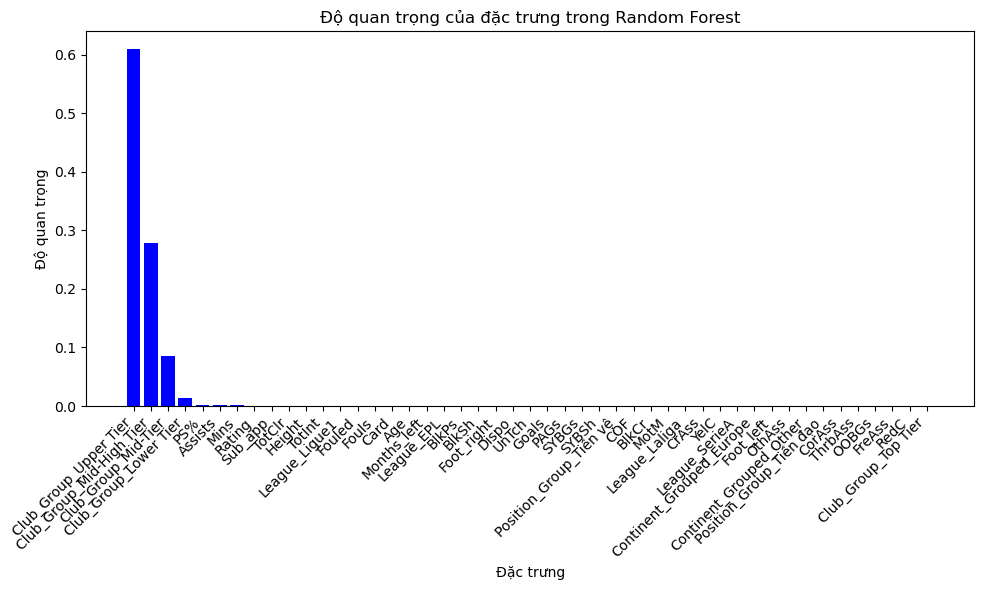

In [211]:
X_clean_iqr, y_clean_iqr = remove_outliers_iqr(X, y)

# Chia lại tập dữ liệu 
X_train, X_temp, y_train, y_temp = train_test_split(X_clean_iqr, y_clean_iqr, test_size= 0.4, random_state= 32)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size= 0.5, random_state= 32)

rf = RandomForestRegressor(random_state=32)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 8]
}
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Lấy mô hình tốt nhất
best_model_RF_IQR = grid_search.best_estimator_
print(f"\nSiêu tham số tối ưu: {grid_search.best_params_}")
print(f"Best CV MSE (log scale): {-grid_search.best_score_:.4f}")
# 3. Tính và hiển thị Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model_RF_IQR.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nĐộ quan trọng của đặc trưng (Feature Importance):")
print(feature_importance)

# Vẽ biểu đồ Feature Importance
plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'], color = 'blue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Đặc trưng')
plt.ylabel('Độ quan trọng')
plt.title('Độ quan trọng của đặc trưng trong Random Forest')
plt.tight_layout()
plt.show()


Đặc trưng được chọn: ['Age', 'Height', 'Months_left', 'Sub_app', 'Mins', 'Assists', 'PS%', 'Rating', 'BlkSh', 'BlkPs', 'TotClr', 'Fouled', 'Fouls', 'TotInt', 'UnTch', 'Dispo', 'Card', 'League_EPL', 'League_Ligue1', 'Foot_right', 'Club_Group_Lower Tier', 'Club_Group_Mid-High Tier', 'Club_Group_Mid-Tier', 'Club_Group_Upper Tier']
Số đặc trưng ban đầu: 47
Số đặc trưng sau khi chọn: 24

Kết quả đánh giá mô hình Random Forest sau khi chọn đặc trưng (IQR):
Train MSE: 3.0453, Train R2: 0.9638, Train MAE : 1.3003
Dev MSE: 3.5468, Dev R2: 0.9504, Dev MAE : 1.3935
Test MSE: 3.6352, Test R2: 0.9470, Test MAE : 1.4084


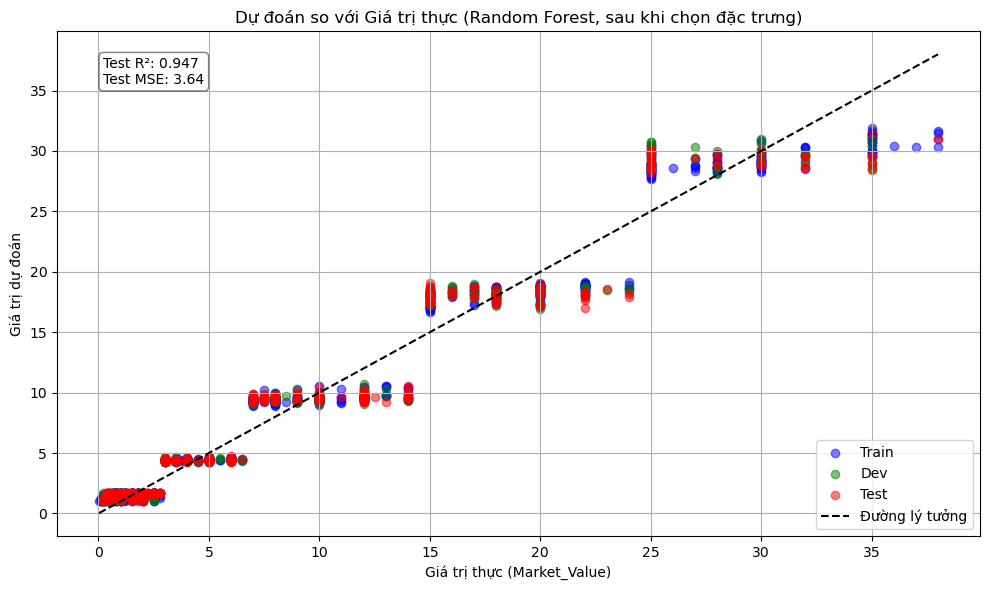

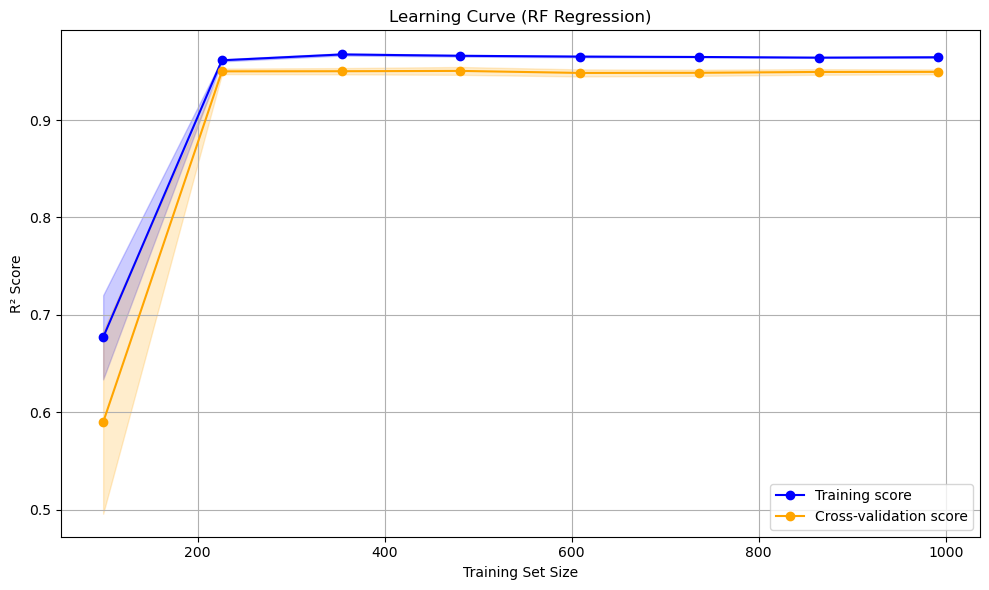

In [212]:
from sklearn.feature_selection import SelectFromModel
# 4. Lựa chọn đặc trưng quan trọng
selector = SelectFromModel(best_model_RF_IQR, threshold='median')  # Chọn đặc trưng có importance trên trung vị mean 
selector.fit(X_train, y_train)

X_train_selected = selector.transform(X_train)
X_dev_selected = selector.transform(X_dev)
X_test_selected = selector.transform(X_test)

# Lấy danh sách đặc trưng được chọn
selected_features = X.columns[selector.get_support()].tolist()
print(f"\nĐặc trưng được chọn: {selected_features}")
print(f"Số đặc trưng ban đầu: {X.shape[1]}")
print(f"Số đặc trưng sau khi chọn: {len(selected_features)}")

# 5. Huấn luyện lại mô hình với đặc trưng được chọn
rf_selected = RandomForestRegressor(**grid_search.best_params_, random_state=32)
rf_selected.fit(X_train_selected, y_train)

# 6. Dự đoán
'''
y_train_pred = rf_selected.predict(X_train_selected)
y_dev_pred = rf_selected.predict(X_dev_selected)
y_test_pred = rf_selected.predict(X_test_selected)
'''

y_train_pred, y_dev_pred, y_test_pred = predict_func(rf_selected, X_train_selected, X_dev_selected, X_test_selected)


# 7. Đánh giá mô hình
train_mse_rf_iqr, dev_mse_rf_iqr, test_mse_rf_iqr, train_r2_rf_iqr, dev_r2_rf_iqr, test_r2_rf_iqr, train_mae_rf_iqr, dev_mae_rf_iqr, test_mae_rf_iqr = evaluate(y_train_pred, y_train, y_dev_pred, y_dev, y_test_pred, y_test)

# In kết quả
print("\nKết quả đánh giá mô hình Random Forest sau khi chọn đặc trưng (IQR):")
print(f"Train MSE: {train_mse_rf_iqr:.4f}, Train R2: {train_r2_rf_iqr:.4f}, Train MAE : {train_mae_rf_iqr:.4f}")
print(f"Dev MSE: {dev_mse_rf_iqr:.4f}, Dev R2: {dev_r2_rf_iqr:.4f}, Dev MAE : {dev_mae_rf_iqr:.4f}")
print(f"Test MSE: {test_mse_rf_iqr:.4f}, Test R2: {test_r2_rf_iqr:.4f}, Test MAE : {test_mae_rf_iqr:.4f}")

# 8. Vẽ biểu đồ dự đoán so với giá trị thực
# Tổng hợp giá trị thực để lấy min/max chung
y_all = np.concatenate([y_train, y_dev, y_test])

plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.5)
plt.scatter(y_dev, y_dev_pred, color='green', label='Dev', alpha=0.5)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.5)

# Đường lý tưởng
plt.plot([y_all.min(), y_all.max()], [y_all.min(), y_all.max()], color='black', linestyle='--', label='Đường lý tưởng')

# Label và title
plt.xlabel('Giá trị thực (Market_Value)')
plt.ylabel('Giá trị dự đoán')
plt.title('Dự đoán so với Giá trị thực (Random Forest, sau khi chọn đặc trưng)')
plt.legend()
plt.grid(True)

# Hiển thị metric trên biểu đồ
textstr = f'Test R²: {test_r2_rf_iqr:.3f}\nTest MSE: {test_mse_rf_iqr:.2f}'
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.savefig('rf_prediction_vs_actual_selected_811.png')
plt.show()


# Vẽ Learning Curve
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=best_model_RF_IQR,
    X=X_train_selected,
    y=y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

# Tính trung bình và độ lệch chuẩn
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std  = np.std(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)
valid_scores_std  = np.std(valid_scores, axis=1)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')

plt.plot(train_sizes, valid_scores_mean, 'o-', color='orange', label='Cross-validation score')
plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std,
                 valid_scores_mean + valid_scores_std, alpha=0.2, color='orange')

plt.title('Learning Curve (RF Regression)')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Random Forest with Winsorize 


Siêu tham số tối ưu: {'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 5, 'n_estimators': 50}
Best CV MSE (log scale): 5.2581

Độ quan trọng của đặc trưng (Feature Importance):
                     Feature  Importance
45       Club_Group_Top Tier    0.622040
46     Club_Group_Upper Tier    0.217741
43  Club_Group_Mid-High Tier    0.111334
44       Club_Group_Mid-Tier    0.034922
42     Club_Group_Lower Tier    0.005578
9                     Rating    0.001431
0                        Age    0.000927
21                    Fouled    0.000680
20                    TotClr    0.000508
3                    Sub_app    0.000467
6                    Assists    0.000460
17                     BlkPs    0.000449
28                     UnTch    0.000349
26                    TotInt    0.000326
32                League_EPL    0.000294
29                     Dispo    0.000254
4                       Mins    0.000241
7                        PS%    0.000237
1                     Height    

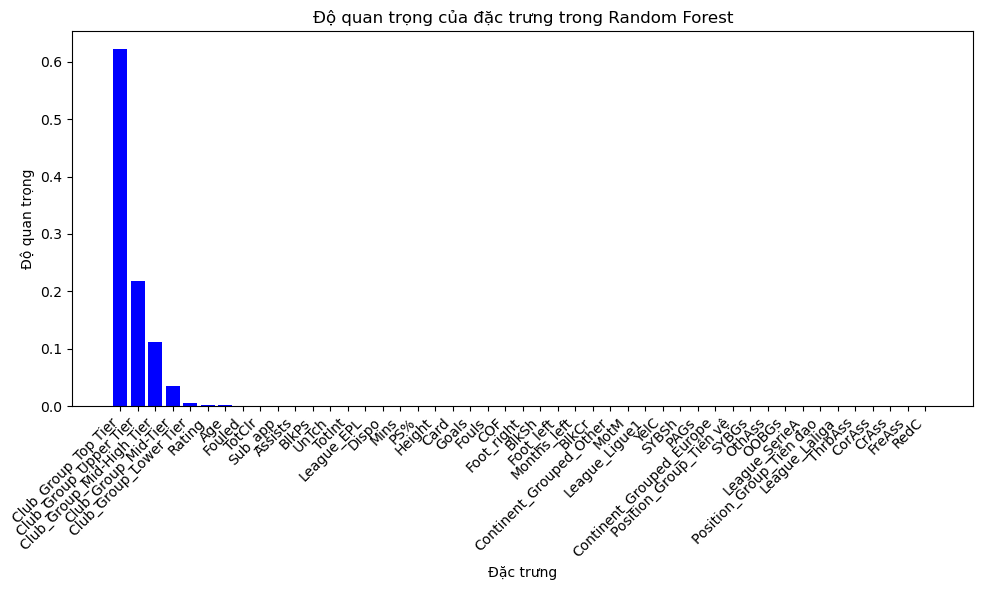

In [213]:
# Winsorize 
X_clean_win = X
y_clean_win = winsorize_data(y)


# Chia lại tập dữ liệu 
X_train, X_temp, y_train, y_temp = train_test_split(X_clean_win, y_clean_win, test_size= 0.4, random_state= 32)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size= 0.5, random_state= 32)

rf = RandomForestRegressor(random_state=32)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 8]
}


grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Lấy mô hình tốt nhất
best_model_RF_WIN = grid_search.best_estimator_
print(f"\nSiêu tham số tối ưu: {grid_search.best_params_}")
print(f"Best CV MSE (log scale): {-grid_search.best_score_:.4f}")
# 3. Tính và hiển thị Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model_RF_WIN.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nĐộ quan trọng của đặc trưng (Feature Importance):")
print(feature_importance)

# Vẽ biểu đồ Feature Importance
plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'], color = 'blue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Đặc trưng')
plt.ylabel('Độ quan trọng')
plt.title('Độ quan trọng của đặc trưng trong Random Forest')
plt.tight_layout()
plt.show()



Đặc trưng được chọn: ['Age', 'Height', 'Sub_app', 'Mins', 'Goals', 'Assists', 'PS%', 'Rating', 'BlkPs', 'TotClr', 'Fouled', 'Fouls', 'TotInt', 'COF', 'UnTch', 'Dispo', 'Card', 'League_EPL', 'Foot_right', 'Club_Group_Lower Tier', 'Club_Group_Mid-High Tier', 'Club_Group_Mid-Tier', 'Club_Group_Top Tier', 'Club_Group_Upper Tier']
Số đặc trưng ban đầu: 47
Số đặc trưng sau khi chọn: 24

Kết quả đánh giá mô hình Random Forest sau khi chọn đặc trưng (Winsorize):
Train MSE: 3.6921, Train R2: 0.9805, Train MAE : 1.4282
Dev MSE: 3.4175, Dev R2: 0.9763, Dev MAE : 1.3416
Test MSE: 5.6721, Test R2: 0.9712, Test MAE : 1.7123


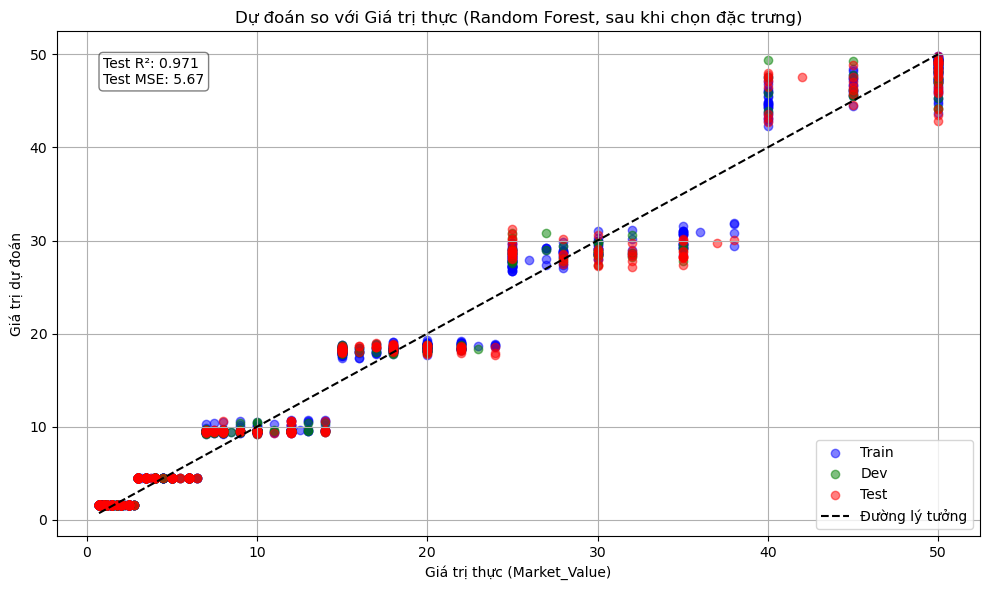

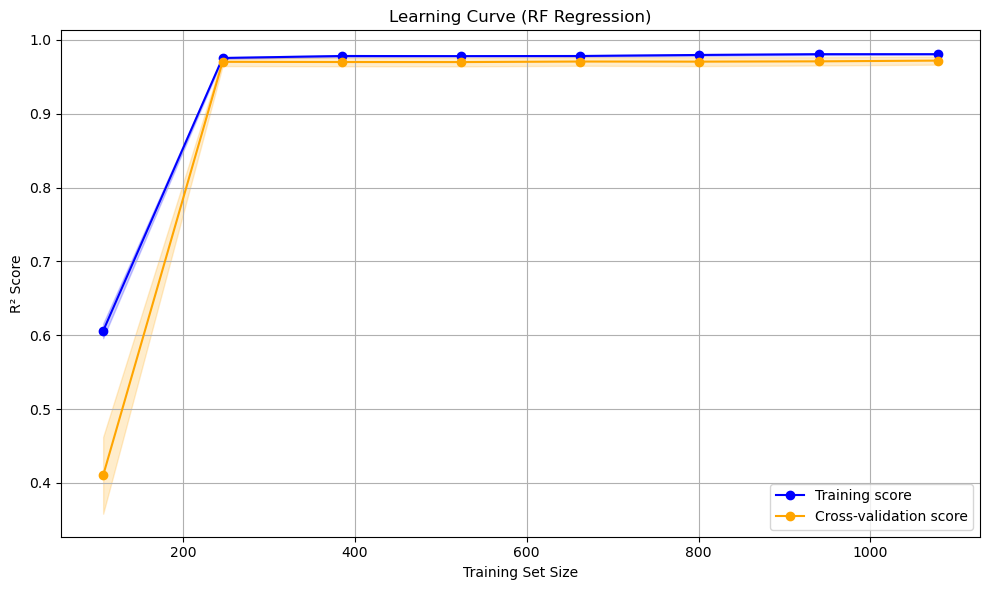

In [214]:
from sklearn.feature_selection import SelectFromModel
# 4. Lựa chọn đặc trưng quan trọng
selector = SelectFromModel(best_model_RF_WIN, threshold='median')  # Chọn đặc trưng có importance trên trung vị mean 
selector.fit(X_train, y_train)

X_train_selected = selector.transform(X_train)
X_dev_selected = selector.transform(X_dev)
X_test_selected = selector.transform(X_test)

# Lấy danh sách đặc trưng được chọn
selected_features = X.columns[selector.get_support()].tolist()
print(f"\nĐặc trưng được chọn: {selected_features}")
print(f"Số đặc trưng ban đầu: {X.shape[1]}")
print(f"Số đặc trưng sau khi chọn: {len(selected_features)}")

# 5. Huấn luyện lại mô hình với đặc trưng được chọn
rf_selected = RandomForestRegressor(**grid_search.best_params_, random_state=32)
rf_selected.fit(X_train_selected, y_train)

# 6. Dự đoán

y_train_pred, y_dev_pred, y_test_pred = predict_func(rf_selected, X_train_selected, X_dev_selected, X_test_selected)

# Chuyển dự đoán về đơn vị gốc (ngược log transform)
y_train_pred_orig = (y_train_pred)
y_dev_pred_orig = (y_dev_pred)
y_test_pred_orig = (y_test_pred)
y_train_orig = (y_train)
y_dev_orig = (y_dev)
y_test_orig = (y_test)

# 7. Đánh giá mô hình

train_mse_rf_win, dev_mse_rf_win, test_mse_rf_win, train_r2_rf_win, dev_r2_rf_win, test_r2_rf_win, train_mae_rf_win, dev_mae_rf_win, test_mae_rf_win = evaluate(y_train_pred, y_train_orig, y_dev_pred, y_dev_orig, y_test_pred, y_test_orig)

# In kết quả
print("\nKết quả đánh giá mô hình Random Forest sau khi chọn đặc trưng (Winsorize):")
print(f"Train MSE: {train_mse_rf_win:.4f}, Train R2: {train_r2_rf_win:.4f}, Train MAE : {train_mae_rf_win:.4f}")
print(f"Dev MSE: {dev_mse_rf_win:.4f}, Dev R2: {dev_r2_rf_win:.4f}, Dev MAE : {dev_mae_rf_win:.4f}")
print(f"Test MSE: {test_mse_rf_win:.4f}, Test R2: {test_r2_rf_win:.4f}, Test MAE : {test_mae_rf_win:.4f}")

# 8. Vẽ biểu đồ dự đoán so với giá trị thực
# Tổng hợp giá trị thực để lấy min/max chung
y_all = np.concatenate([y_train_orig, y_dev_orig, y_test_orig])

plt.figure(figsize=(10, 6))
plt.scatter(y_train_orig, y_train_pred_orig, color='blue', label='Train', alpha=0.5)
plt.scatter(y_dev_orig, y_dev_pred_orig, color='green', label='Dev', alpha=0.5)
plt.scatter(y_test_orig, y_test_pred_orig, color='red', label='Test', alpha=0.5)

# Đường lý tưởng
plt.plot([y_all.min(), y_all.max()], [y_all.min(), y_all.max()], color='black', linestyle='--', label='Đường lý tưởng')

# Label và title
plt.xlabel('Giá trị thực (Market_Value)')
plt.ylabel('Giá trị dự đoán')
plt.title('Dự đoán so với Giá trị thực (Random Forest, sau khi chọn đặc trưng)')
plt.legend()
plt.grid(True)

# Hiển thị metric trên biểu đồ
textstr = f'Test R²: {test_r2_rf_win:.3f}\nTest MSE: {test_mse_rf_win:.2f}'
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.savefig('rf_prediction_vs_actual_selected_811.png')
plt.show()


from sklearn.model_selection import learning_curve

# Vẽ Learning Curve
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=best_model_RF_WIN,
    X=X_train_selected,
    y=y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

# Tính trung bình và độ lệch chuẩn
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std  = np.std(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)
valid_scores_std  = np.std(valid_scores, axis=1)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')

plt.plot(train_sizes, valid_scores_mean, 'o-', color='orange', label='Cross-validation score')
plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std,
                 valid_scores_mean + valid_scores_std, alpha=0.2, color='orange')

plt.title('Learning Curve (RF Regression)')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## XGBoost 

In [227]:
data_xg = data_encoded.copy()

In [228]:
import xgboost as xgb

X = data_xg.drop(columns= 'Market_Value')
y = data_xg['Market_Value']


### XGBoost Orginal 

In [229]:
# Áp dụng log transform

# 2. Chia dữ liệu: 80% train, 10% dev, 10% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.4, random_state=32)
X_train, X_dev, y_train, y_dev = train_test_split(X_temp, y_temp, test_size=0.5, random_state=32)

model_xg = xgb.XGBRegressor(random_state=32, objective='reg:squarederror')

# Train
model_xg.fit(X_train, y_train)

# Dự đoán
y_train_pred, y_dev_pred, y_test_pred = predict_func(model_xg, X_train, X_dev, X_test)

# 8. Đánh giá

train_mse_xg_orig, dev_mse_xg_orig, test_mse_xg_orig, train_r2_xg_orig, dev_r2_xg_orig, test_r2_xg_orig, train_mae_xg_orig, dev_mae_xg_orig, test_mae_xg_orig = evaluate(y_train_pred, y_train, y_dev_pred, y_dev, y_test_pred, y_test)



print("\nKết quả đánh giá mô hình XGBoost Original :")
print(f"Train MSE: {train_mse_xg_orig:.4f}, Train R2: {train_r2_xg_orig:.4f}, Train MAE : {train_mae_xg_orig:.4f}")
print(f"Dev MSE: {dev_mse_xg_orig:.4f}, Dev R2: {dev_r2_xg_orig:.4f}, Dev MAE : {dev_mae_xg_orig:.4f}")
print(f"Test MSE: {test_mse_xg_orig:.4f}, Test R2: {test_r2_xg_orig:.4f}, Test MAE : {test_mae_xg_orig:.4f}")




Kết quả đánh giá mô hình XGBoost Original :
Train MSE: 0.0010, Train R2: 1.0000, Train MAE : 0.0218
Dev MSE: 98.9251, Dev R2: 0.7708, Dev MAE : 3.4921
Test MSE: 62.4263, Test R2: 0.7986, Test MAE : 2.5465


### XGBoost with IQR


Siêu tham số tối ưu: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV MSE (log scale): 4.4399

Đặc trưng được chọn: ['Age', 'Months_left', 'Sub_app', 'Mins', 'Goals', 'Assists', 'PS%', 'MotM', 'Rating', 'BlkSh', 'BlkCr', 'TotClr', 'Fouls', 'TotInt', 'Dispo', 'League_EPL', 'League_Laliga', 'League_Ligue1', 'Foot_right', 'Position_Group_Tiền đạo', 'Club_Group_Lower Tier', 'Club_Group_Mid-High Tier', 'Club_Group_Mid-Tier', 'Club_Group_Upper Tier']
Số đặc trưng ban đầu: 47
Số đặc trưng sau khi chọn: 24

Kết quả đánh giá mô hình XGBoost sau khi chọn đặc trưng (IQR):
Train MSE: 2.2231, Train R2: 0.9735, Train MAE : 1.1070
Dev MSE: 3.9094, Dev R2: 0.9453, Dev MAE : 1.4265
Test MSE: 3.7693, Test R2: 0.9450, Test MAE : 1.4151


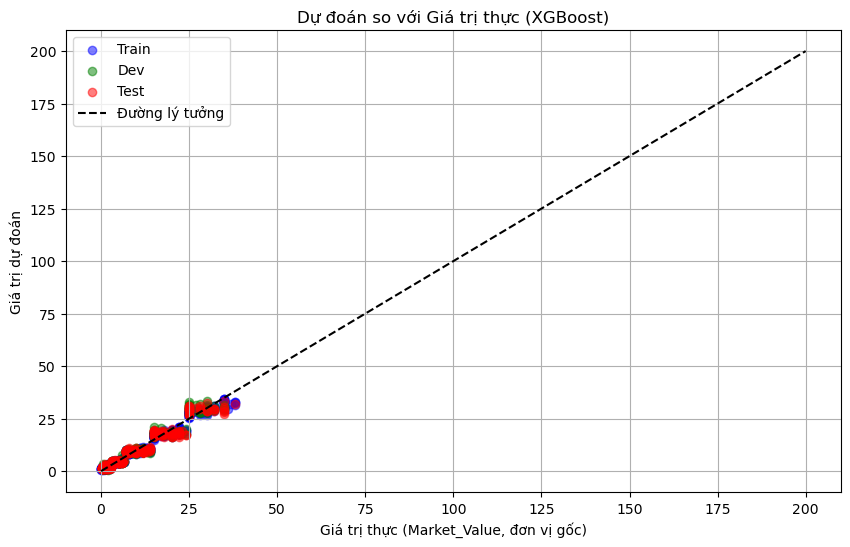

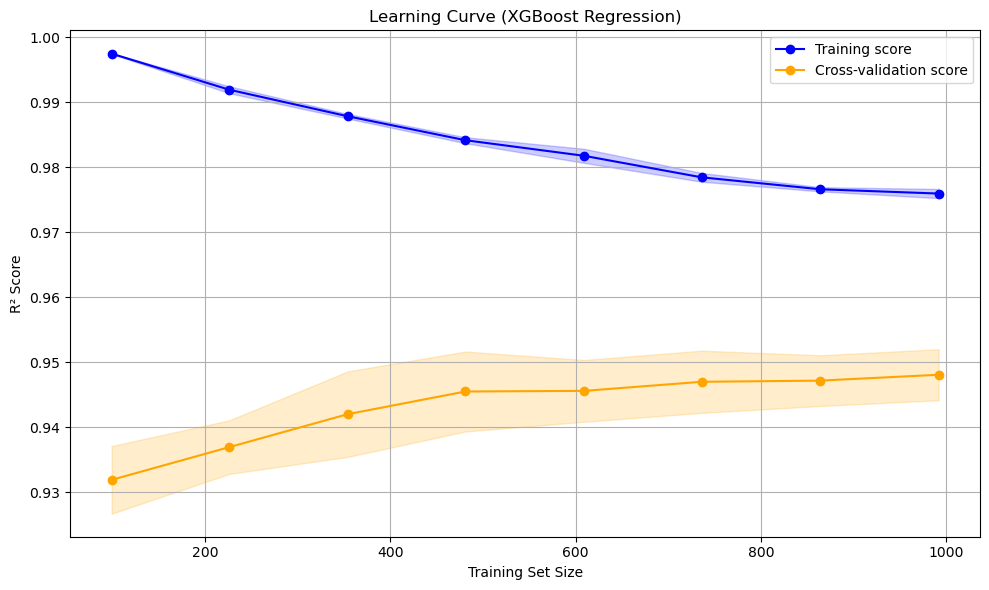

In [230]:
# 4. GridSearchCV cho XGBoost
X_clean_iqr, y_clean_iqr = remove_outliers_iqr(X, y)

# Chia lại tập dữ liệu 
X_train, X_temp, y_train, y_temp = train_test_split(X_clean_iqr, y_clean_iqr, test_size= 0.4, random_state= 32)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size= 0.5, random_state= 32)


xgb_model = xgb.XGBRegressor(random_state=32, objective='reg:squarederror')
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Lấy mô hình tốt nhất
best_model_XG_IQR = grid_search.best_estimator_
print(f"\nSiêu tham số tối ưu: {grid_search.best_params_}")
print(f"Best CV MSE (log scale): {-grid_search.best_score_:.4f}")

# 5. Chọn đặc trưng
selector = SelectFromModel(best_model_XG_IQR, threshold="median")
selector.fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_dev_selected = selector.transform(X_dev)
X_test_selected = selector.transform(X_test)

selected_features = X.columns[selector.get_support()].tolist()
print(f"\nĐặc trưng được chọn: {selected_features}")
print(f"Số đặc trưng ban đầu: {X.shape[1]}")
print(f"Số đặc trưng sau khi chọn: {len(selected_features)}")

# 6. Huấn luyện lại
xg_selected = xgb.XGBRegressor(**grid_search.best_params_, random_state=32)
xg_selected.fit(X_train_selected, y_train)
# 7. Dự đoán


y_train_pred, y_dev_pred, y_test_pred = predict_func(xg_selected, X_train_selected, X_dev_selected, X_test_selected)



# 8. Đánh giá


train_mse_xg_iqr, dev_mse_xg_iqr, test_mse_xg_iqr, train_r2_xg_iqr, dev_r2_xg_iqr, test_r2_xg_iqr, train_mae_xg_iqr, dev_mae_xg_iqr, test_mae_xg_iqr = evaluate(y_train_pred, y_train, y_dev_pred, y_dev, y_test_pred, y_test)


print("\nKết quả đánh giá mô hình XGBoost sau khi chọn đặc trưng (IQR):")
print(f"Train MSE: {train_mse_xg_iqr:.4f}, Train R2: {train_r2_xg_iqr:.4f}, Train MAE : {train_mae_xg_iqr:.4f}")
print(f"Dev MSE: {dev_mse_xg_iqr:.4f}, Dev R2: {dev_r2_xg_iqr:.4f}, Dev MAE : {dev_mae_xg_iqr:.4f}")
print(f"Test MSE: {test_mse_xg_iqr:.4f}, Test R2: {test_r2_xg_iqr:.4f}, Test MAE : {test_mae_xg_iqr:.4f}")

# 9. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.5)
plt.scatter(y_dev, y_dev_pred, color='green', label='Dev', alpha=0.5)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='black', linestyle='--', label='Đường lý tưởng')
plt.xlabel('Giá trị thực (Market_Value, đơn vị gốc)')
plt.ylabel('Giá trị dự đoán')
plt.title('Dự đoán so với Giá trị thực (XGBoost)')
plt.legend()
plt.grid(True)
plt.show()




# Vẽ Learning Curve
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=best_model_XG_IQR,
    X=X_train_selected,
    y=y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

# Tính trung bình và độ lệch chuẩn
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std  = np.std(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)
valid_scores_std  = np.std(valid_scores, axis=1)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')

plt.plot(train_sizes, valid_scores_mean, 'o-', color='orange', label='Cross-validation score')
plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std,
                 valid_scores_mean + valid_scores_std, alpha=0.2, color='orange')

plt.title('Learning Curve (XGBoost Regression)')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### XGBoost with Win 


Siêu tham số tối ưu: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV MSE (log scale): 5.4468

Đặc trưng được chọn: ['Age', 'Months_left', 'Sub_app', 'Mins', 'Goals', 'Assists', 'PS%', 'MotM', 'Rating', 'ThrbAss', 'BlkSh', 'BlkPs', 'TotClr', 'Fouled', 'TotInt', 'UnTch', 'Dispo', 'League_EPL', 'Foot_right', 'Club_Group_Lower Tier', 'Club_Group_Mid-High Tier', 'Club_Group_Mid-Tier', 'Club_Group_Top Tier', 'Club_Group_Upper Tier']
Số đặc trưng ban đầu: 47
Số đặc trưng sau khi chọn: 24

Kết quả đánh giá mô hình XGBoost sau khi chọn đặc trưng (Winsorize):
Train MSE: 2.8802, Train R2: 0.9847, Train MAE : 1.2695
Dev MSE: 3.5468, Dev R2: 0.9754, Dev MAE : 1.3664
Test MSE: 5.7340, Test R2: 0.9709, Test MAE : 1.7394


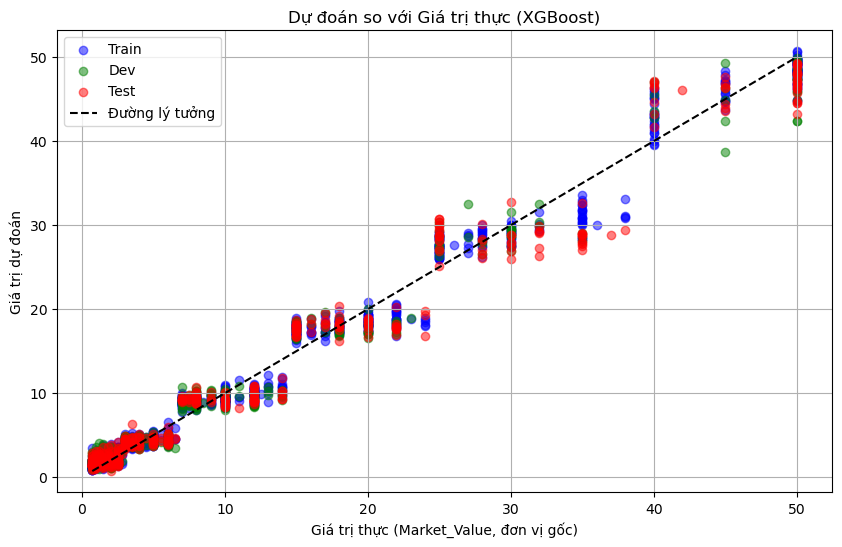

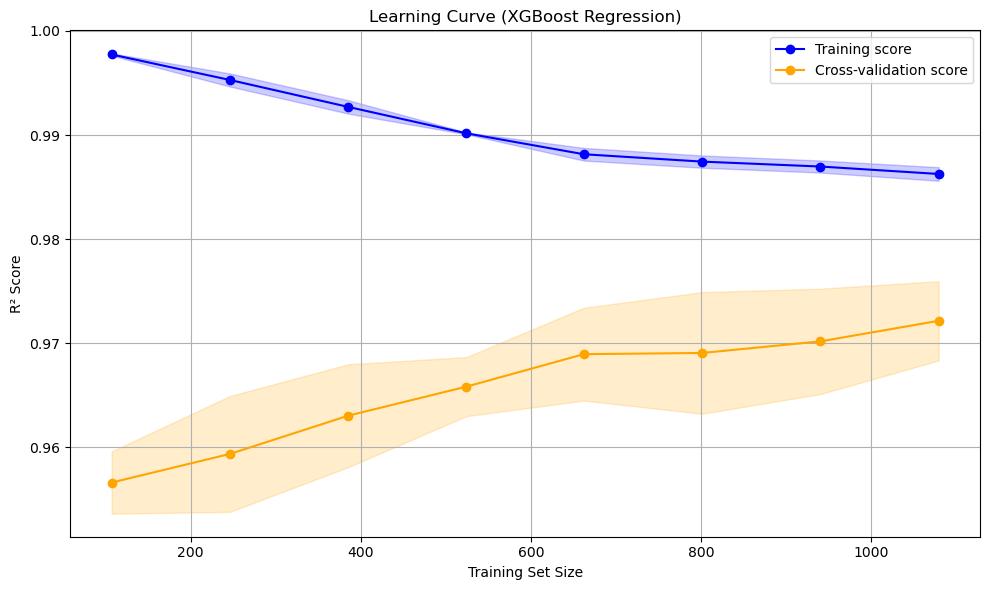

In [231]:
# Winsorize 
X_clean_win = X
y_clean_win = winsorize_data(y)


# Chia lại tập dữ liệu 
X_train, X_temp, y_train, y_temp = train_test_split(X_clean_win, y_clean_win, test_size= 0.4, random_state= 32)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size= 0.5, random_state= 32)


xgb_model = xgb.XGBRegressor(random_state=32, objective='reg:squarederror')
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Lấy mô hình tốt nhất
best_model_XG_WIN = grid_search.best_estimator_
print(f"\nSiêu tham số tối ưu: {grid_search.best_params_}")
print(f"Best CV MSE (log scale): {-grid_search.best_score_:.4f}")

# 5. Chọn đặc trưng
selector = SelectFromModel(best_model_XG_WIN, threshold="median")
selector.fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_dev_selected = selector.transform(X_dev)
X_test_selected = selector.transform(X_test)

selected_features = X.columns[selector.get_support()].tolist()
print(f"\nĐặc trưng được chọn: {selected_features}")
print(f"Số đặc trưng ban đầu: {X.shape[1]}")
print(f"Số đặc trưng sau khi chọn: {len(selected_features)}")

# 6. Huấn luyện lại
best_model_XG_WIN.fit(X_train_selected, y_train)

# 7. Dự đoán

y_train_pred, y_dev_pred, y_test_pred = predict_func(best_model_XG_WIN, X_train_selected, X_dev_selected, X_test_selected)


# Chuyển về đơn vị gốc
y_train_pred_orig = (y_train_pred)
y_dev_pred_orig = (y_dev_pred)
y_test_pred_orig = (y_test_pred)
y_train_orig = (y_train)
y_dev_orig = (y_dev)
y_test_orig = (y_test)

# 8. Đánh giá
train_mse = mean_squared_error(y_train_orig, y_train_pred_orig)
dev_mse = mean_squared_error(y_dev_orig, y_dev_pred_orig)
test_mse = mean_squared_error(y_test_orig, y_test_pred_orig)
train_r2 = r2_score(y_train_orig, y_train_pred_orig)
dev_r2 = r2_score(y_dev_orig, y_dev_pred_orig)
test_r2 = r2_score(y_test_orig, y_test_pred_orig)

train_mae = mean_absolute_error(y_train_orig, y_train_pred_orig)
dev_mae = mean_absolute_error(y_dev_orig, y_dev_pred_orig)
test_mae = mean_absolute_error(y_test_orig, y_test_pred_orig)

print("\nKết quả đánh giá mô hình XGBoost sau khi chọn đặc trưng (Winsorize):")
print(f"Train MSE: {train_mse:.4f}, Train R2: {train_r2:.4f}, Train MAE : {train_mae:.4f}")
print(f"Dev MSE: {dev_mse:.4f}, Dev R2: {dev_r2:.4f}, Dev MAE : {dev_mae:.4f}")
print(f"Test MSE: {test_mse:.4f}, Test R2: {test_r2:.4f}, Test MAE : {test_mae:.4f}")

# 9. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.scatter(y_train_orig, y_train_pred_orig, color='blue', label='Train', alpha=0.5)
plt.scatter(y_dev_orig, y_dev_pred_orig, color='green', label='Dev', alpha=0.5)
plt.scatter(y_test_orig, y_test_pred_orig, color='red', label='Test', alpha=0.5)
plt.plot([y_train_orig.min(), y_train_orig.max()], [y_train_orig.min(), y_train_orig.max()], color='black', linestyle='--', label='Đường lý tưởng')
plt.xlabel('Giá trị thực (Market_Value, đơn vị gốc)')
plt.ylabel('Giá trị dự đoán')
plt.title('Dự đoán so với Giá trị thực (XGBoost)')
plt.legend()
plt.grid(True)
plt.show()


from sklearn.model_selection import learning_curve

# Vẽ Learning Curve
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=best_model_XG_WIN,
    X=X_train_selected,
    y=y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

# Tính trung bình và độ lệch chuẩn
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std  = np.std(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)
valid_scores_std  = np.std(valid_scores, axis=1)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')

plt.plot(train_sizes, valid_scores_mean, 'o-', color='orange', label='Cross-validation score')
plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std,
                 valid_scores_mean + valid_scores_std, alpha=0.2, color='orange')

plt.title('Learning Curve (XGBoost Regression)')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## LightGBM

In [232]:
data.columns
'''
data = data.drop(columns= ['Player', 'ThrInAss'])
data_encoded = data.copy()
drop_col = ['CLB', 'National', 'Main_position', 'Yel', 'Red', 'Continent', 'Market_Value_log']
data_encoded = data_encoded.drop(columns= drop_col)"
'''

'\ndata = data.drop(columns= [\'Player\', \'ThrInAss\'])\ndata_encoded = data.copy()\ndrop_col = [\'CLB\', \'National\', \'Main_position\', \'Yel\', \'Red\', \'Continent\', \'Market_Value_log\']\ndata_encoded = data_encoded.drop(columns= drop_col)"\n'

In [233]:
drop_col = ['Position_Group', 'Continent', 'Continent_Grouped', 'Club_Group', 'Market_Value_log']
data_lgbm = data.drop(columns= drop_col)

data_lgbm.columns

Index(['CLB', 'League', 'Age', 'National', 'Height', 'Main_position', 'Foot',
       'Market_Value', 'Months_left', 'Start_app', 'Sub_app', 'Mins', 'Goals',
       'Assists', 'Yel', 'Red', 'SpG', 'PS%', 'AerialsWon', 'MotM', 'Rating',
       'TotAD', 'WonAD', 'LostAD', 'CrAss', 'CorAss', 'ThrbAss', 'FreAss',
       'OthAss', 'TotAss', 'BlkSh', 'BlkCr', 'BlkPs', 'YelC', 'RedC', 'TotClr',
       'UnDrib', 'SucDrib', 'TotDrib', 'Fouled', 'Fouls', 'TotGs', 'SYBGs',
       'PAGs', 'OOBGs', 'TotInt', 'TotKPs', 'LKPs', 'SKPs', 'COF', 'TotPs',
       'AccLB', 'InAccLB', 'AccSP', 'InAccSP', 'UnTch', 'Dispo', 'TotSav',
       'SYBSav', 'PASav', 'OOBSav', 'TotSh', 'OOBSh', 'SYBSh', 'PASh',
       'TotTkl', 'DribPast', 'TotAttTkl', 'Card'],
      dtype='object')

In [234]:
data_lgbm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2249 entries, 0 to 2248
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CLB            2249 non-null   object 
 1   League         2249 non-null   object 
 2   Age            2249 non-null   float64
 3   National       2249 non-null   object 
 4   Height         2249 non-null   float64
 5   Main_position  2249 non-null   object 
 6   Foot           2249 non-null   object 
 7   Market_Value   2249 non-null   float64
 8   Months_left    2249 non-null   float64
 9   Start_app      2249 non-null   float64
 10  Sub_app        2249 non-null   float64
 11  Mins           2249 non-null   float64
 12  Goals          2249 non-null   float64
 13  Assists        2249 non-null   float64
 14  Yel            2249 non-null   float64
 15  Red            2249 non-null   float64
 16  SpG            2249 non-null   float64
 17  PS%            2249 non-null   float64
 18  AerialsW

In [235]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

categorical_col = ['CLB', 'League', 'National', 'Main_position', 'Foot', 'Card']

for col in categorical_col:
    data_lgbm[col] = data_lgbm[col].astype('category')

X = data_lgbm.drop(columns= 'Market_Value')
y = data_lgbm['Market_Value']




### LightGBM Original 

In [236]:


X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=32)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=32)


model = LGBMRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_dev, y_dev)],
    eval_metric='rmse',
    #early_stopping_rounds = 20,
    callbacks=[
        early_stopping(stopping_rounds=20),
        log_evaluation(period=0)  # 0 nghĩa là không hiện log
    ]
)

'''# Chuyển về đơn vị gốc
y_train_pred_orig = (y_train_pred)
y_dev_pred_orig = (y_dev_pred)
y_test_pred_orig = (y_test_pred)
y_train_orig = (y_train)
y_dev_orig = (y_dev)
y_test_orig = (y_test)

# 8. Đánh giá
train_mse = mean_squared_error(y_train_orig, y_train_pred_orig)
dev_mse = mean_squared_error(y_dev_orig, y_dev_pred_orig)
test_mse = mean_squared_error(y_test_orig, y_test_pred_orig)
train_r2 = r2_score(y_train_orig, y_train_pred_orig)
dev_r2 = r2_score(y_dev_orig, y_dev_pred_orig)
test_r2 = r2_score(y_test_orig, y_test_pred_orig)

train_mae = mean_absolute_error(y_train_orig, y_train_pred_orig)
dev_mae = mean_absolute_error(y_dev_orig, y_dev_pred_orig)
test_mae = mean_absolute_error(y_test_orig, y_test_pred_orig)

print("\nKết quả đánh giá mô hình XGBoost đã tunning:")
print(f"Train MSE: {train_mse:.4f}, Train R2: {train_r2:.4f}, Train MAE : {train_mae:.4f}")
print(f"Dev MSE: {dev_mse:.4f}, Dev R2: {dev_r2:.4f}, Dev MAE : {dev_mae:.4f}")
print(f"Test MSE: {test_mse:.4f}, Test R2: {test_r2:.4f}, Test MAE : {test_mae:.4f}")'''

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_dev_pred = model.predict(X_dev)

# Đánh giá 
train_mse = mean_squared_error(y_train, y_train_pred)
dev_mse = mean_squared_error(y_dev, y_dev_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
dev_r2 = r2_score(y_dev, y_dev_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
dev_mae = mean_absolute_error(y_dev, y_dev_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)


print("\nKết quả đánh giá mô hình LightGBM Original:")
print(f"Train MSE: {train_mse:.4f}, Train R2: {train_r2:.4f}, Train MAE : {train_mae:.4f}")
print(f"Dev MSE: {dev_mse:.4f}, Dev R2: {dev_r2:.4f}, Dev MAE : {dev_mae:.4f}")
print(f"Test MSE: {test_mse:.4f}, Test R2: {test_r2:.4f}, Test MAE : {test_mae:.4f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001822 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2631
[LightGBM] [Info] Number of data points in the train set: 1349, number of used features: 67
[LightGBM] [Info] Start training from score 13.796405
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[19]	valid_0's rmse: 9.20388	valid_0's l2: 84.7114

Kết quả đánh giá mô hình LightGBM Original:
Train MSE: 65.9333, Train R2: 0.8304, Train MAE : 4.3528
Dev MSE: 84.7114, Dev R2: 0.5986, Dev MAE : 5.0188
Test MSE: 133.2903, Test R2: 0.6698, Test MAE : 5.9414


### LightGBM with Winsorize 

In [237]:
# Winsorize 
X_clean_win = X
y_clean_win = winsorize_data(y)

X_train, X_temp, y_train, y_temp = train_test_split(X_clean_win, y_clean_win, test_size=0.4, random_state=32)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=32)


model = LGBMRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_dev, y_dev)],
    eval_metric='rmse',
    #early_stopping_rounds = 20,
    callbacks=[
        early_stopping(stopping_rounds=20),
        log_evaluation(period=0)  # 0 nghĩa là không hiện log
    ]
)


y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_dev_pred = model.predict(X_dev)

# Đánh giá 
train_mse = mean_squared_error(y_train, y_train_pred)
dev_mse = mean_squared_error(y_dev, y_dev_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
dev_r2 = r2_score(y_dev, y_dev_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
dev_mae = mean_absolute_error(y_dev, y_dev_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)


print("\nKết quả đánh giá mô hình LightGBM with Winsorize tunning:")
print(f"Train MSE: {train_mse:.4f}, Train R2: {train_r2:.4f}, Train MAE : {train_mae:.4f}")
print(f"Dev MSE: {dev_mse:.4f}, Dev R2: {dev_r2:.4f}, Dev MAE : {dev_mae:.4f}")
print(f"Test MSE: {test_mse:.4f}, Test R2: {test_r2:.4f}, Test MAE : {test_mae:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001257 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2631
[LightGBM] [Info] Number of data points in the train set: 1349, number of used features: 67
[LightGBM] [Info] Start training from score 12.393113
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[96]	valid_0's rmse: 6.43199	valid_0's l2: 41.3705

Kết quả đánh giá mô hình LightGBM with Winsorize tunning:
Train MSE: 1.9487, Train R2: 0.9897, Train MAE : 1.0019
Dev MSE: 41.3705, Dev R2: 0.7125, Dev MAE : 3.9740
Test MSE: 43.8066, Test R2: 0.7779, Test MAE : 4.2361


### LightGBM with IQR 


In [239]:
X_clean_iqr, y_clean_iqr = remove_outliers_iqr(X, y)

X_train, X_temp, y_train, y_temp = train_test_split(X_clean_iqr, y_clean_iqr, test_size=0.4, random_state=32)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=32)


model = LGBMRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_dev, y_dev)],
    eval_metric='rmse',
    #early_stopping_rounds = 20,
    callbacks=[
        early_stopping(stopping_rounds=20),
        log_evaluation(period=0)  # 0 nghĩa là không hiện log
    ]
)


y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_dev_pred = model.predict(X_dev)

# Đánh giá 
train_mse = mean_squared_error(y_train, y_train_pred)
dev_mse = mean_squared_error(y_dev, y_dev_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
dev_r2 = r2_score(y_dev, y_dev_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
dev_mae = mean_absolute_error(y_dev, y_dev_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)


print("\nKết quả đánh giá mô hình LightGBM with IQR tunning:")
print(f"Train MSE: {train_mse:.4f}, Train R2: {train_r2:.4f}, Train MAE : {train_mae:.4f}")
print(f"Dev MSE: {dev_mse:.4f}, Dev R2: {dev_r2:.4f}, Dev MAE : {dev_mae:.4f}")
print(f"Test MSE: {test_mse:.4f}, Test R2: {test_r2:.4f}, Test MAE : {test_mae:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001310 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2566
[LightGBM] [Info] Number of data points in the train set: 1240, number of used features: 67
[LightGBM] [Info] Start training from score 9.293105
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[70]	valid_0's rmse: 5.04333	valid_0's l2: 25.4351

Kết quả đánh giá mô hình LightGBM with IQR tunning:
Train MSE: 2.9255, Train R2: 0.9652, Train MAE : 1.1976
Dev MSE: 25.4351, Dev R2: 0.6440, Dev MAE : 3.6015
Test MSE: 26.6739, Test R2: 0.6108, Test MAE : 3.6333
